In [102]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple, List
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
import argparse
import gzip

import pandas as pd
from matplotlib import pyplot as plt
import json
import os
from datetime import datetime, timedelta
import matplotlib.ticker as ticker
from collections import defaultdict
from matplotlib import cm
import math
import numpy as np
import pgzip
import pickle
import csv
import random
import matplotlib

In [12]:
class Capability:
    def __init__(self, line, parent):
        #print(line)
        _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms   = line.split()
        self.boundsOffset = int(boundsOffset, 16)
        self.boundsLength = int(boundsLength, 16)
        self.boundsVirtBase = int(boundsVirtualBase, 16)
        self.capPerms = int(capPerms, 16)
        self.parent = parent
        parent.child = self

    def capKey(self):
        return (self.boundsVirtBase, self.boundsLength)
    
    def __eq__(self, other):
        return self.boundsOffset == other.boundsOffset and self.boundsLength == other.boundsLength and self.boundsVirtBase == other.boundsVirtBase and self.capPerms == other.capPerms

    def __hash__(self):
        return hash((self.boundsOffset, self.boundsLength, self.boundsVirtBase, self.capPerms))
    
    def __repr__(self):
        return f"Cap virtBase {self.boundsVirtBase} length {self.boundsLength} offset {self.boundsOffset}"

class ReportAccessLog:
    def __init__(self, line, index):
        #44200 Prefetcher logReportAccess level 1 addr 00000000c0007648 pcHash c0000260 hitMiss 1 boundsOffset 0000000000000008 boundsLength 0000000000002f30 boundsVirtBase 00000000c0007640 capPerms 0000000000001111000111111010111

        #print(line.split())
        clock_time,_, _, _, addr, _, pcHash, _, isMiss, _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms, _, op   = line.split()
        self.clock_time = int(clock_time)/10
        self.addr = int(addr, 16)
        self.pcHash = int(pcHash, 16)
        self.isMiss = int(isMiss)
        self.op = op
        self.cap = Capability("boundsOffset"+line.partition("op")[0].partition("boundsOffset")[2], self)

        self.index = index
    
class ReportDataArrivalCap:
    def __init__(self, line, parent):
        pre, _, cap = line.partition("boundsOffset")
        _, _, _, _, index, _, tag, _, addr = pre.split()
        self.index = int(index)
        self.tag = bool(int(tag))
        self.addr = int(addr, 16)
        self.cap = Capability("boundsOffset"+cap, parent)
        self.parent = parent
        parent.child = self

class ReportDataArrival:
    def __init__(self, line, index):
        clock_time,_, _, _, requestAddr, _, pcHash, _, wasMiss, _, wasPrefetch, _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms, _, op  = line.split()
        self.clock_time = int(clock_time)/10
        self.requestAddr = int(requestAddr, 16)
        self.pcHash = int(pcHash, 16)
        self.wasMiss = int(wasMiss)
        self.wasPrefetch = int(wasPrefetch)

        #print(line)
        self.requestCap = Capability("boundsOffset"+line.partition("op")[0].partition("boundsOffset")[2], self)
        self.capabilites: List[ReportDataArrivalCap] = []
        self.values:List[ReportDataArrivalCap] = []

        self.sel_capability = None

        self.index = index

    def add_capability(self, line, parent_data_arrivals):
        capability = ReportDataArrivalCap(line, self)
        if capability.tag:
            self.capabilites.append(capability)
            parent_data_arrivals[capability.cap.capKey()] = capability.cap 

        self.values.append(capability)
        return capability

    def add_sel_capability(self, line):
        capability = ReportDataArrivalCap(line, self)
        if capability.tag:
            self.sel_capability = capability 

        return capability

class NextPrefetchAddr:
    def __init__(self, line):
        clock_time,_, _, addr = line.split()
        self.clock_time = int(clock_time)/10
        self.addr = int(addr, 16)

class TlbResponse:
    def __init__(self, line):
        self.clock_time = int(line.split()[0])/10
        self.paddr = int(line.split()[8].strip(",").strip("'h"), 16)

@dataclass
class PredictionResponseMatch:
    clock_time: str
    predIdxTag: int
    parentOffset: int
    childOffset: int
    confidence: int
    virtBase: int

@dataclass
class BackwardsHit:
    tag: int
    parentVirtBase: int
    parentOffset: int
    childOffset: int
    clock_time: str

@dataclass
class BackwardsAddition:
    parentVirtBase:int
    parentOffset: int
    idxTag: int
    clock_time: str

@dataclass
class TimelinessRdResp:
    valid: bool
    idx: int
    tag: int
    pcHash: int
    clock_time: str
    replacementWay: int

@dataclass
class PredictionReplacement:
    clock_time: str
    idx: int
    tag: int
    newParentOffset: int
    newChildOffset: int
    oldParentOffset: int
    oldChildOffset: int

@dataclass 
class TimelinessReplacement:
    clock_time: str
    repResp: int
    idx: int
    tag: int
    pcHash: int

@dataclass
class PredictionDecrease:
    clock_time: str
    idx: int
    tag: int
    oldConfidence: int
    oldParentOffset: int
    oldChildOffset: int

@dataclass
class PredictionMatchUpdate:
    clock_time: str
    idx: int
    tag: int
    oldConfidence: int

@dataclass
class L1DemandHit:
    clock_time: str


@dataclass
class CrqHit:
    clock_time: str
    wasMiss: int
    wasPrefetch: int
    addr: int

def parse_log(input_file, ignore_first_n_instr, ignore_last_n_instr) -> Tuple[List[ReportAccessLog], List[ReportDataArrival], List[ReportAccessLog]]:
    total_order_events = []
    recent_misses = set()
    parent_access = {} #(cap_virtual_base, cap_size, most recent ReportAccessLog)
    parent_data_arrivals = {} #(cap_virtual_base, cap_size, most recent ReportAccessLog)
    accesses = []
    data_arrivals = []
    access_misses = []

    demand_misses = 0

    access_index = 0
    data_arrival_index = 0
    
    instruction_count = 0
    instruction_start_time = 0
    instruction_end_time = 0
    last_instruction_clock_time = 0

    prefetch_hit_count = 0
    prefetch_total_count = 0
    prefetch_total_miss_count = 0
    prefetch_late_hit_count = 0

    total_access = 0
    demand_access = 0

    open_fn = open
    open_kwrgs = {}
    if not input_file.is_file():
        open_fn = pgzip.open
        input_file = input_file.with_suffix(".gz")
        open_kwrgs = {"thread": 30}

    with open_fn(input_file, "rt", **open_kwrgs) as fp:
        while True:
            line = fp.readline()
            if not line:
                break

            if "logReportAccess" in line:
                reportAccess = ReportAccessLog(line, access_index)
                total_order_events.append(reportAccess)

                access_index += 1

            #     if reportAccess.isMiss:
            #         recent_misses.add(reportAccess.addr)
            #         access_misses.append(reportAccess)
            #     elif reportAccess.addr in recent_misses:
            #         #Skip first hit access after miss
            #         recent_misses.remove(reportAccess.addr)
            #         continue

            #     accesses.append(reportAccess)
            #     parent_access[reportAccess.cap.capKey()] = reportAccess.cap

            #     if reportAccess.cap.capKey() in parent_data_arrivals:
            #         parent = parent_data_arrivals[reportAccess.cap.capKey()]
            #         reportAccess.parent = parent
            #         parent.child = reportAccess
            #         #parent.child = reportAccess
            #         #print("found parent")

            #     # if reportAccess.cap.boundsLength == 40000:
            #     #         print("40000 arrival")
            #     #         print(reportAccess.cap.capKey())
            #     #print(reportAccess.cap.boundsLength)
            
            elif "logReportDataArrival" in line:
                data_arrival = ReportDataArrival(line, data_arrival_index)
                total_order_events.append(data_arrival)
                data_arrival_index += 1 

                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)

                data_arrival.add_sel_capability(fp.readline())

                data_arrivals.append(data_arrival)

                # if data_arrival.requestCap.capKey() in parent_access:
                #     parent = parent_access[data_arrival.requestCap.capKey()]
                #     data_arrival.parent = parent
                #     parent.child = data_arrival

                if ignore_first_n_instr <= instruction_count and instruction_count <= ignore_last_n_instr:
                    total_access += 1

                    if data_arrival.wasMiss and not data_arrival.wasPrefetch:
                        demand_misses += 1

                    if not data_arrival.wasPrefetch:
                        demand_access += 1

                    if data_arrival.wasPrefetch:
                        prefetch_total_count += 1

                    if data_arrival.wasPrefetch and data_arrival.wasMiss:
                        prefetch_total_miss_count += 1

            elif "L1 demand hit" in line:
                if ignore_first_n_instr <= instruction_count and instruction_count <= ignore_last_n_instr: 
                    clock_time, _, _, _, _, _, _, _ = line.split()
                    l1DemandHit = L1DemandHit(clock_time)
                    total_order_events.append(l1DemandHit)

                    prefetch_hit_count += 1
                    
            elif "getNextPrefetchAddr" in line:
                if ignore_first_n_instr <= instruction_count and instruction_count <= ignore_last_n_instr: 
                    getNextPrefetchAddr = NextPrefetchAddr(line)
                    total_order_events.append(getNextPrefetchAddr)

            elif "crqhit" in line:
                if ignore_first_n_instr <= instruction_count and instruction_count <= ignore_last_n_instr: 
                    clock_time, _, _, _, wasMiss, _, wasPrefetch, _, addr, _, _ = line.split()
                    wasMiss = int(wasMiss)
                    wasPrefetch = int(wasPrefetch)
                    addr = int(addr, 16)
                    crqHit = CrqHit(clock_time, wasMiss, wasPrefetch, addr)
                    total_order_events.append(crqHit)

            # elif "got TLB response" in line:
            #     tlbResponse = TlbResponse(line)
            #     total_order_events.append(tlbResponse)

            # elif "processPredictionResponse tag match and valid offset" in line:
            #     clock_time, _, _, _, _, _, _, _, _, predIdxTag, _, parentOffset, _, childOffset, _, confidence, _, virtBase = line.split()
            #     predIdxTag = int(predIdxTag, 16)
            #     parentOffset = int(parentOffset, 16)
            #     childOffset = int(childOffset, 16)
            #     confidence = int(confidence, 16)
            #     virtBase = int(virtBase, 16)

            #     predResponse = PredictionResponseMatch(clock_time, predIdxTag, parentOffset, childOffset, confidence, virtBase)
            #     total_order_events.append(predResponse)

            # elif "backwards table hit" in line:
            #     clock_time, _, _, _, _, _, tag, _, parentVirtBase, _, parentOffset, _, childOffset = line.split()
            #     tag = int(tag, 16)
            #     parentVirtBase = int(parentVirtBase, 16)
            #     parentOffset = int(parentOffset, 16)
            #     childOffset = int(childOffset, 16)
            #     backwardsHit = BackwardsHit(tag, parentVirtBase, parentOffset, childOffset, clock_time)
            #     total_order_events.append(backwardsHit)

            # elif "added to backwards table" in line:
            #     clock_time, _, _, _, _, _, _, _, parentVirtBase, _, parentOffset, _, idx, _, childTag = line.split()
            #     parentVirtBase = int(parentVirtBase, 16)
            #     parentOffset = int(parentOffset, 16)

            #     idxTag = int(childTag + idx, 16)
            #     backwardsAddition = BackwardsAddition(parentVirtBase, parentOffset, idxTag, clock_time)

            #     total_order_events.append(backwardsAddition) 

            # elif "timeliness table rdResp" in line:
            #     clock_time, _, _, _, _, _, valid, _, idx, _, tag, _, pcHash, _, repWay, _, _ = line.partition("fshow")[0].split()
            #     valid = int(valid)
            #     idx = int(idx, 16)
            #     tag = int(tag, 16)
            #     pcHash = int(pcHash, 16)
            #     timelinessRdResp = TimelinessRdResp(valid, idx, tag, pcHash, clock_time, repWay)
            #     total_order_events.append(timelinessRdResp)
            
            # elif "processPredictionReplacementRd replacement" in line:
            #     clock_time, _, _, _, _, idx, _, tag, _, newParentOffset, _, newChildOffset, _, oldParentOffset, _, oldChildOffset = line.split()
            #     idx = int(idx, 16)
            #     tag = int(tag, 16)
            #     newParentOffset = int(newParentOffset, 16)
            #     newChildOffset = int(newChildOffset, 16)
            #     oldParentOffset = int(oldParentOffset, 16)
            #     oldChildOffset = int(oldChildOffset, 16)
            #     predictionReplacement = PredictionReplacement(clock_time, idx, tag, newParentOffset, newChildOffset, oldParentOffset, oldChildOffset)
            #     total_order_events.append(predictionReplacement)

            # elif "processPredictionReplacementRd decrease" in line:
            #     clock_time, _, _, _, _, _, oldConfidence, _, idx, _, tag, _, oldParentOffset, _, oldChildOffset = line.split()
            #     idx = int(idx, 16)
            #     tag = int(tag, 16)
            #     oldConfidence = int(oldConfidence, 16)
            #     oldParentOffset = int(oldParentOffset, 16)
            #     oldChildOffset = int(oldChildOffset, 16)

            #     predictionDecrease = PredictionDecrease(clock_time, idx, tag, oldConfidence, oldParentOffset, oldChildOffset)
            #     total_order_events.append(predictionDecrease)

            # elif "table miss" in line:
            #     for i in range(len(total_order_events)-1, 0, -1):
            #         if isinstance(total_order_events[i], TimelinessRdResp):
            #             total_order_events.pop(i)
            #             break

            # elif "timeliness replacement" in line:
            #     clock_time, _, _, _, _, repRepl, _, _, _, idx, _, tag, _, pcHash = line.split()
            #     repRepl = int(repRepl)
            #     idx = int(idx, 16)
            #     tag = int(tag, 16)
            #     pcHash = int(pcHash, 16)
            #     timelinessRepl = TimelinessReplacement(clock_time, repRepl, idx, tag, pcHash)
            #     total_order_events.append(timelinessRepl)

            # elif "processPredictionReplacementRd match" in line:
            #     clock_time, _, _, _, _, _, oldConfidence, _, idx, _, tag = line.split()
            #     oldConfidence = int(oldConfidence, 16)
            #     idx = int(idx, 16)
            #     tag = int(tag, 16)
            #     predictionMatchUpdate = PredictionMatchUpdate(clock_time, idx, tag, oldConfidence)
            #     total_order_events.append(predictionMatchUpdate)

            # elif "L1 demand hit on prefetched cache line" in line:
            #     if ignore_first_n_instr <= instruction_count and instruction_count <= ignore_last_n_instr: 
            #         prefetch_hit_count += 1
        
            if "RVFI Order" in line:
                instruction_count += 1
                clock_time = int(line.split()[0].strip(":"))

                last_instruction_clock_time = clock_time

                if instruction_count == ignore_first_n_instr:
                    instruction_start_time = clock_time
                if instruction_count == ignore_last_n_instr:
                    instruction_end_time = clock_time
                    break
                

    in_flight_prefetches = {}
    finished_prefetches = {}

    if instruction_count < ignore_last_n_instr:
        instruction_end_time = last_instruction_clock_time

    print(f"Demand access {demand_access} demand misses {demand_misses}")
    print(f"Prefetch access {prefetch_total_count} prefetch causing misses {prefetch_total_miss_count}")
    print(f"IPC {(instruction_count - ignore_first_n_instr)/ (instruction_end_time - instruction_start_time)}")
    print(f"Instruction count {instruction_count} num of cycles {instruction_end_time - instruction_start_time}")
    ipc = {(ignore_last_n_instr - ignore_first_n_instr)/ (instruction_end_time - instruction_start_time)}
    print(f"Misses not prefetcher {demand_misses}")
    # print(f"Timeliness complete {timeliness_complete} timeliness {timeliness_late}")
    print()
    return {"accesses": accesses, "data_arrivals": data_arrivals, "access_missess": access_misses, "total_order_events": total_order_events}

# Benchmark loads

In [13]:
#benchmark_results = {}

In [24]:
#def process_benchmark(name):
#    input_file = Path("/local/scratch-3/tm746/simulations_v2")/"without-prefetcher"/"baselines"/name/"sim_0.0"/"sim_stdout"
#    benchmark_results[name] = parse_log(input_file, 0, 1000)

In [25]:
#benchmark_names = ["bh", "bisort", "em3d", "health", "perimeter", "power", "treeadd", "tsp"]

In [26]:
#for benchmark in benchmark_names:
#    print(benchmark)
    #process_benchmark(benchmark)

bh
Demand access 245 demand misses 35
Prefetch access 0 prefetch causing misses 0
IPC 0.14566642388929352
Instruction count 1000 num of cycles 6865
Misses not prefetcher 35

bisort
Demand access 239 demand misses 33
Prefetch access 0 prefetch causing misses 0
IPC 0.14874312063067083
Instruction count 1000 num of cycles 6723
Misses not prefetcher 33

em3d
Demand access 246 demand misses 34
Prefetch access 0 prefetch causing misses 0
IPC 0.13966480446927373
Instruction count 1000 num of cycles 7160
Misses not prefetcher 34

health
Demand access 246 demand misses 34
Prefetch access 0 prefetch causing misses 0
IPC 0.1488316713796696
Instruction count 1000 num of cycles 6719
Misses not prefetcher 34

perimeter
Demand access 243 demand misses 33
Prefetch access 0 prefetch causing misses 0
IPC 0.1490757304710793
Instruction count 1000 num of cycles 6708
Misses not prefetcher 33

power
Demand access 256 demand misses 35
Prefetch access 0 prefetch causing misses 0
IPC 0.14423770373575653
Instru

In [308]:
#with open(r"pre-processed-baselines-mibench.pickle", "rb") as input_file:
#    bechmark_result_mibench = pickle.load(input_file)
#with open(r"pre-processed-baselines-donemaybe.pickle", "rb") as input_file:
#   benchmark_results = pickle.load(input_file)

In [316]:
benchmark_name_mibench = bechmark_result_mibench.keys()

# Processing functions

In [149]:
def dict_of_set_to_count(d):
    return {k:[len(v)] for k, v in d.items()}

In [214]:
#https://stackoverflow.com/questions/13575090/construct-pandas-dataframe-from-items-in-nested-dictionary
def flatten_dict(nested_dict):
    res = {}
    if isinstance(nested_dict, dict):
        for k in nested_dict:
            flattened_dict = flatten_dict(nested_dict[k])
            for key, val in flattened_dict.items():
                key = list(key)
                key.insert(0, k)
                res[tuple(key)] = val
    else:
        res[()] = nested_dict
    return res

def nested_dict_to_df(values_dict):
    flat_dict = flatten_dict(values_dict)
    df = pd.DataFrame.from_dict(flat_dict, orient="index")
    df.index = pd.MultiIndex.from_tuples(df.index)
    df = df.unstack(level=-1)
    df.columns = df.columns.map("{0[1]}".format)
    return df

# Plotting functions

In [768]:
def plot_bar(df, title, ylabel, filename, log=False, stacked=False, format_sci=True):
    fig = plt.figure(figsize=(10,4), dpi=600)
    ax = fig.gca()
    ax = df.plot.bar(rot=0, figsize=(10,4), ylabel=ylabel, ax=ax, log=log, stacked=stacked)
    if format_sci:
        ax.get_yaxis().set_major_formatter(
            matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    fig.savefig("MotivationGraphs/"+filename+".pdf", bbox_inches='tight')
    return ax

# Prediction whether a value is a pointer
Want to see over predictions and under-predictions

Bar graph with all benchmarks. True pointer count on left. False pointer on right as stacked with True postive estimate, False negatives, True positives

In [343]:
def plot_clustered_stacked(dfall, labels=None, title="multiple stacked bar plot",  H="/", **kwargs):
    """Given a list of dataframes, with identical columns and index, create a clustered stacked bar plot. 
labels is a list of the names of the dataframe, used for the legend
title is a string for the title of the plot
H is the hatch used for identification of the different dataframe"""

    n_df = len(dfall)
    n_col = len(dfall[0].columns) 
    n_ind = len(dfall[0].index)
    axe = plt.subplot(111)
    color = [['tab:blue', 'tab:orange'], ['tab:red', 'tab:purple']]

    for i, df in enumerate(dfall) : # for each data frame
        axe = df.plot(kind="bar",
                      linewidth=0,
                      stacked=True,
                      ax=axe,
                      legend=False,
                      grid=False,
                      color=color[i]
                      **kwargs)  # make bar plots

    h,l = axe.get_legend_handles_labels() # get the handles we want to modify
    for i in range(0, n_df * n_col, n_col): # len(h) = n_col * n_df
        for j, pa in enumerate(h[i:i+n_col]):
            for rect in pa.patches: # for each index
                rect.set_x(rect.get_x() + 1 / float(n_df + 1) * i / float(n_col))
                #rect.set_hatch(H * int(i / n_col)) #edited part     
                rect.set_width(1 / float(n_df + 1))

    axe.set_xticks((np.arange(0, 2 * n_ind, 2) + 1 / float(n_df + 1)) / 2.)
    axe.set_xticklabels(df.index, rotation = 0)
    axe.set_title(title)

    # Add invisible data to add another legend
    n=[]        
    for i in range(n_df):
        n.append(axe.bar(0, 0, color="gray", hatch=H * i))

    l1 = axe.legend(h[:n_col], l[:n_col], loc=[1.01, 0.5])
    if labels is not None:
        l2 = plt.legend(n, labels, loc=[1.01, 0.1]) 
    axe.add_artist(l1)
    return axe

In [309]:
def pointer_estimation(name, benchmark_var):
    true_pointer_count = 0
    estimate_pointer_count = 0
    over_count = 0
    under_count = 0
    compare_bits = 64-32
    filter_bits = 4
    correct_estimate_count = 0
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        arrival_addr = data_arrival.requestCap.boundsVirtBase + data_arrival.requestCap.boundsOffset
        for cap in data_arrival.values:
            if cap.tag:
                true_pointer_count += 1
            value = cap.cap.boundsVirtBase + cap.cap.boundsOffset
            compare_bits_addr = arrival_addr >> compare_bits
            compare_bits_candidate = value >> compare_bits
    
            filter_bits_candidate = value >> (compare_bits-filter_bits)
            # print(filter_bits_candidate)
    
            predict_pointer = False
            
            if compare_bits_addr == compare_bits_candidate and (compare_bits_candidate & 0b11 == 0):
                if compare_bits_candidate == 0 and filter_bits_candidate != 0:
                    predict_pointer = True
                    
                elif compare_bits_candidate == 2**(compare_bits+1)-1 and filter_bits_candidate != 2**(filter_bits+1)-1:
                    predict_pointer = True
                    print("here")
    
            if predict_pointer:
                estimate_pointer_count += 1
                if not cap.tag:
                    over_count += 1
                else:
                    correct_estimate_count += 1
            else:
                if cap.tag:
                    under_count += 1
            
    return true_pointer_count, correct_estimate_count, over_count, under_count
    

In [336]:
pointer_estimate_results_cheri = {}
pointer_estimate_results_estimate = {}
for benchmark in benchmark_names:
    true_pointer_count, correct_estimate_count, over_count, under_count = pointer_estimation(benchmark, benchmark_results)
    pointer_estimate_results_cheri[benchmark] = [true_pointer_count, 0]
    pointer_estimate_results_estimate[benchmark] = [correct_estimate_count, over_count]


In [338]:
df = pd.DataFrame.from_dict(pointer_estimate_results_cheri, orient='index',
                       columns=['True positive', 'False positive'])
df

,True positive,False positive
bh,6702323,0
bisort,4904188,0
em3d,1007611,0
health,6013134,0
perimeter,4592169,0
power,899298,0
treeadd,4814614,0
tsp,4900074,0


In [339]:
df_over = pd.DataFrame.from_dict(pointer_estimate_results_estimate, orient='index',
                       columns=['True positive', 'False positive'])
df_over

,True positive,False positive
bh,6702170,54967
bisort,4804661,308117
em3d,983002,26059
health,5951606,105173
perimeter,4570181,107206
power,899279,43739
treeadd,4719686,164023
tsp,4802075,182659


<Axes: title={'center': 'multiple stacked bar plot'}>

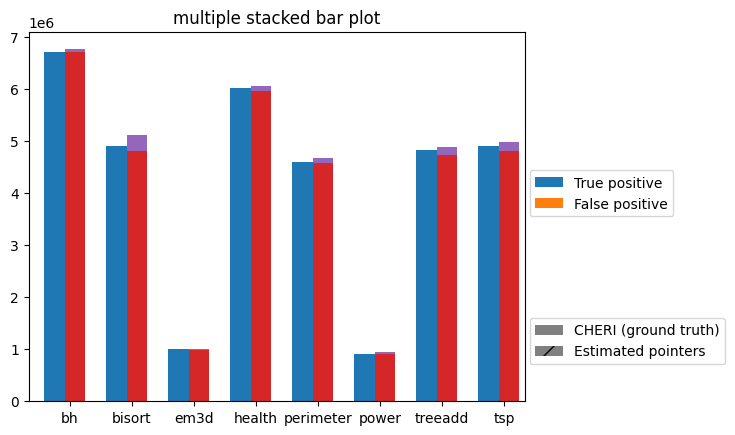

In [344]:
plot_clustered_stacked([df, df_over], ['CHERI (ground truth)', 'Estimated pointers'])

<Axes: ylabel='Number of pointers'>

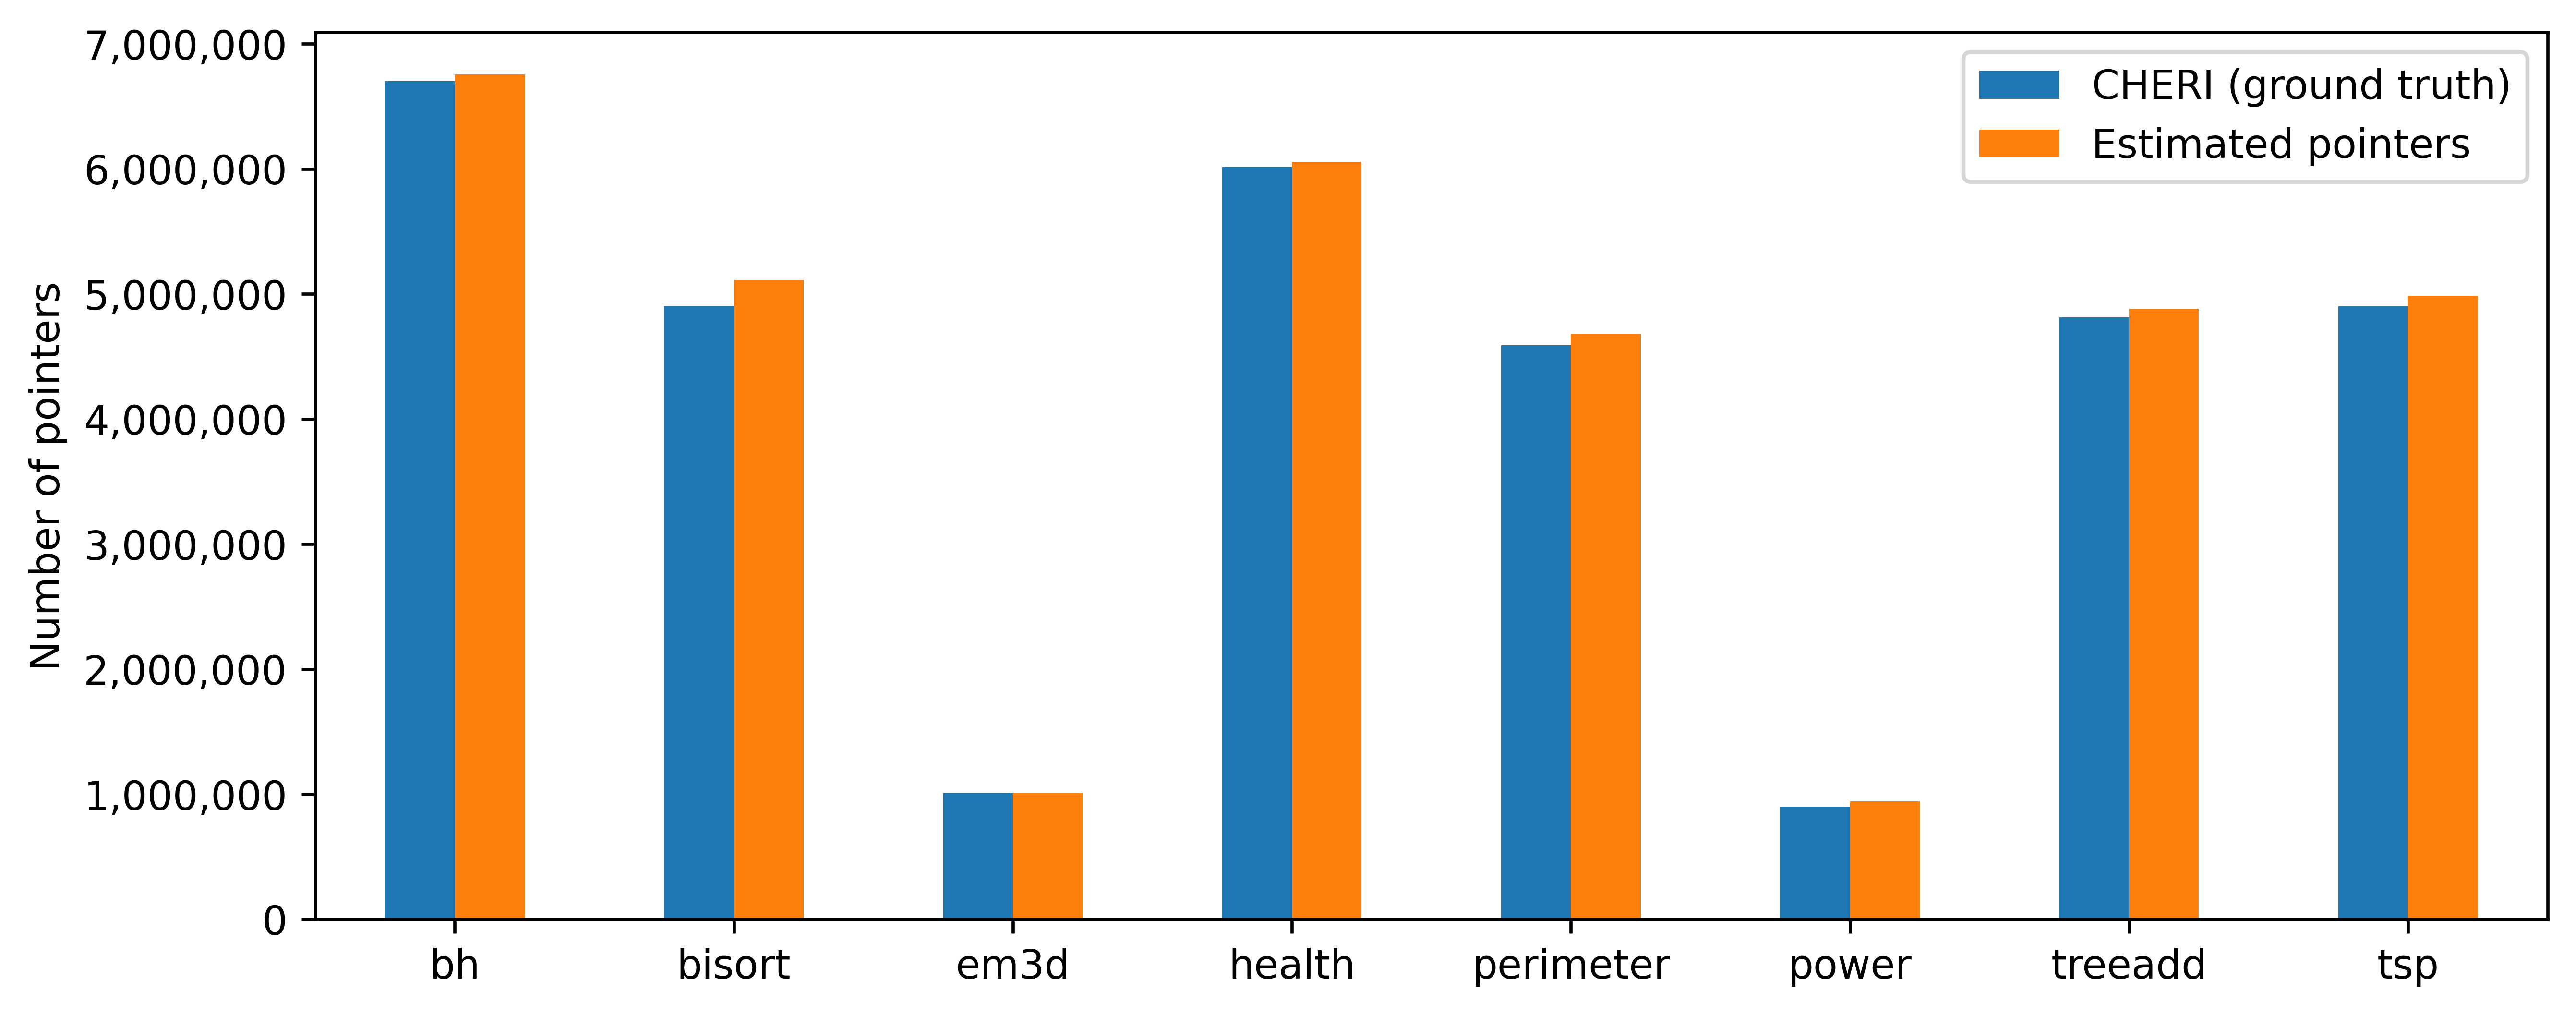

In [209]:
plot_bar(df, "Comparision of CHERI validity tag vs estimation of pointer for classification of values", "Number of pointers", "PointerEstimate")

<Axes: ylabel='Number of pointers'>

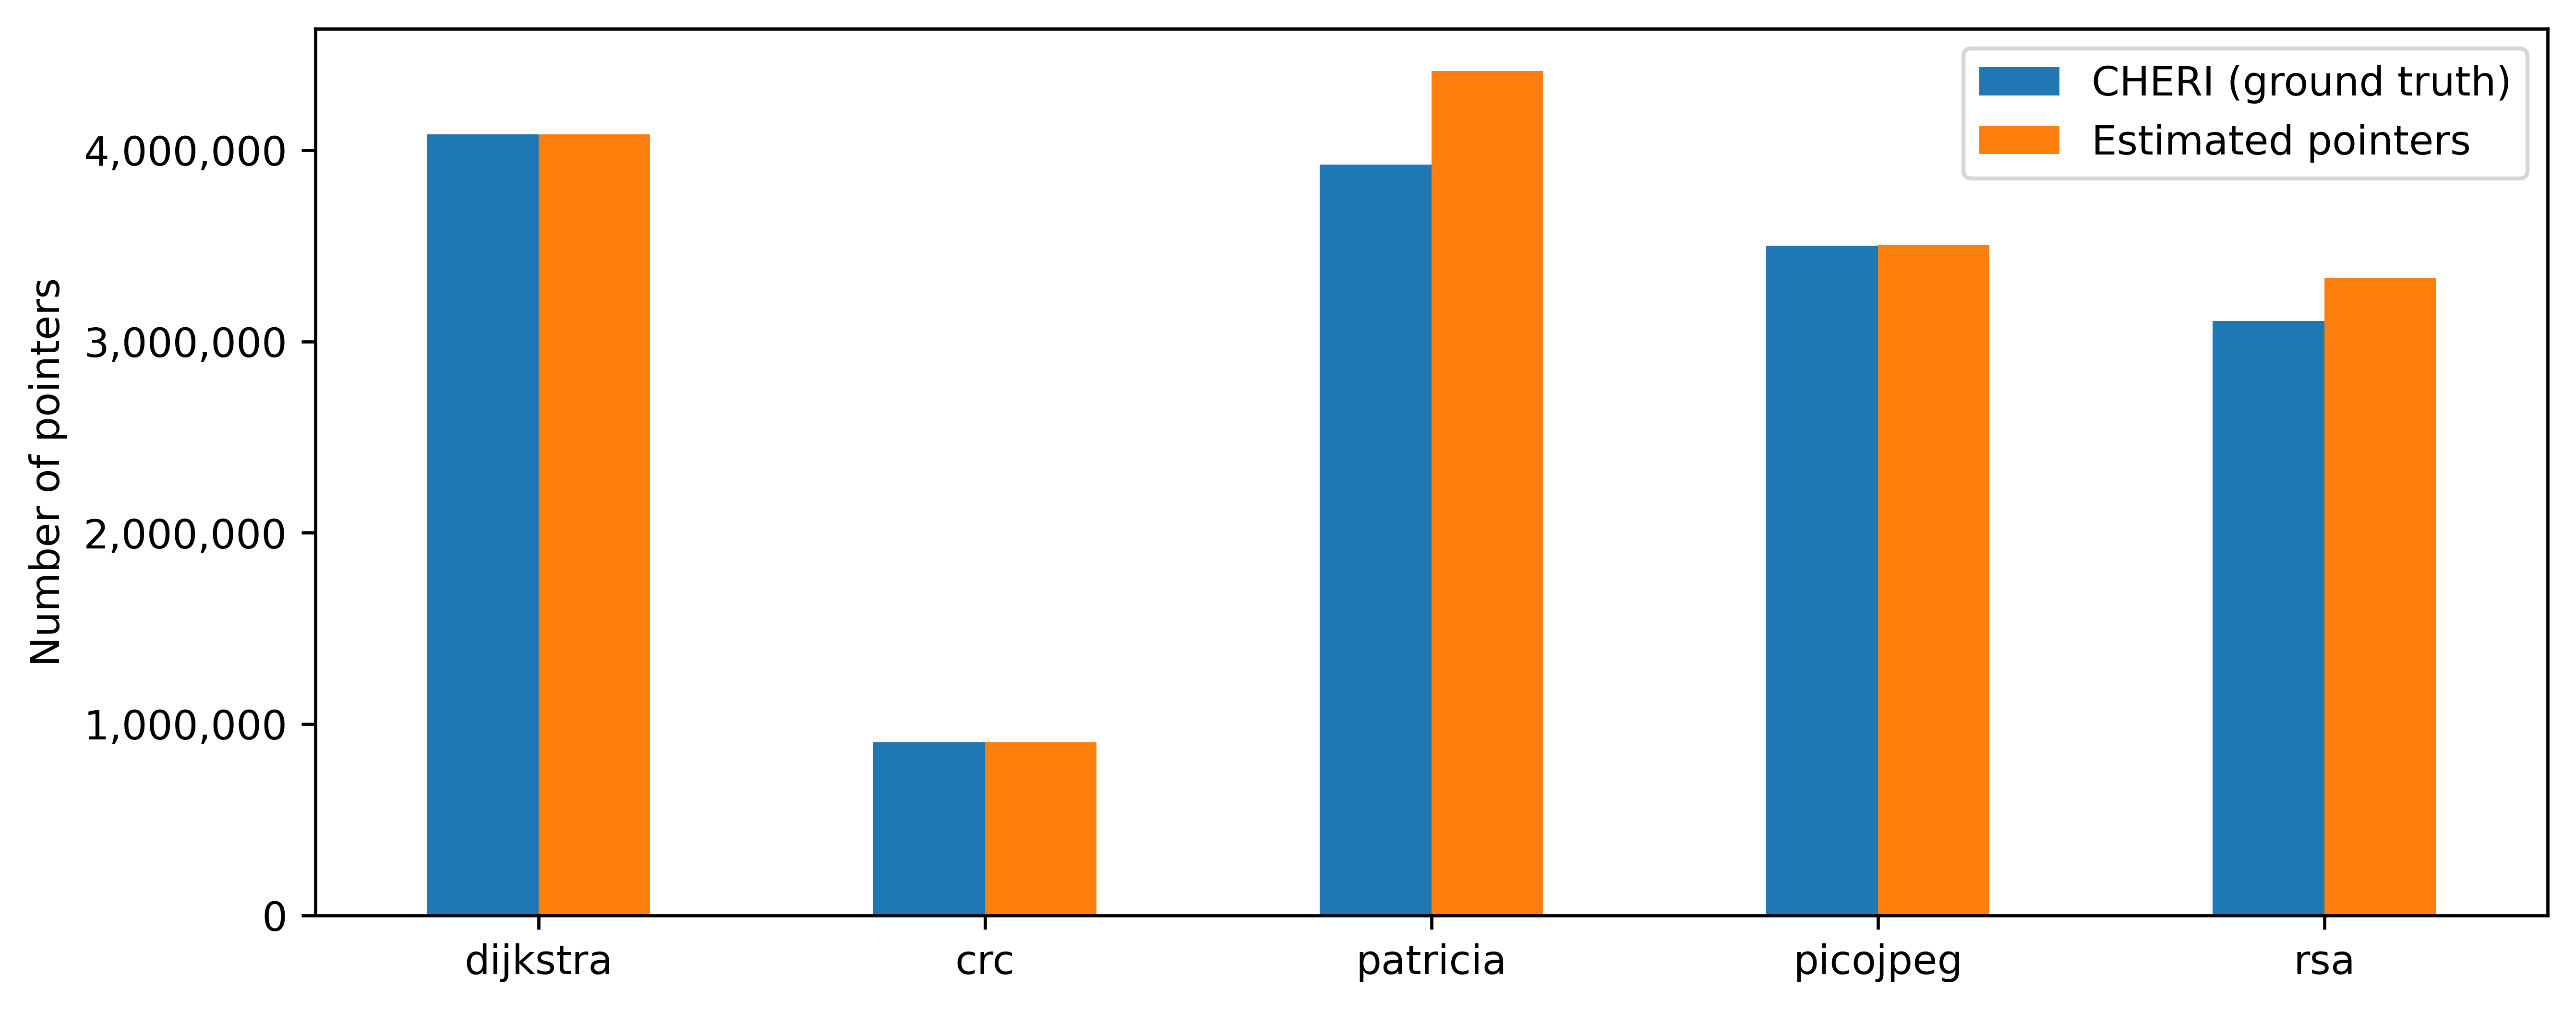

In [314]:
pointer_estimate_results = {}
for benchmark in bechmark_result_mibench.keys():
    true_pointer_count, correct_estimate_count, over_count, under_count = pointer_estimation(benchmark, bechmark_result_mibench)
    pointer_estimate_results[benchmark] = [true_pointer_count, correct_estimate_count+over_count]
    
df = pd.DataFrame.from_dict(pointer_estimate_results, orient='index',
                       columns=['CHERI (ground truth)', 'Estimated pointers'])
df

plot_bar(df, "Comparision of CHERI validity tag vs estimation of pointer for classification of values", "Number of pointers", "PointerEstimateMiBench")

# Number of different bound sizes

In [354]:
def bound_sizes(name, benchmark_var):
    bound_sizes_set = set()
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        bound_sizes_set.add(data_arrival.requestCap.boundsLength)
            
    return len(bound_sizes_set)
    

In [355]:
bound_size_results = {}
for benchmark in benchmark_names:
    bound_size_count = bound_sizes(benchmark, benchmark_results)
    bound_size_results[benchmark] = [bound_size_count]

In [356]:
df = pd.DataFrame.from_dict(bound_size_results, orient='index',
                       columns=['Number of different bound sizes'])
df

,Number of different bound sizes
bh,21
bisort,23
em3d,41
health,27
perimeter,15
power,21
treeadd,22
tsp,22


<Axes: ylabel='Number of distinct capbility bound sizes'>

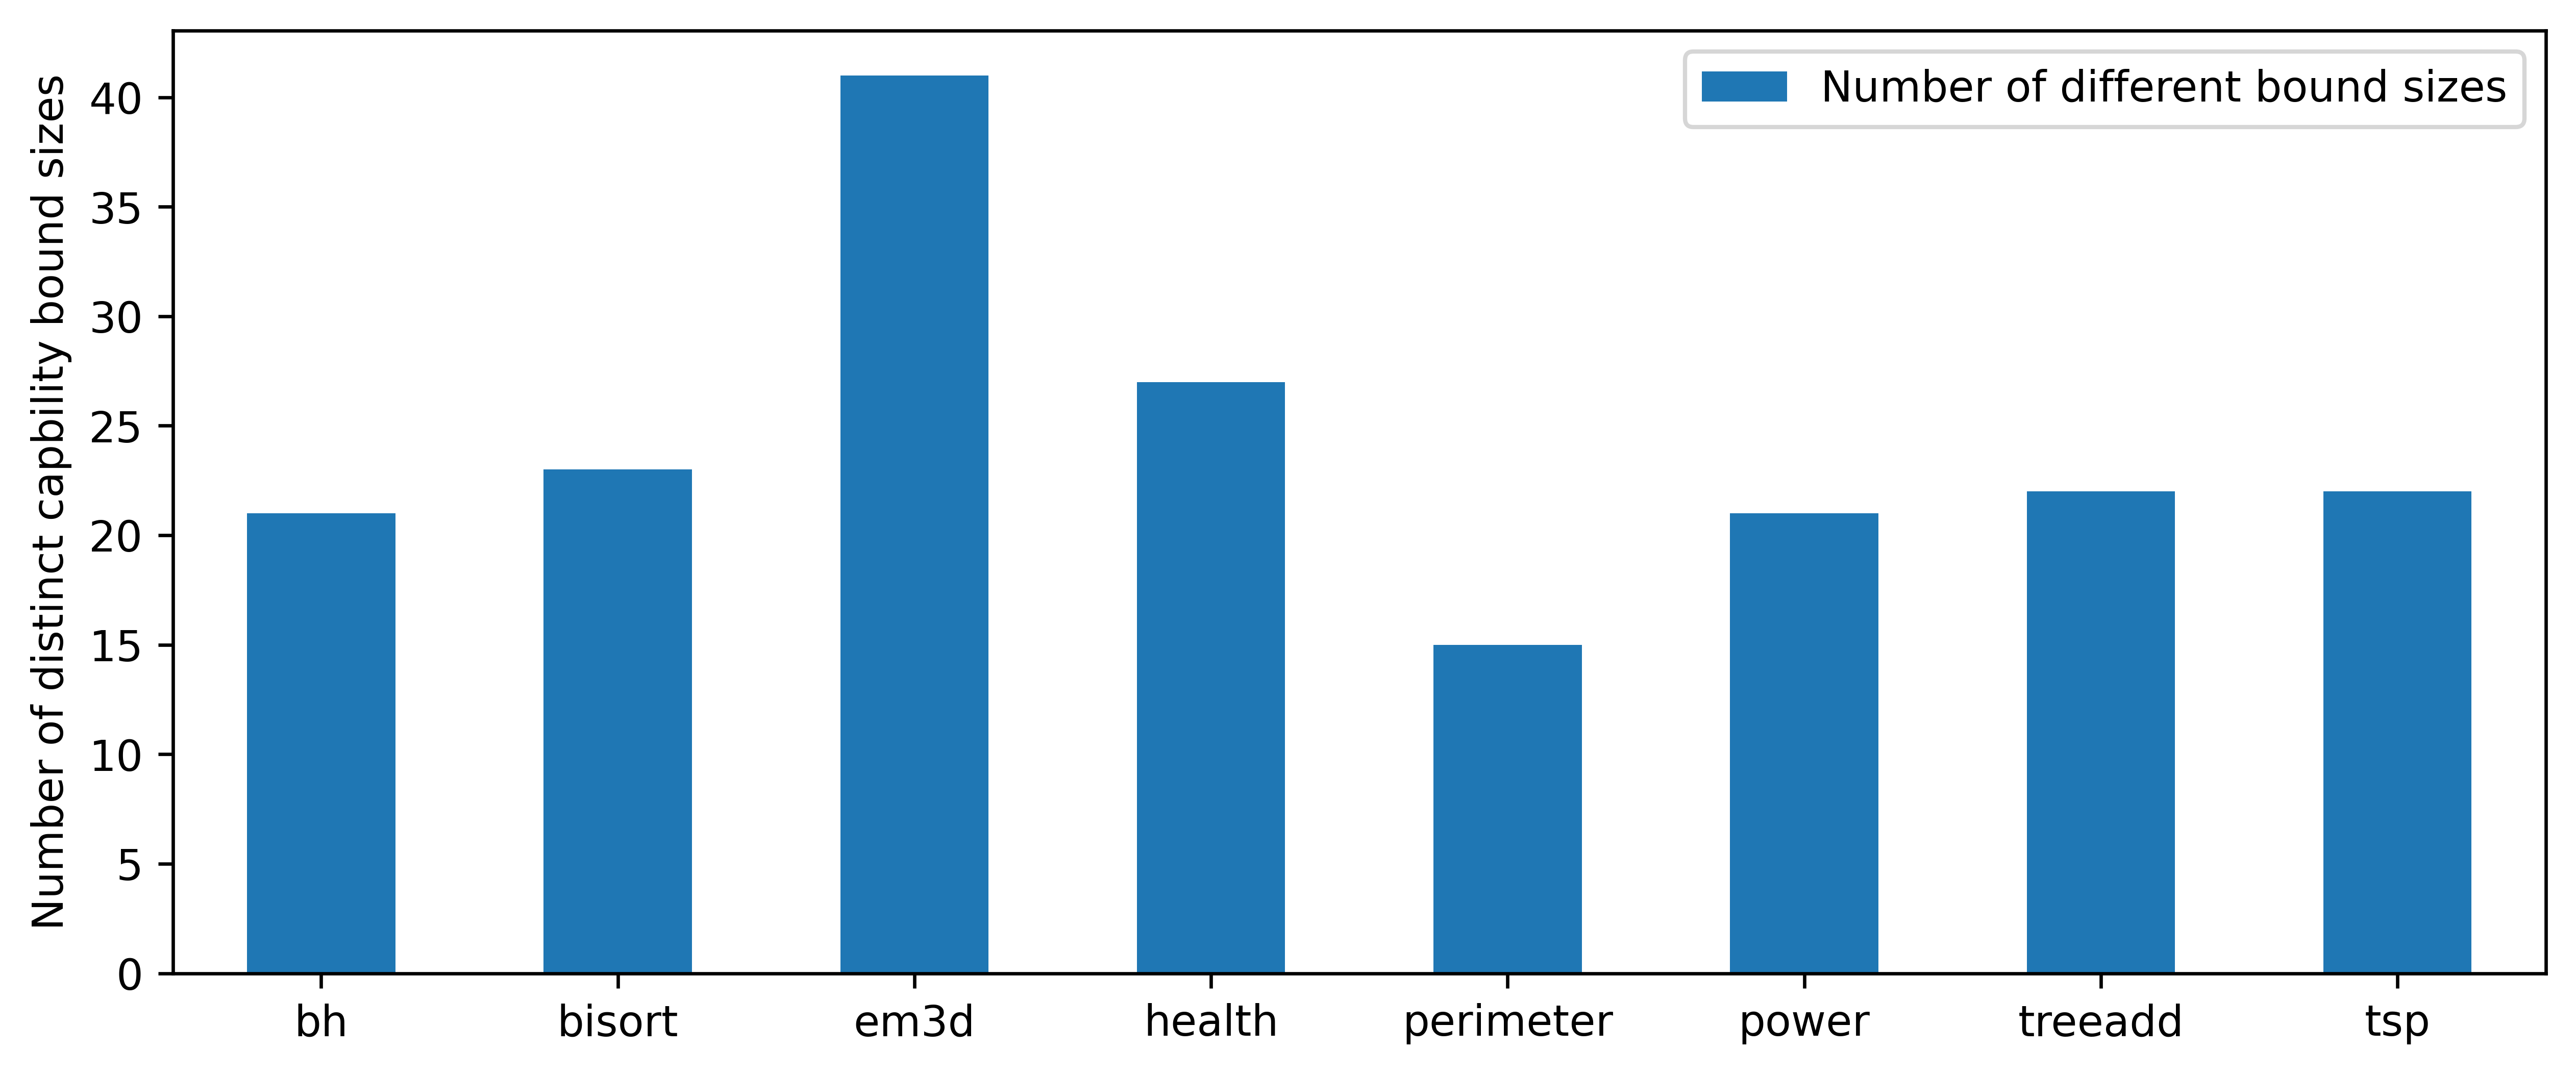

In [357]:
plot_bar(df, "Number of distinct capability bound sizes", "Number of distinct capbility bound sizes", "BoundSizesAgg")

## Mibench

In [318]:
bound_size_results = {}
for benchmark in benchmark_name_mibench:
    bound_size_count = bound_sizes(benchmark, bechmark_result_mibench)
    bound_size_results[benchmark] = [bound_size_count]

<Axes: ylabel='Number of distinct capbility bound sizes'>

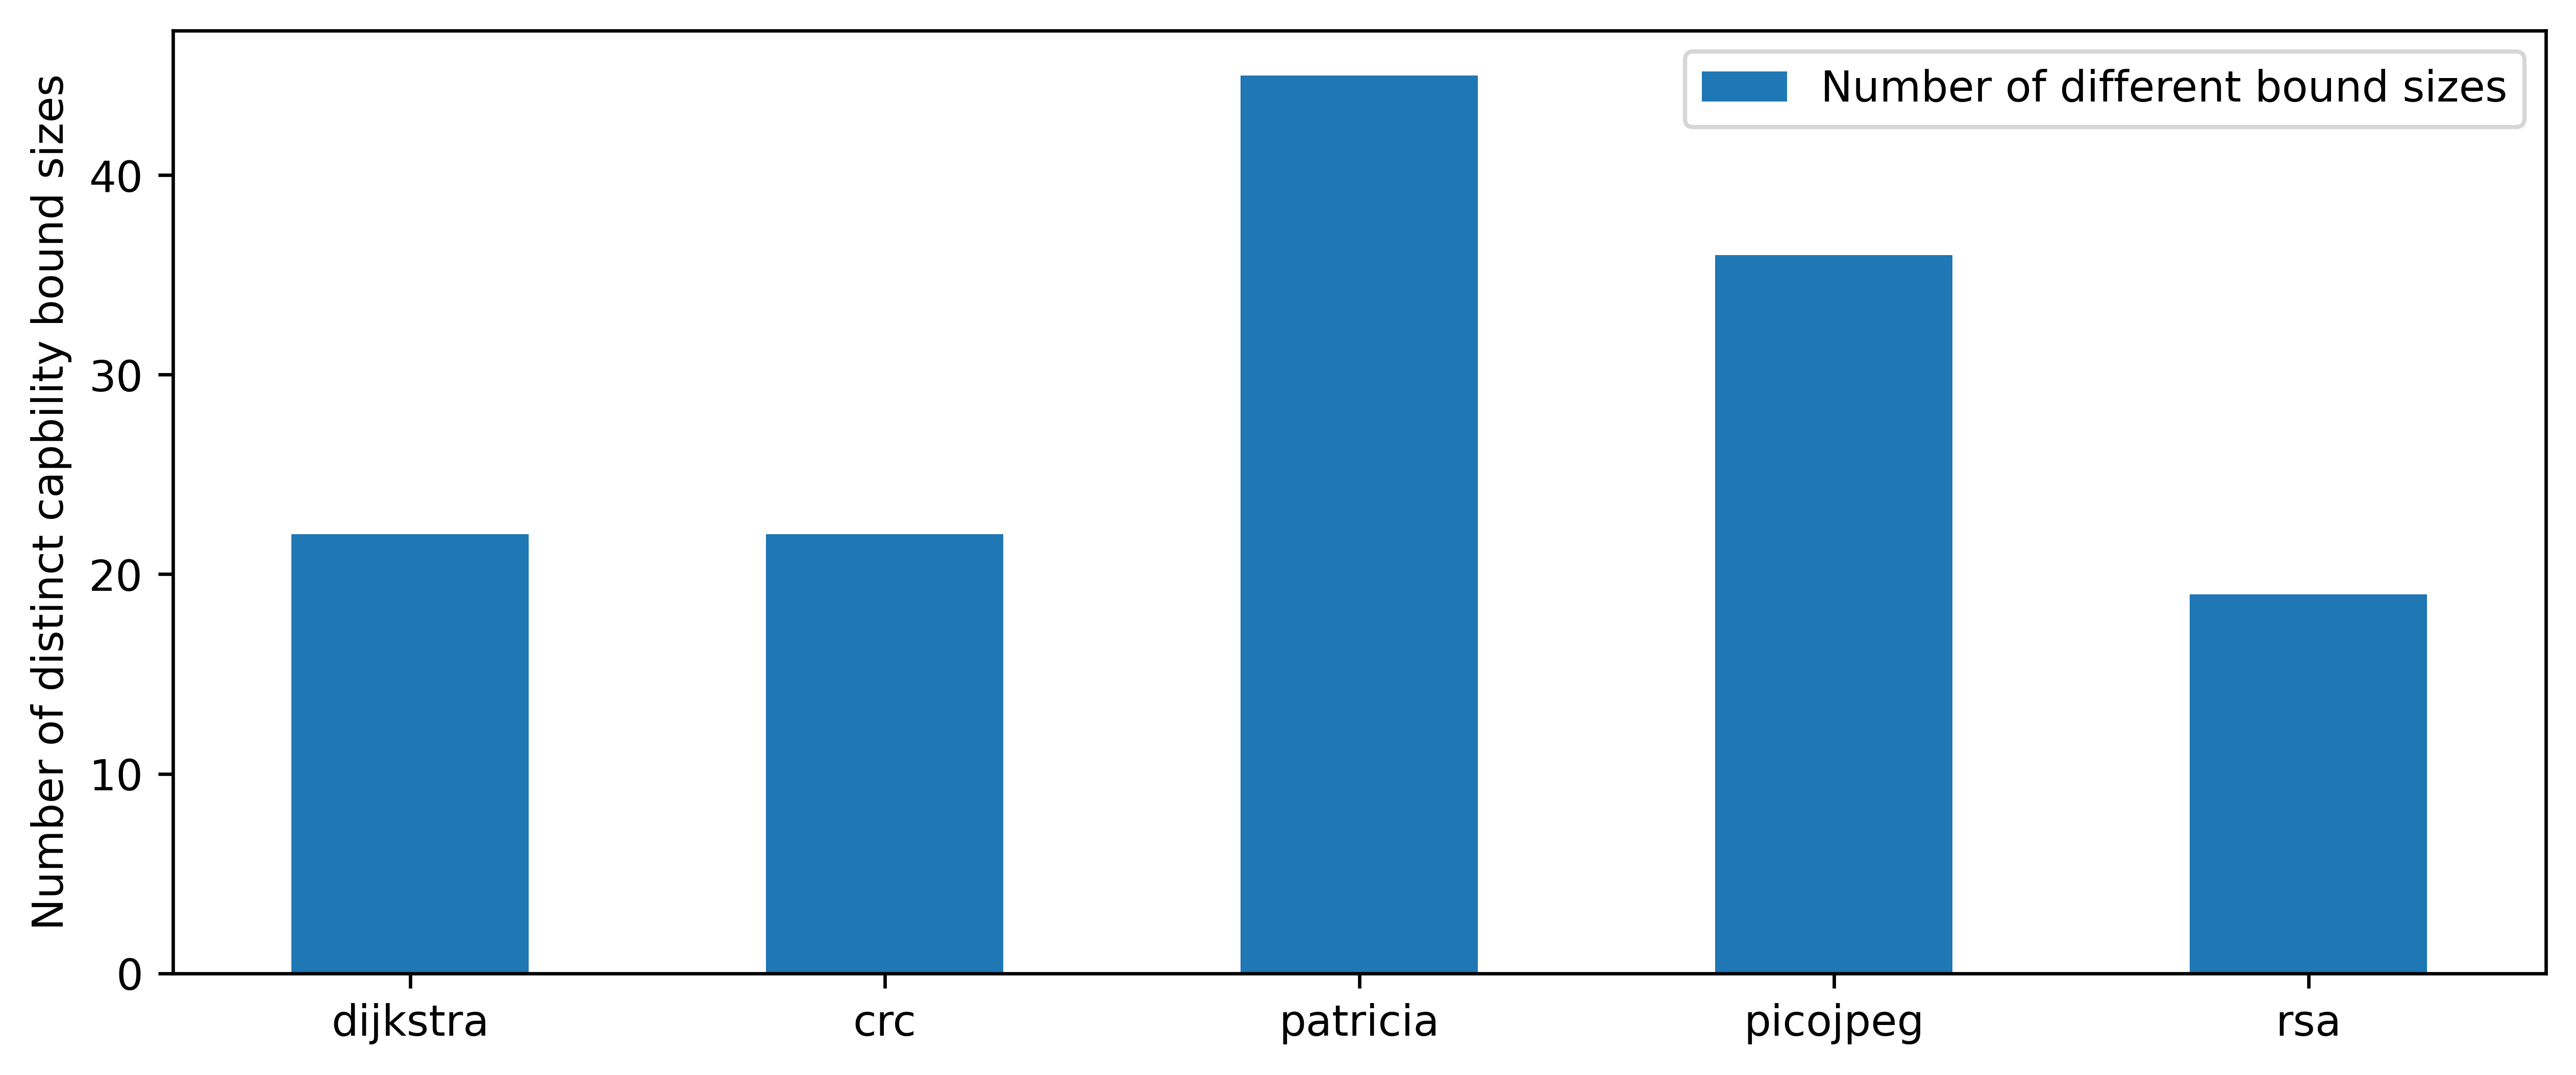

In [319]:
df = pd.DataFrame.from_dict(bound_size_results, orient='index',
                       columns=['Number of different bound sizes'])
df
plot_bar(df, "Number of distinct capability bound sizes", "Number of distinct capbility bound sizes", "BoundSizesAggMiBench")

# Counts for each different bound size

In [320]:
def bound_sizes_count(name, benchmark_var):
    bound_sizes_counter = defaultdict(set)
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        for cap in data_arrival.capabilites:
            bound_sizes_counter[cap.cap.boundsLength].add(cap.cap.boundsVirtBase)
            
    return dict_of_set_to_count(bound_sizes_counter)
    

In [153]:
bound_size_counter_results = {}
for benchmark in benchmark_names:
    bound_size_counts = bound_sizes_count(benchmark)
    bound_size_counter_results[benchmark] = bound_size_counts

In [166]:
df = nested_dict_to_df(bound_size_counter_results)
df

,1,2,3,4,6,7,8,9,10,11,...,352,1024,1840,2048,2096,4096,4128,131072,131328,36893488147419103231
bh,1.0,1.0,1.0,6.0,1.0,1.0,8.0,1.0,1.0,NaN,...,NaN,1.0,1.0,NaN,1.0,2.0,1.0,1.0,NaN,1.0
bisort,1.0,NaN,NaN,3964.0,NaN,1.0,5.0,NaN,NaN,1.0,...,NaN,NaN,1.0,NaN,NaN,3958.0,1.0,NaN,1.0,1.0
em3d,NaN,NaN,NaN,479.0,NaN,1.0,22.0,NaN,NaN,1.0,...,NaN,NaN,1.0,2.0,NaN,472.0,1.0,NaN,1.0,1.0
health,NaN,NaN,NaN,1550.0,NaN,1.0,8.0,NaN,NaN,NaN,...,1365.0,NaN,1.0,NaN,NaN,1548.0,1.0,1.0,NaN,1.0
perimeter,NaN,NaN,NaN,3.0,NaN,1.0,5.0,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1.0,1.0,1.0,NaN,1.0
power,NaN,NaN,NaN,3.0,NaN,1.0,7.0,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,2.0,1.0,NaN,1.0,1.0
treeadd,NaN,NaN,NaN,3949.0,NaN,1.0,5.0,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,3947.0,1.0,1.0,NaN,1.0
tsp,1.0,NaN,NaN,3953.0,NaN,2.0,5.0,NaN,1.0,1.0,...,NaN,NaN,1.0,NaN,NaN,3948.0,1.0,1.0,NaN,1.0


/local/scratch-3/tm746/tmp/ipykernel_1107831/485032999.py:7: UserWarning: The label '_Hidden label' of <BarContainer object of 8 artists> starts with '_'. It is thus excluded from the legend.
  ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 100\ndifferent virtual bases)", loc='center left', bbox_to_anchor=(1, 0.5))


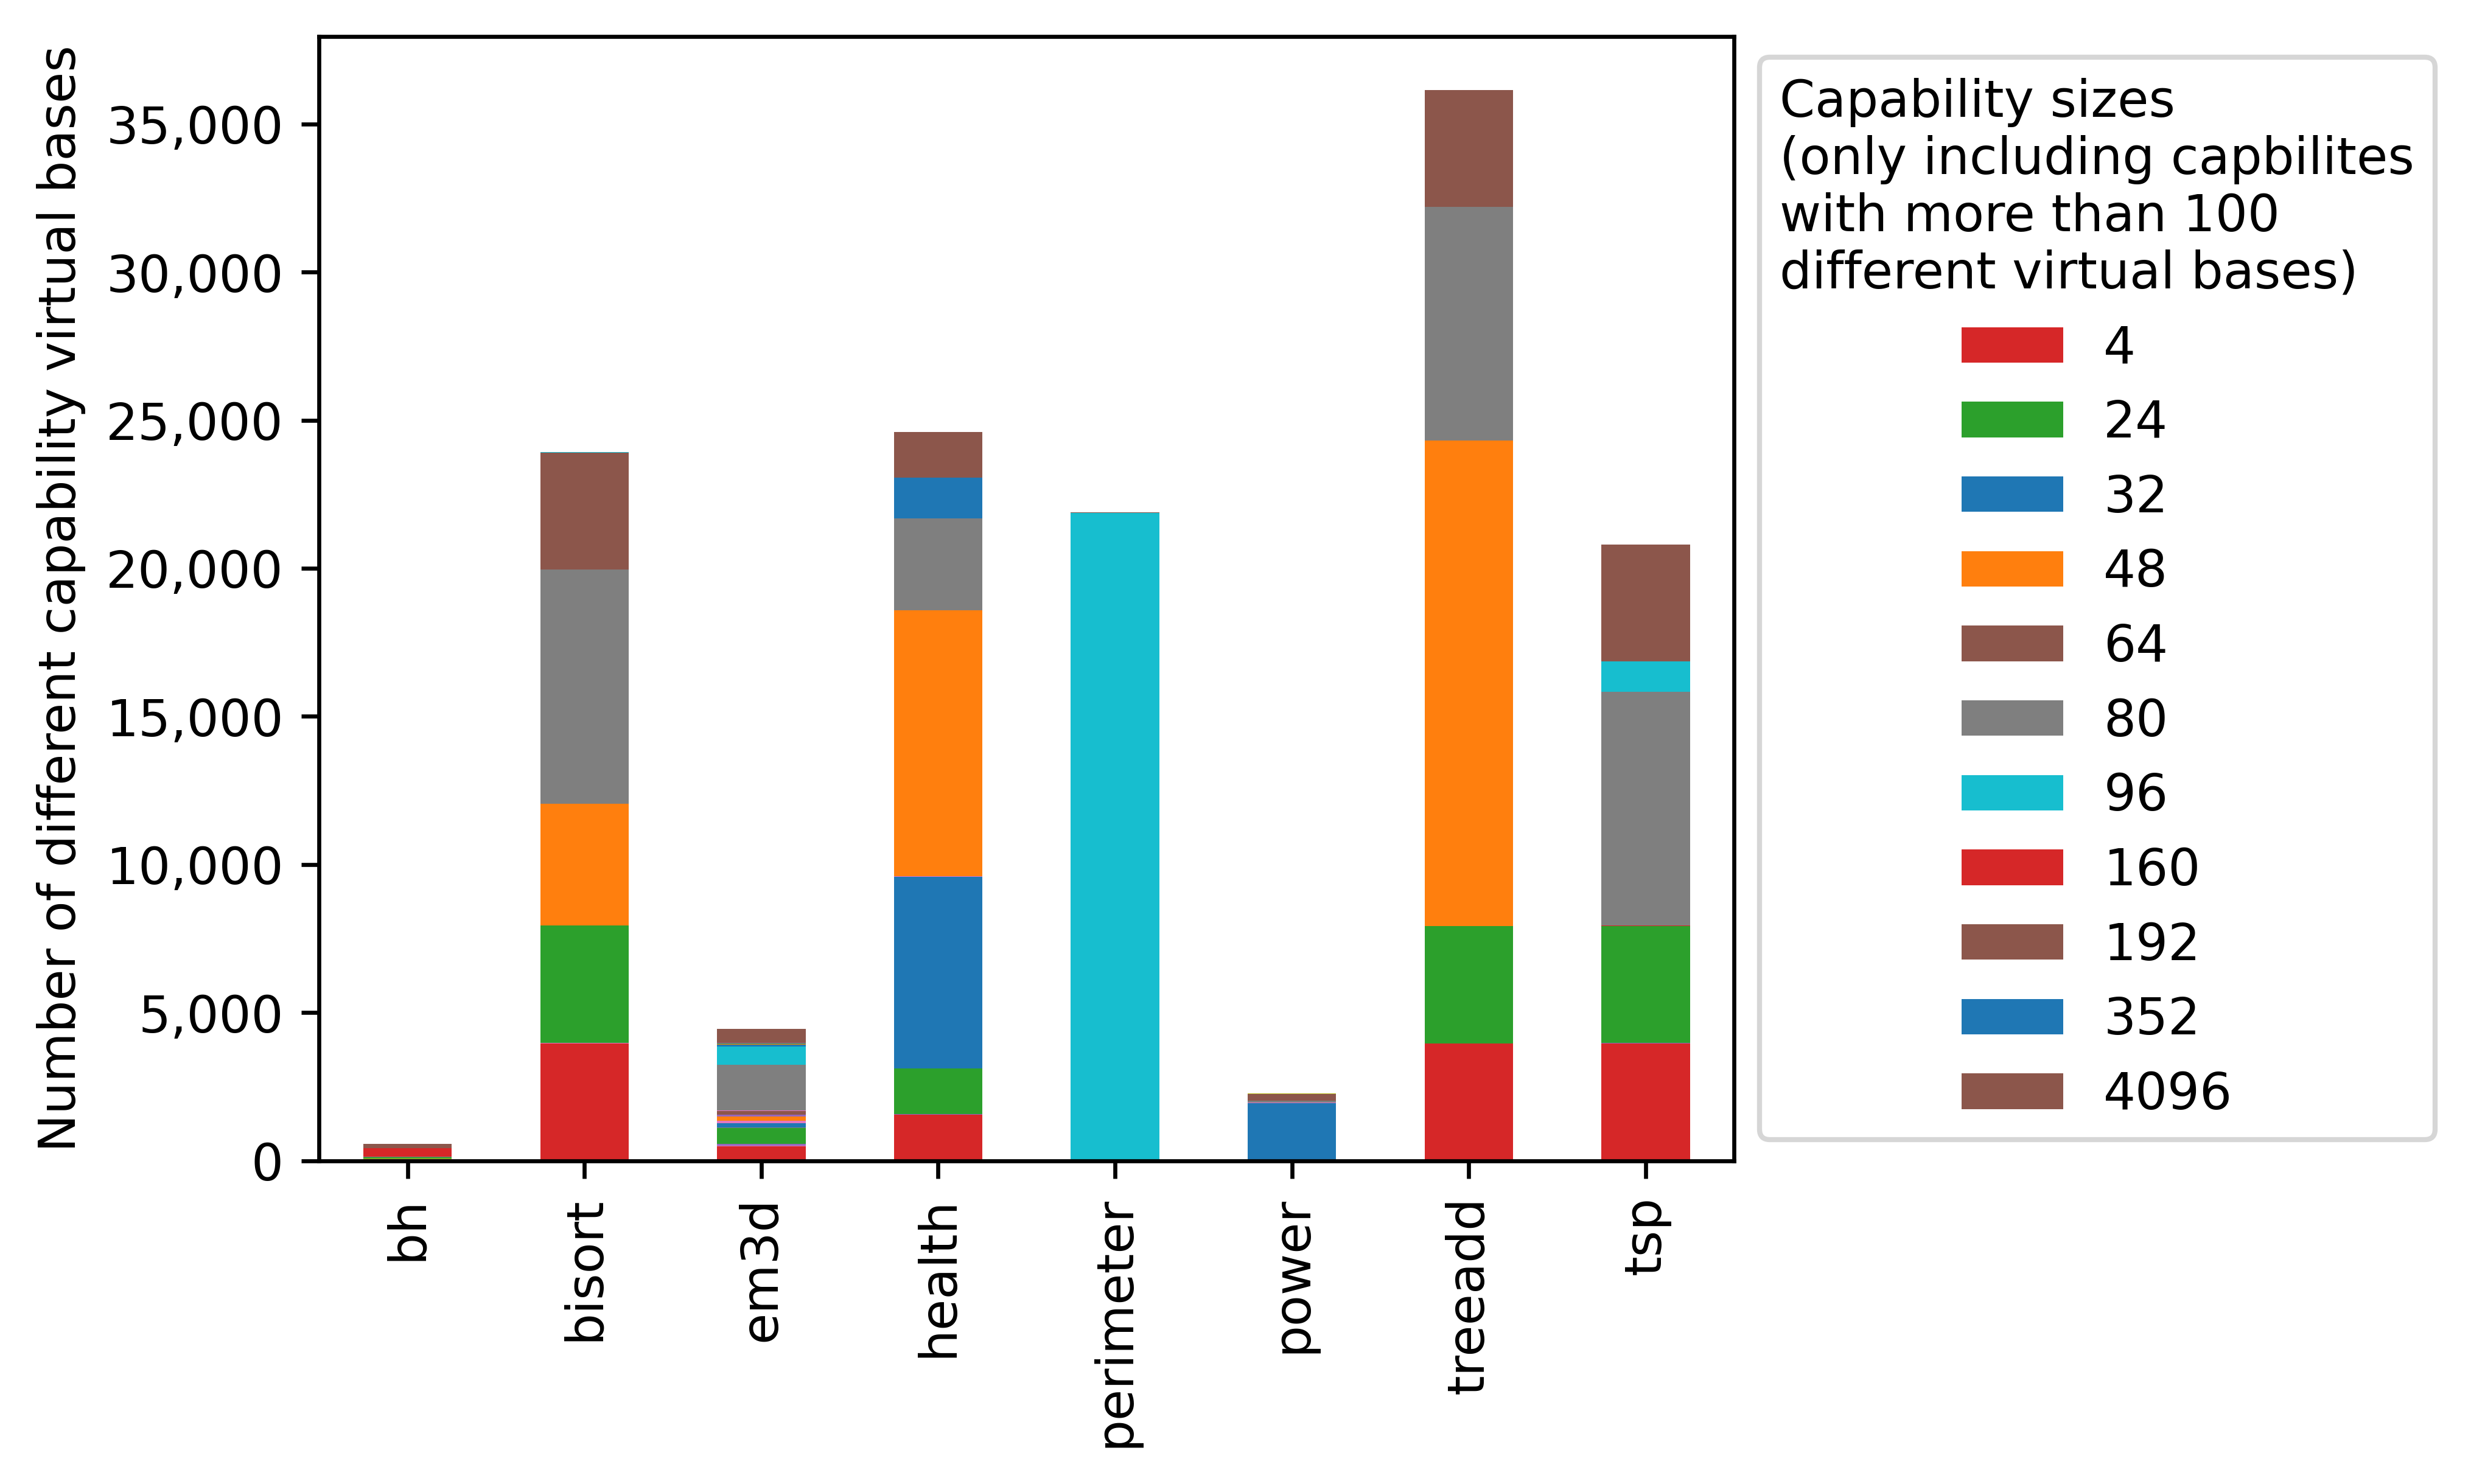

In [204]:
fig = plt.figure(figsize=(5,4), dpi=600)
ax = fig.gca()
ax = df.plot.bar(rot=0, title="", ylabel="Number of different capability virtual bases", ax=ax, stacked=True)
ax.get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
labels = [(col if col in df.columns[(df > 100).any()] else '_Hidden label') for col in df.columns]
ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 100\ndifferent virtual bases)", loc='center left', bbox_to_anchor=(1, 0.5))
ax.tick_params(axis='x', labelrotation=90)
fig.savefig("MotivationGraphs/BoundSizesVirtBaseAgg.pdf", bbox_inches='tight')


## MiBench

In [411]:
bound_size_counter_results = {}
for benchmark in benchmark_name_mibench:
    bound_size_counts = bound_sizes_count(benchmark, bechmark_result_mibench)
    bound_size_counter_results[benchmark] = bound_size_counts

/local/scratch-3/tm746/tmp/ipykernel_1107831/2806527460.py:8: UserWarning: The label '_Hidden label' of <BarContainer object of 5 artists> starts with '_'. It is thus excluded from the legend.
  ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 100\ndifferent virtual bases)", loc='center left', bbox_to_anchor=(1, 0.5))


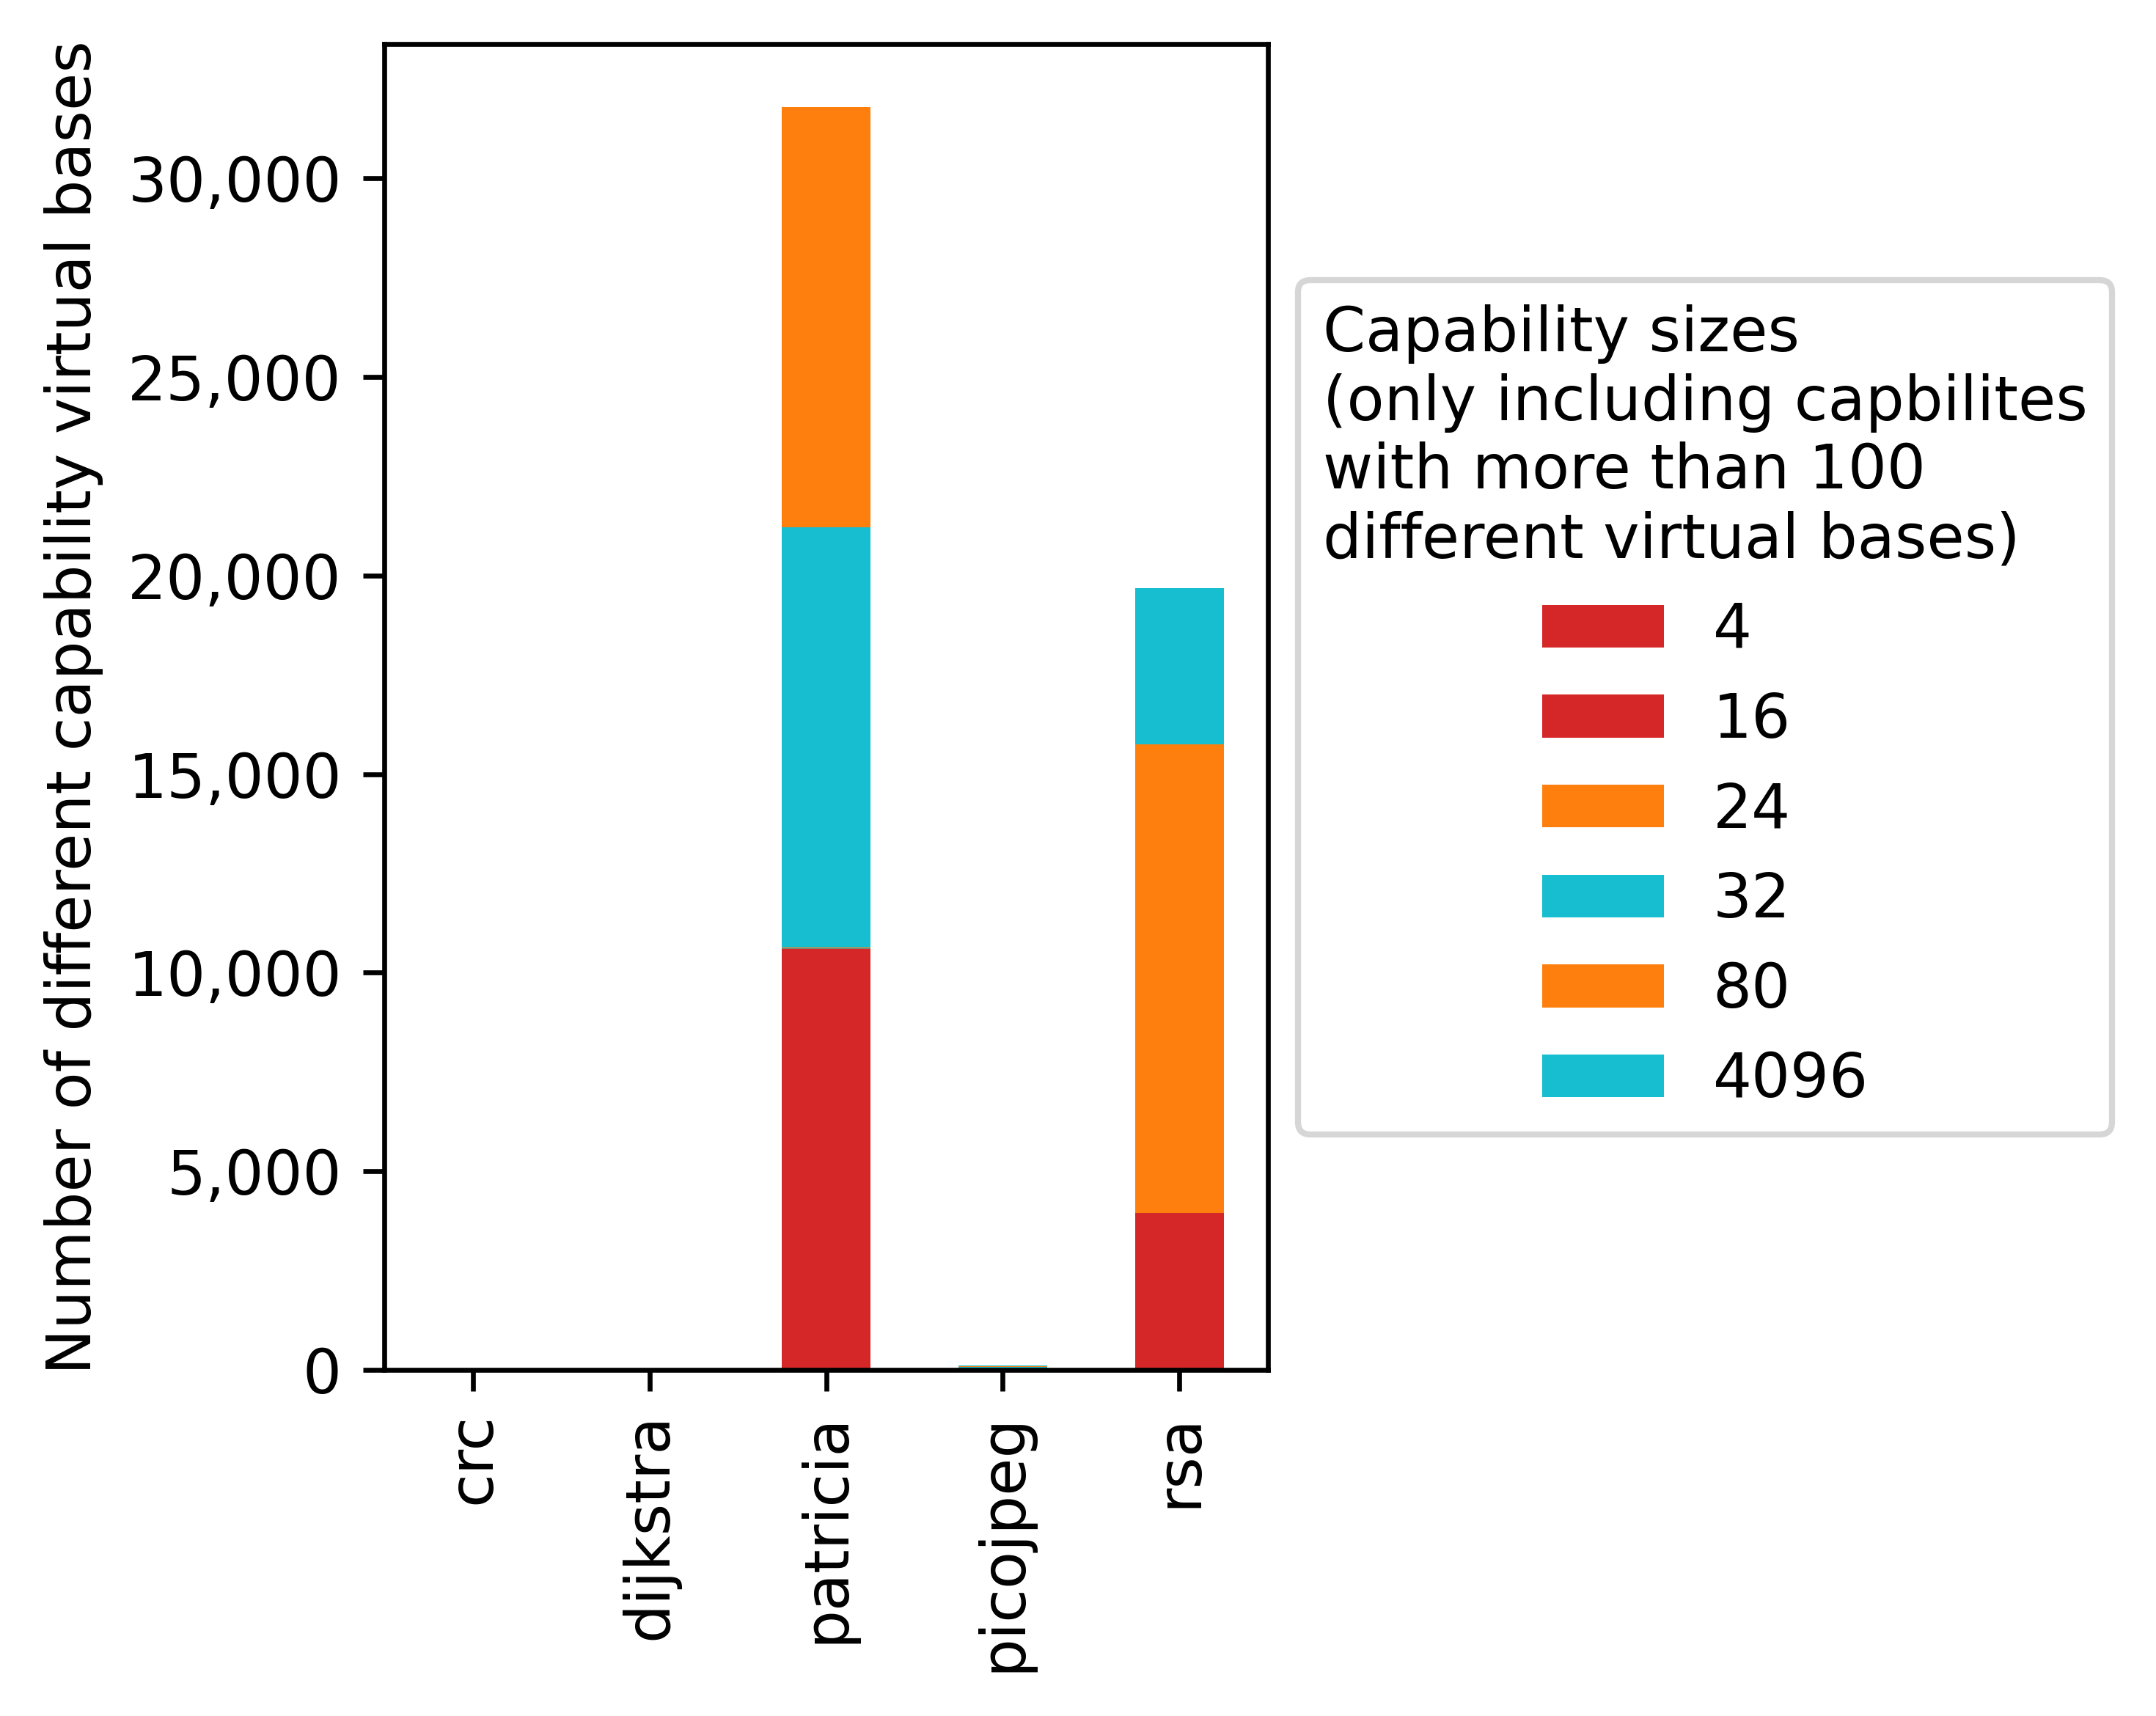

In [412]:
df = nested_dict_to_df(bound_size_counter_results)
fig = plt.figure(figsize=(5,4), dpi=600)
ax = fig.gca()
ax = df.plot.bar(rot=0, title="", ylabel="Number of different capability virtual bases", ax=ax, stacked=True)
ax.get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
labels = [(col if col in df.columns[(df > 100).any()] else '_Hidden label') for col in df.columns]
ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 100\ndifferent virtual bases)", loc='center left', bbox_to_anchor=(1, 0.5))
ax.tick_params(axis='x', labelrotation=90)
fig.tight_layout()
fig.savefig("MotivationGraphs/BoundSizesVirtBaseAggMibench.pdf", bbox_inches='tight')


# Virtbases per cap size actual requests

In [422]:
def bound_sizes_count_requests(name, benchmark_var):
    bound_sizes_counter = defaultdict(set)
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        if data_arrival.wasMiss:
            bound_sizes_counter[data_arrival.requestCap.boundsLength].add(data_arrival.requestCap.boundsVirtBase)
            
    return dict_of_set_to_count(bound_sizes_counter)
    

In [423]:
bound_size_counter_results_request = {}
for benchmark in benchmark_names:
    bound_size_counts = bound_sizes_count_requests(benchmark, benchmark_results)
    bound_size_counter_results_request[benchmark] = bound_size_counts

In [424]:
df = nested_dict_to_df(bound_size_counter_results_request)
df

,1,4,8,11,12,13,14,15,16,17,...,12048,12208,12320,12368,12400,13040,15968,131072,131328,18446744073709551615
bh,NaN,4.0,3.0,NaN,NaN,NaN,NaN,NaN,10.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,1.0
bisort,1.0,3.0,1.0,1.0,NaN,1.0,1.0,NaN,11.0,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0
em3d,NaN,8.0,14.0,1.0,NaN,1.0,NaN,NaN,59.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,1.0
health,NaN,2.0,5.0,NaN,1.0,1.0,NaN,NaN,7.0,1.0,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0
perimeter,NaN,2.0,3.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0
power,NaN,2.0,5.0,NaN,1.0,NaN,NaN,1.0,5.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
treeadd,NaN,3.0,3.0,NaN,NaN,1.0,NaN,NaN,6.0,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0
tsp,NaN,3.0,3.0,NaN,1.0,1.0,NaN,NaN,6.0,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0


/local/scratch-3/tm746/tmp/ipykernel_1107831/2153626375.py:7: UserWarning: The label '_Hidden label' of <BarContainer object of 8 artists> starts with '_'. It is thus excluded from the legend.
  ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 100\ndifferent virtual bases)", loc='center left', bbox_to_anchor=(1, 0.5))


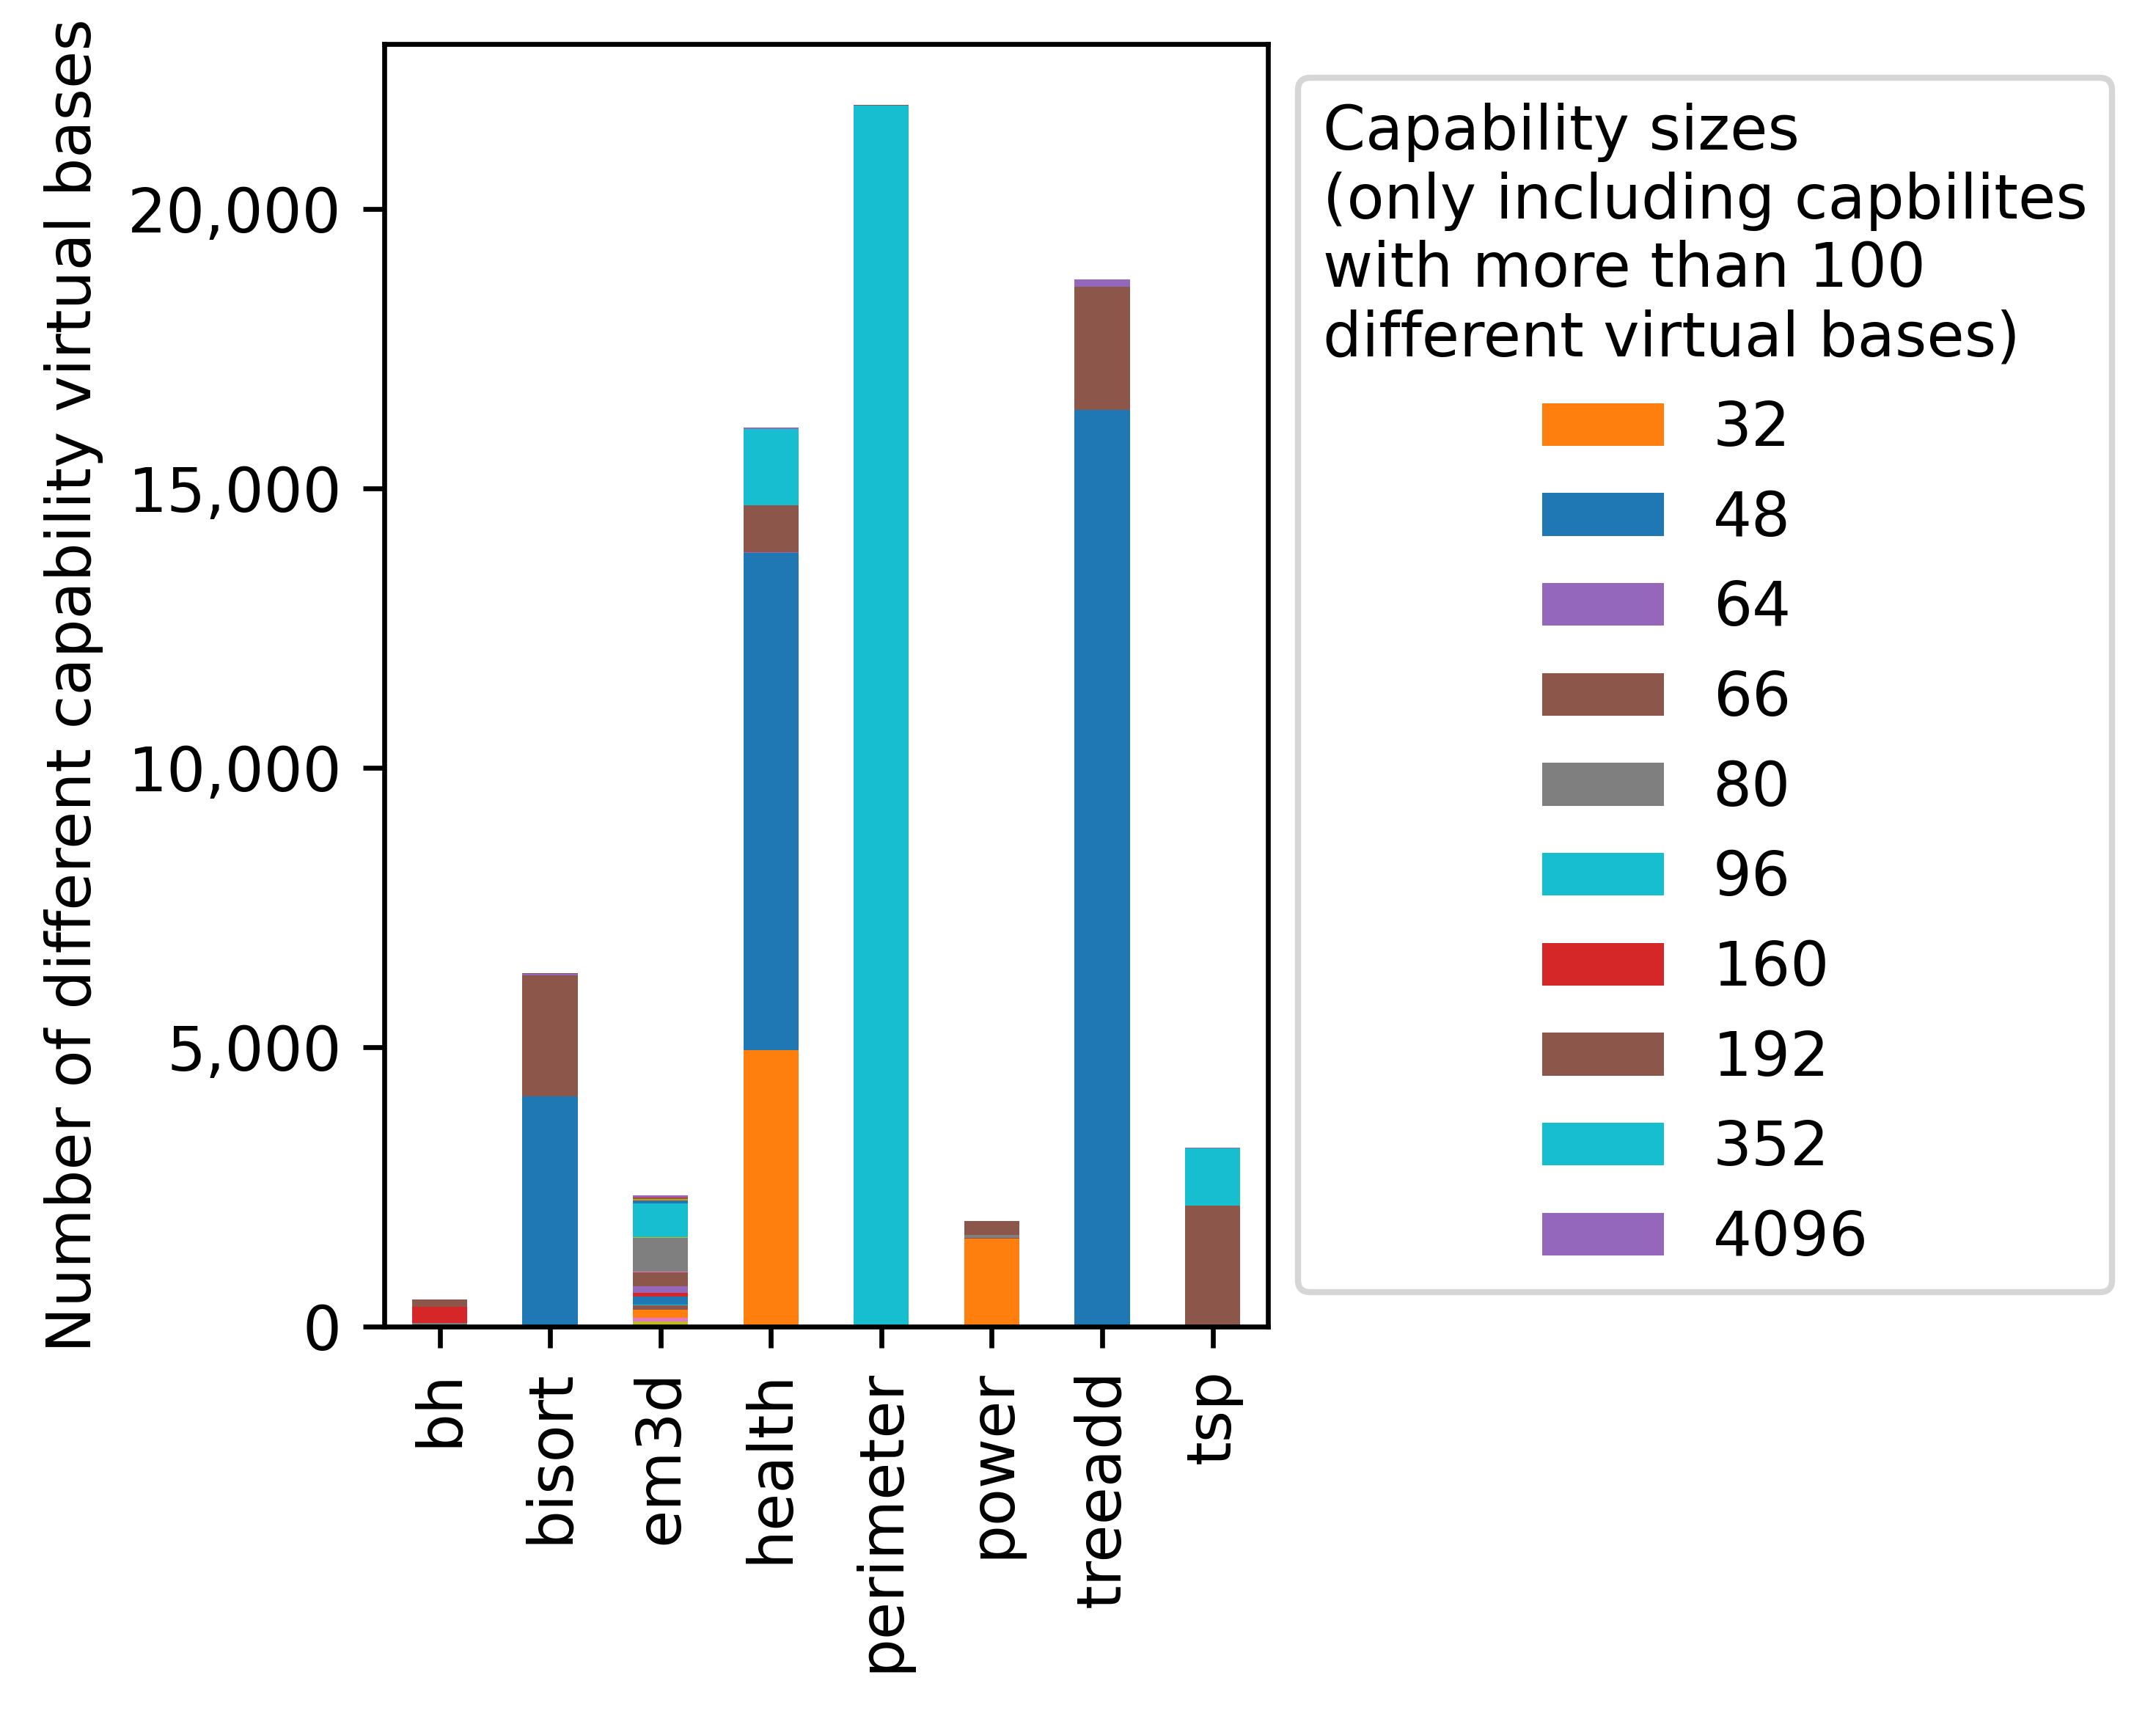

In [425]:
fig = plt.figure(figsize=(5,4), dpi=600)
ax = fig.gca()
ax = df.plot.bar(rot=0, title="", ylabel="Number of different capability virtual bases", ax=ax, stacked=True)
ax.get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
labels = [(col if col in df.columns[(df > 100).any()] else '_Hidden label') for col in df.columns]
ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 100\ndifferent virtual bases)", loc='center left', bbox_to_anchor=(1, 0.5))
ax.tick_params(axis='x', labelrotation=90)
fig.tight_layout()
fig.savefig("MotivationGraphs/BoundSizesVirtBaseAggRequests.pdf", bbox_inches='tight')

In [418]:
handles, labels = ax.get_legend_handles_labels()
for i in range(handles):
    

SyntaxError: unexpected EOF while parsing (106107822.py, line 3)

# MiBench

In [426]:
bound_size_counter_results_request = {}
for benchmark in benchmark_name_mibench:
    bound_size_counts = bound_sizes_count_requests(benchmark, bechmark_result_mibench)
    bound_size_counter_results_request[benchmark] = bound_size_counts

In [427]:
df = nested_dict_to_df(bound_size_counter_results_request)
df

,1,2,3,4,6,8,13,16,18,23,...,12288,15360,15888,40000,47488,131072,131328,160000,348672,18446744073709551615
crc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0
dijkstra,NaN,NaN,NaN,7.0,NaN,NaN,NaN,3.0,NaN,1.0,...,1.0,NaN,NaN,1.0,NaN,NaN,1.0,1.0,NaN,1.0
patricia,NaN,NaN,NaN,1.0,NaN,4.0,NaN,113.0,NaN,1.0,...,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0
picojpeg,6.0,3.0,3.0,2.0,2.0,NaN,NaN,5.0,NaN,1.0,...,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN,NaN,1.0
rsa,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0


/local/scratch-3/tm746/tmp/ipykernel_1107831/1011744656.py:7: UserWarning: The label '_Hidden label' of <BarContainer object of 5 artists> starts with '_'. It is thus excluded from the legend.
  ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 100\ndifferent virtual bases)", loc='center left', bbox_to_anchor=(1, 0.5))


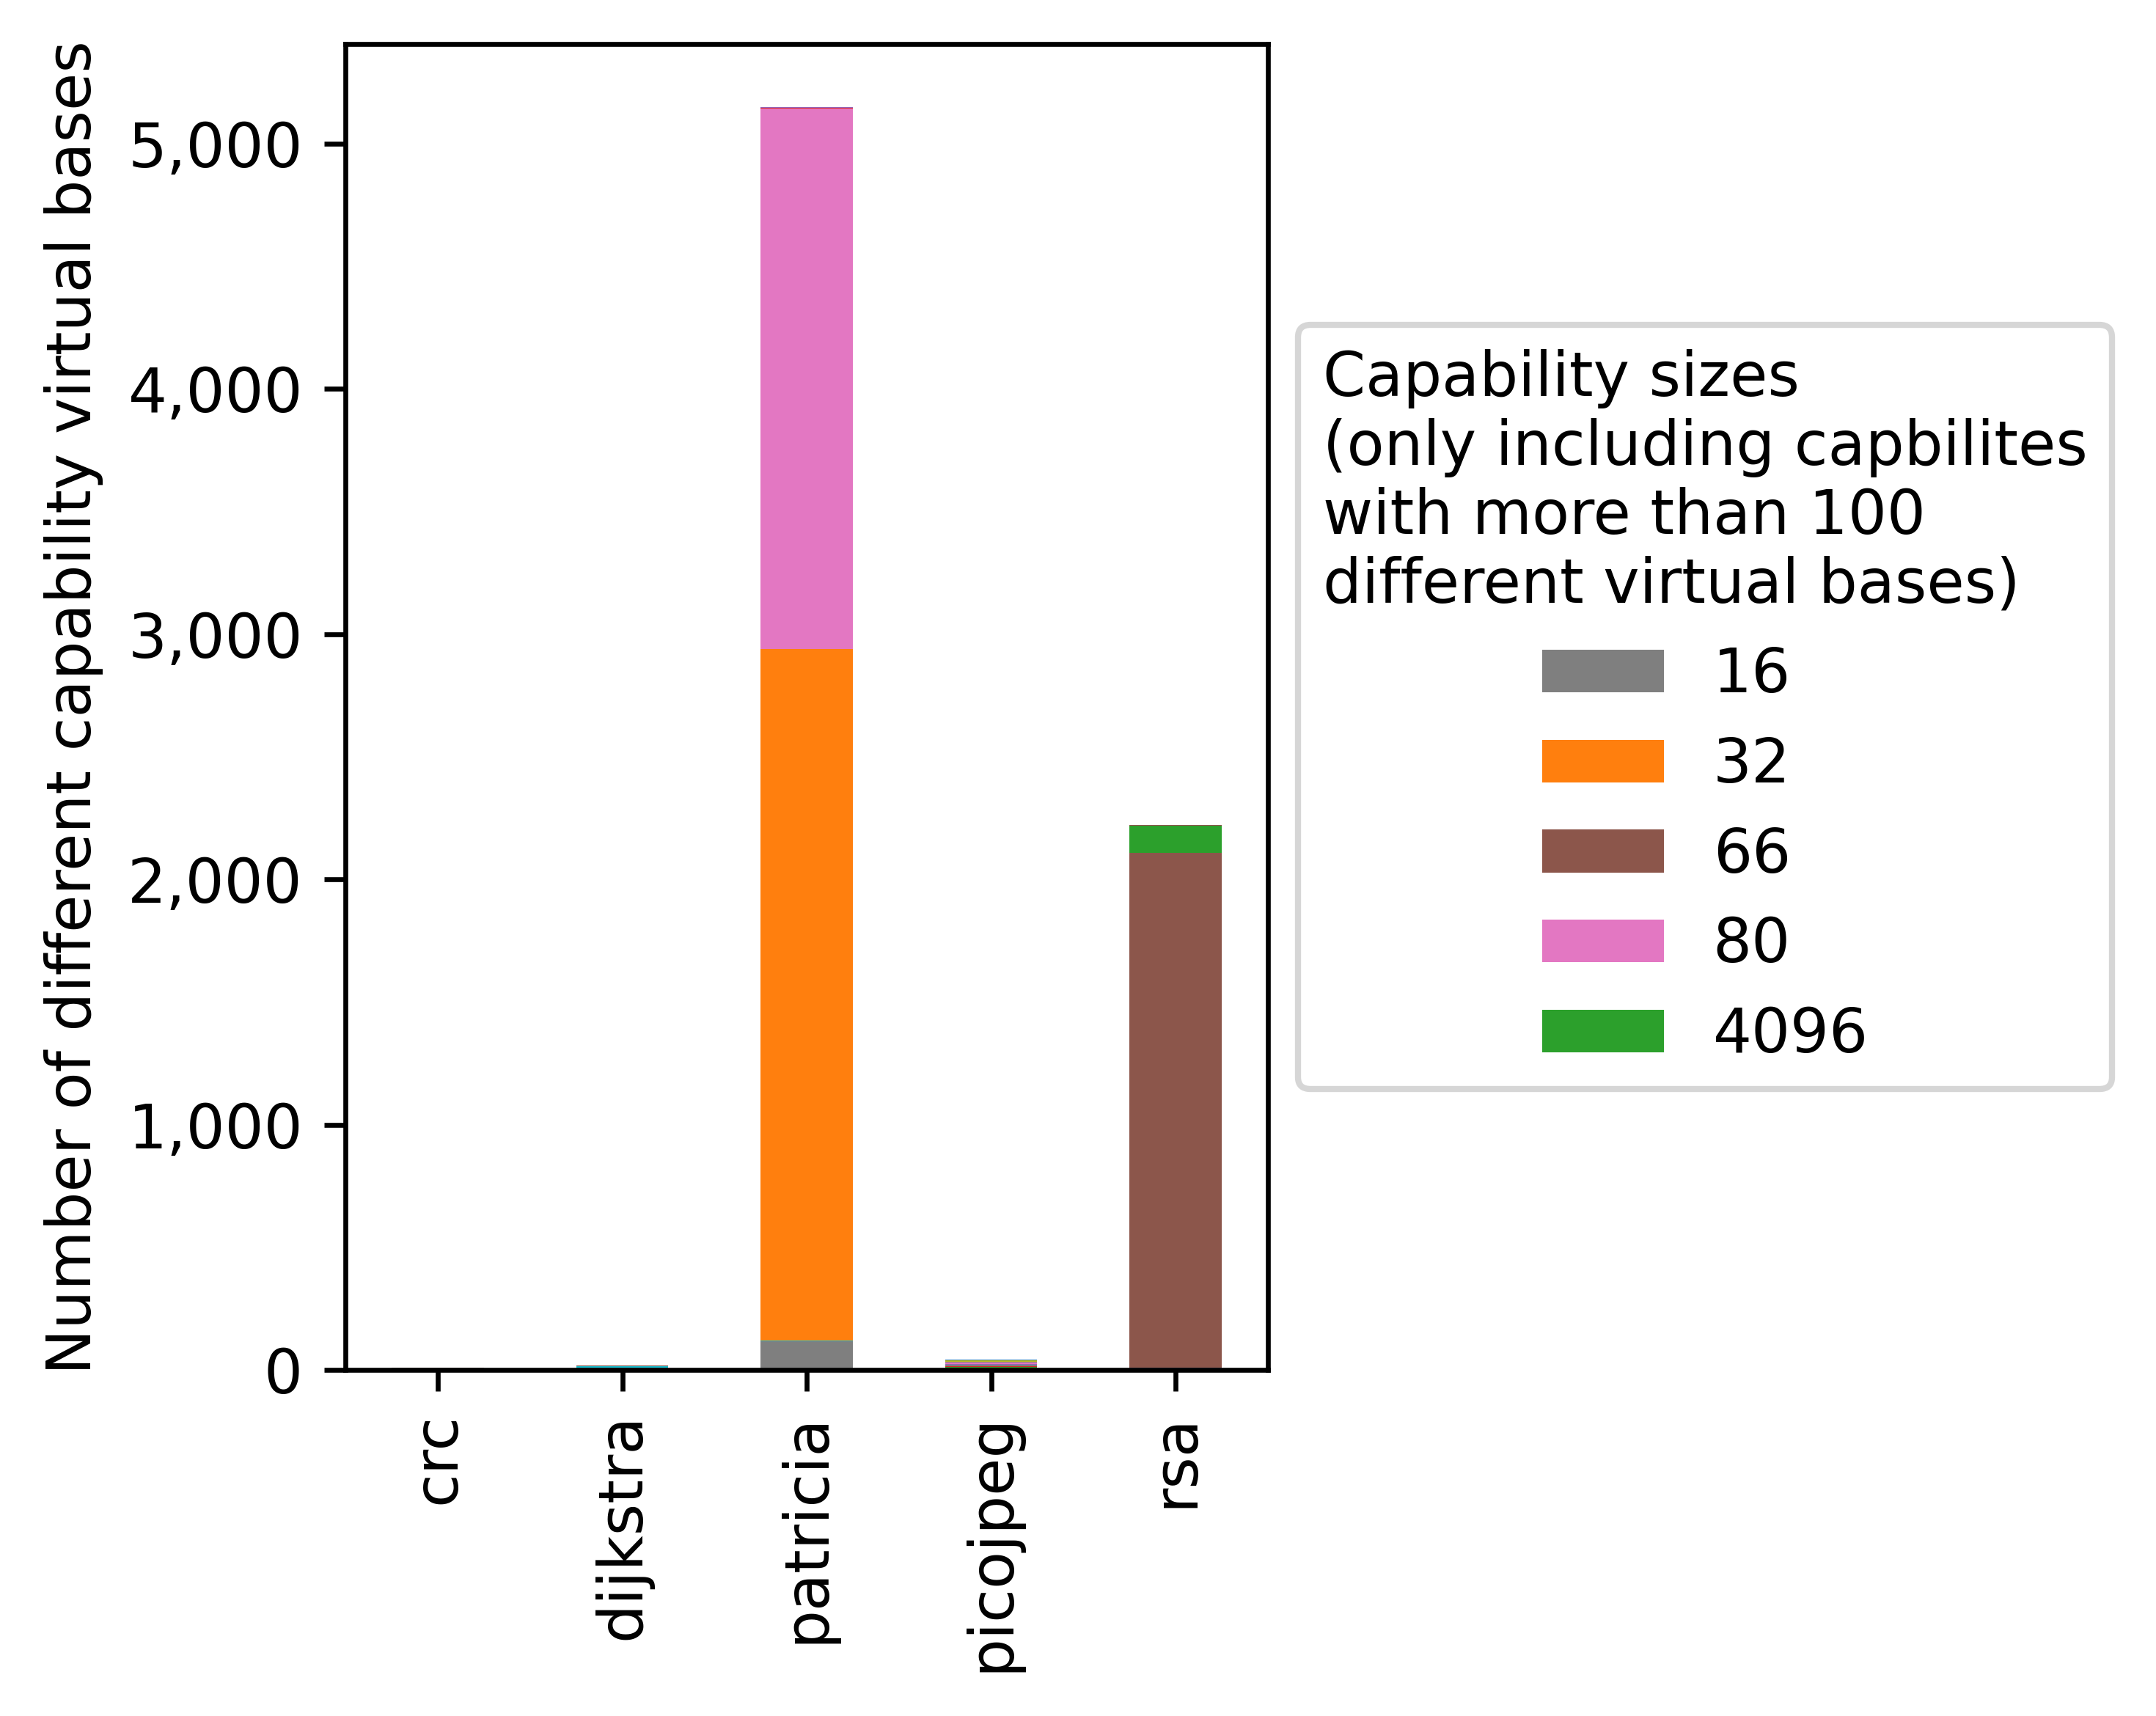

In [428]:
fig = plt.figure(figsize=(5,4), dpi=600)
ax = fig.gca()
ax = df.plot.bar(rot=0, title="", ylabel="Number of different capability virtual bases", ax=ax, stacked=True)
ax.get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
labels = [(col if col in df.columns[(df > 100).any()] else '_Hidden label') for col in df.columns]
ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 100\ndifferent virtual bases)", loc='center left', bbox_to_anchor=(1, 0.5))
ax.tick_params(axis='x', labelrotation=90)
fig.tight_layout()
fig.savefig("MotivationGraphs/BoundSizesVirtBaseAggRequestsMiBench.pdf", bbox_inches='tight')

# Offsets per capability size

In [326]:
def offset_cap_size(name, benchmark_var):
    offset_per_sizes_counter = defaultdict(set)
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        for cap in data_arrival.capabilites:
            offset_per_sizes_counter[cap.cap.boundsLength].add(cap.cap.boundsOffset)
            
    return dict_of_set_to_count(offset_per_sizes_counter)
    

In [216]:
offsets_per_size_counter_results = {}
for benchmark in benchmark_names:
    offsets_per_size_counts = offset_cap_size(benchmark)
    offsets_per_size_counter_results[benchmark] = offsets_per_size_counts

In [220]:
df = nested_dict_to_df(offsets_per_size_counter_results)
df

,1,2,3,4,6,7,8,9,10,11,...,352,1024,1840,2048,2096,4096,4128,131072,131328,36893488147419103231
bh,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,...,NaN,1.0,3.0,NaN,3.0,1.0,129.0,2.0,NaN,507.0
bisort,1.0,NaN,NaN,2.0,NaN,1.0,2.0,NaN,NaN,3.0,...,NaN,NaN,3.0,NaN,NaN,3.0,129.0,NaN,3959.0,4145.0
em3d,NaN,NaN,NaN,1.0,NaN,1.0,2.0,NaN,NaN,1.0,...,NaN,NaN,4.0,256.0,NaN,3.0,129.0,NaN,470.0,2167.0
health,NaN,NaN,NaN,2.0,NaN,1.0,2.0,NaN,NaN,NaN,...,6.0,NaN,3.0,NaN,NaN,4.0,129.0,1548.0,NaN,17965.0
perimeter,NaN,NaN,NaN,1.0,NaN,1.0,2.0,NaN,NaN,NaN,...,NaN,NaN,3.0,NaN,NaN,1.0,129.0,1.0,NaN,22394.0
power,NaN,NaN,NaN,1.0,NaN,1.0,2.0,NaN,NaN,NaN,...,NaN,NaN,3.0,NaN,NaN,7.0,129.0,NaN,5.0,2302.0
treeadd,NaN,NaN,NaN,1.0,NaN,1.0,2.0,NaN,NaN,NaN,...,NaN,NaN,3.0,NaN,NaN,3.0,129.0,3948.0,NaN,16419.0
tsp,1.0,NaN,NaN,1.0,NaN,1.0,2.0,NaN,1.0,1.0,...,NaN,NaN,4.0,NaN,NaN,3.0,129.0,3949.0,NaN,1095.0


/local/scratch-3/tm746/tmp/ipykernel_1107831/1843867672.py:7: UserWarning: The label '_Hidden label' of <BarContainer object of 8 artists> starts with '_'. It is thus excluded from the legend.
  ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 5\ndifferent offsets)", loc='center left', bbox_to_anchor=(1, 0.5))


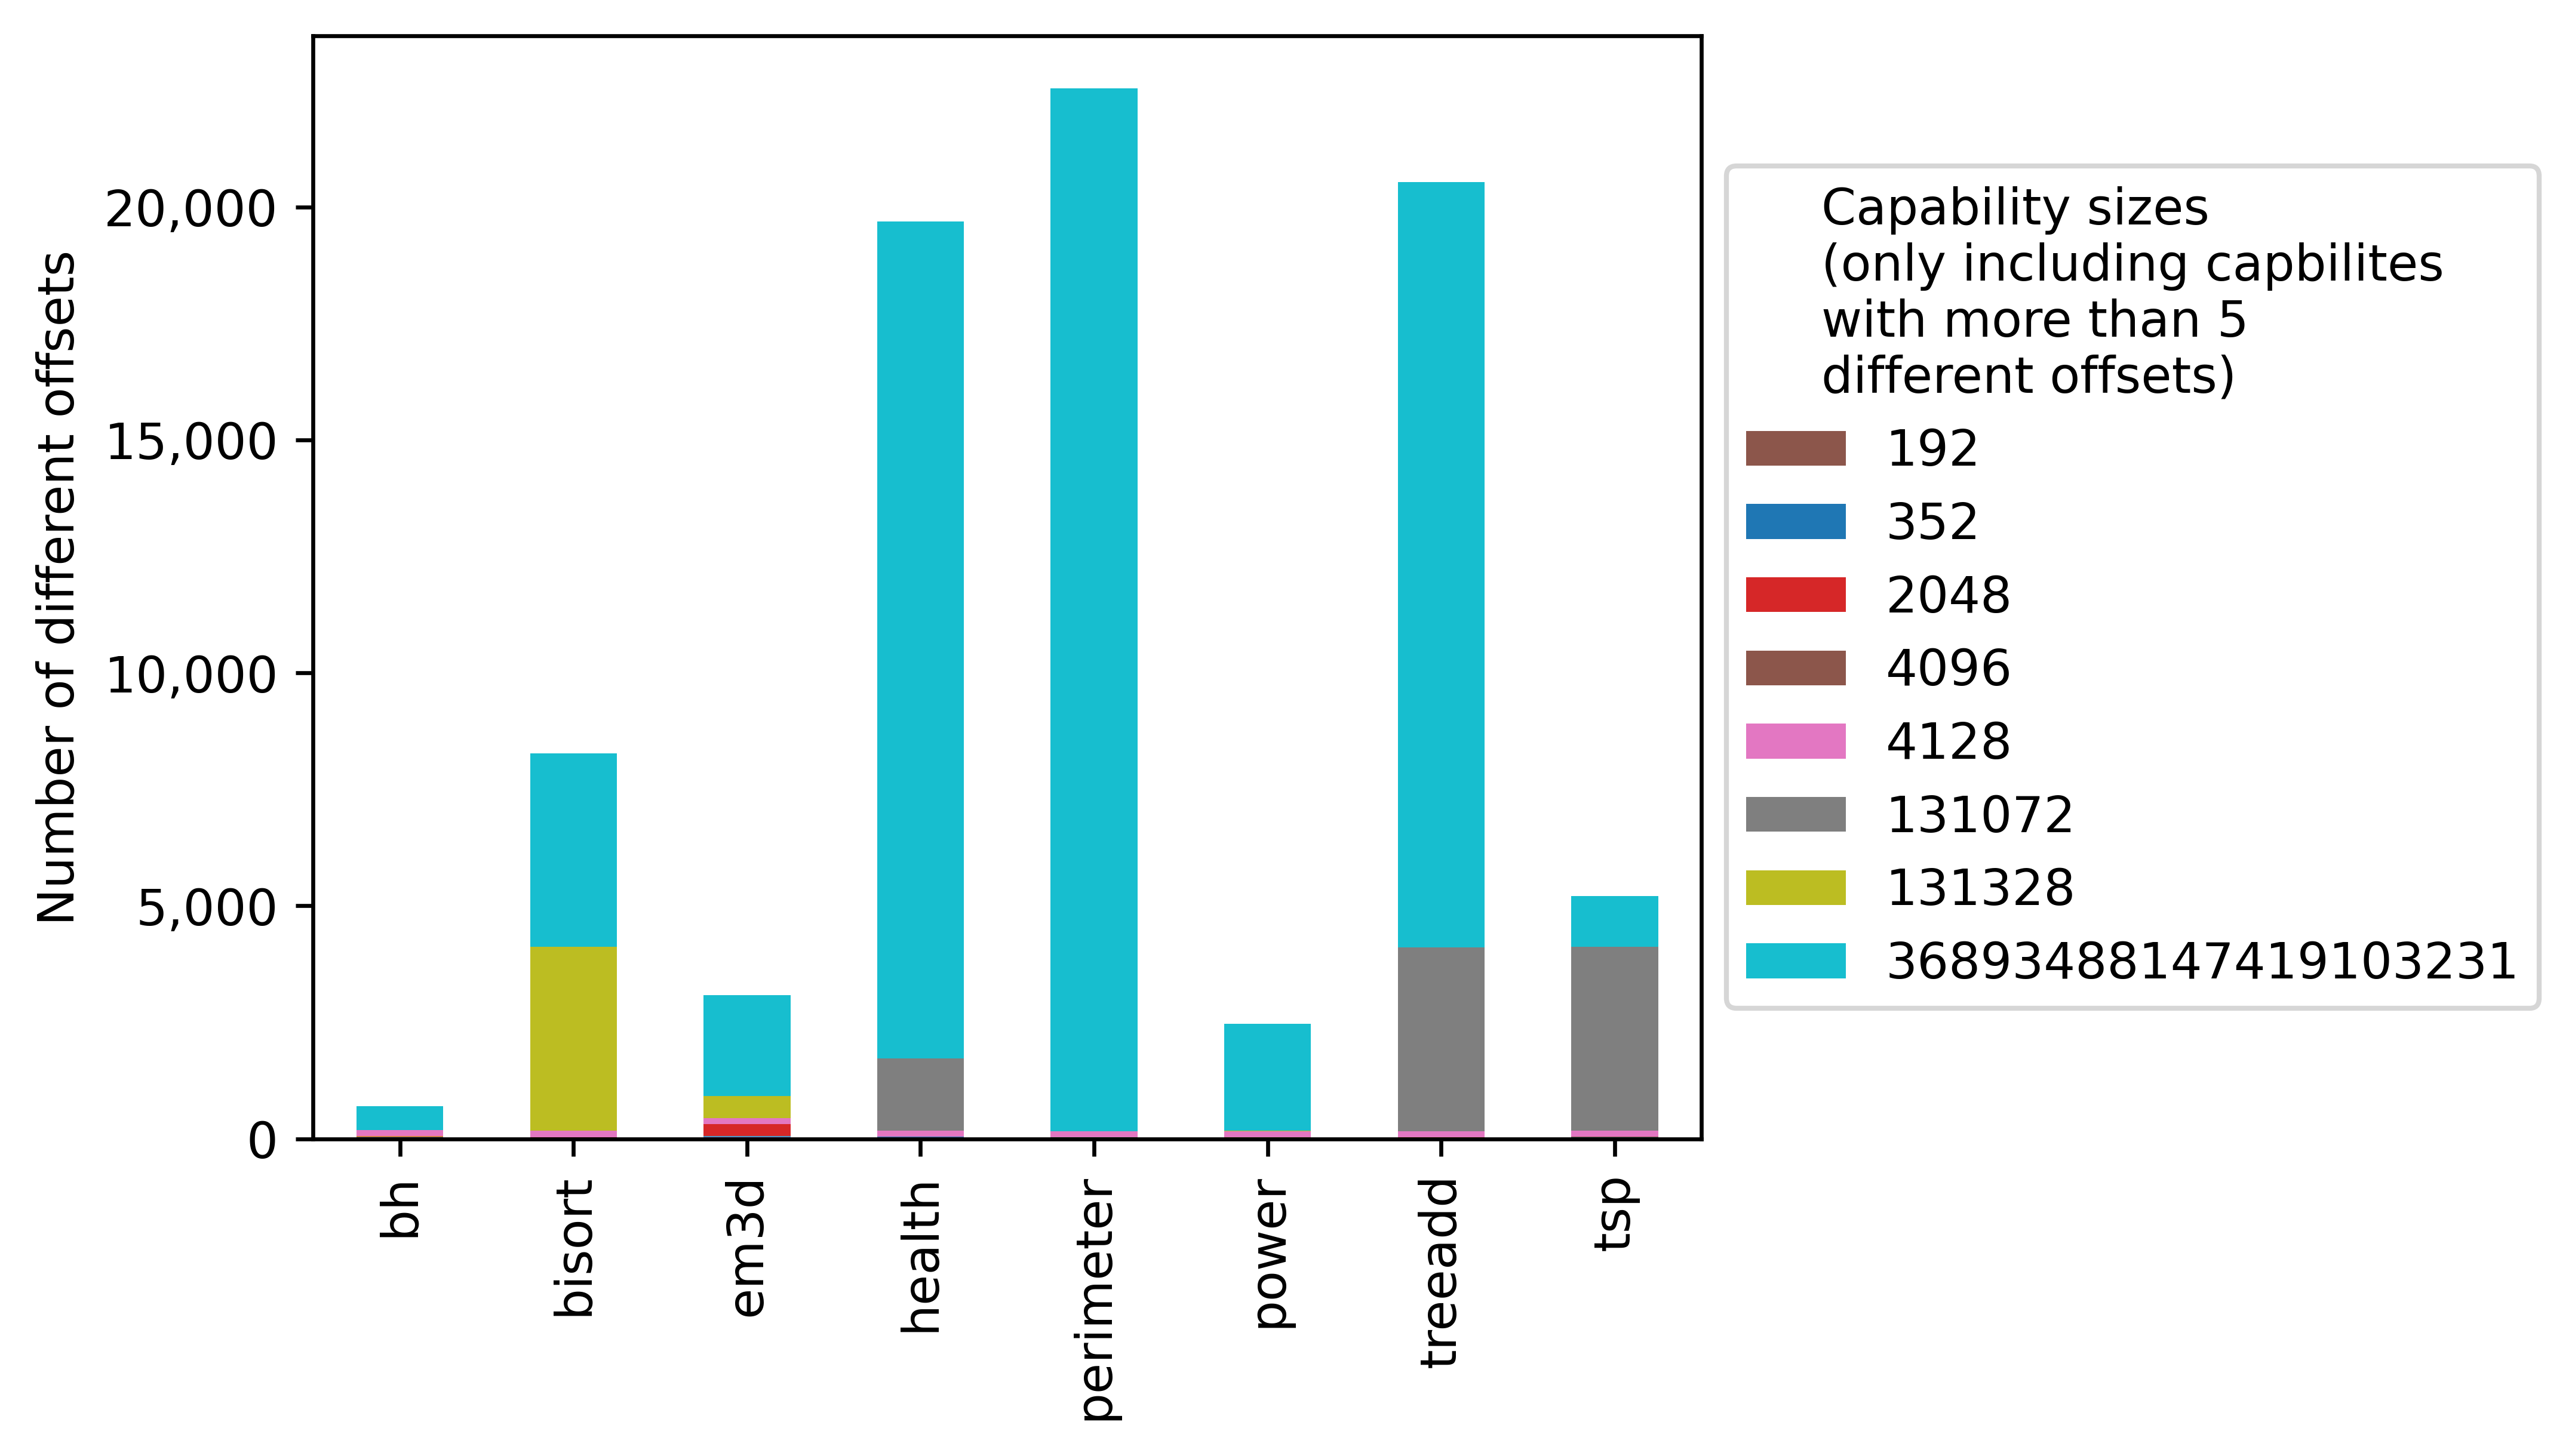

In [224]:
fig = plt.figure(figsize=(5,4), dpi=600)
ax = fig.gca()
ax = df.plot.bar(rot=0, title="", ylabel="Number of different offsets", ax=ax, stacked=True)
ax.get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
labels = [(col if col in df.columns[(df > 5).any()] else '_Hidden label') for col in df.columns]
ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 5\ndifferent offsets)", loc='center left', bbox_to_anchor=(1, 0.5))
ax.tick_params(axis='x', labelrotation=90)
fig.savefig("MotivationGraphs/OffsetsPerBoundSizes.pdf", bbox_inches='tight')


## MiBench

In [327]:
offsets_per_size_counter_results = {}
for benchmark in benchmark_name_mibench:
    offsets_per_size_counts = offset_cap_size(benchmark, bechmark_result_mibench)
    offsets_per_size_counter_results[benchmark] = offsets_per_size_counts

/local/scratch-3/tm746/tmp/ipykernel_1107831/833085494.py:9: UserWarning: The label '_Hidden label' of <BarContainer object of 5 artists> starts with '_'. It is thus excluded from the legend.
  ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 5\ndifferent offsets)", loc='center left', bbox_to_anchor=(1, 0.5))


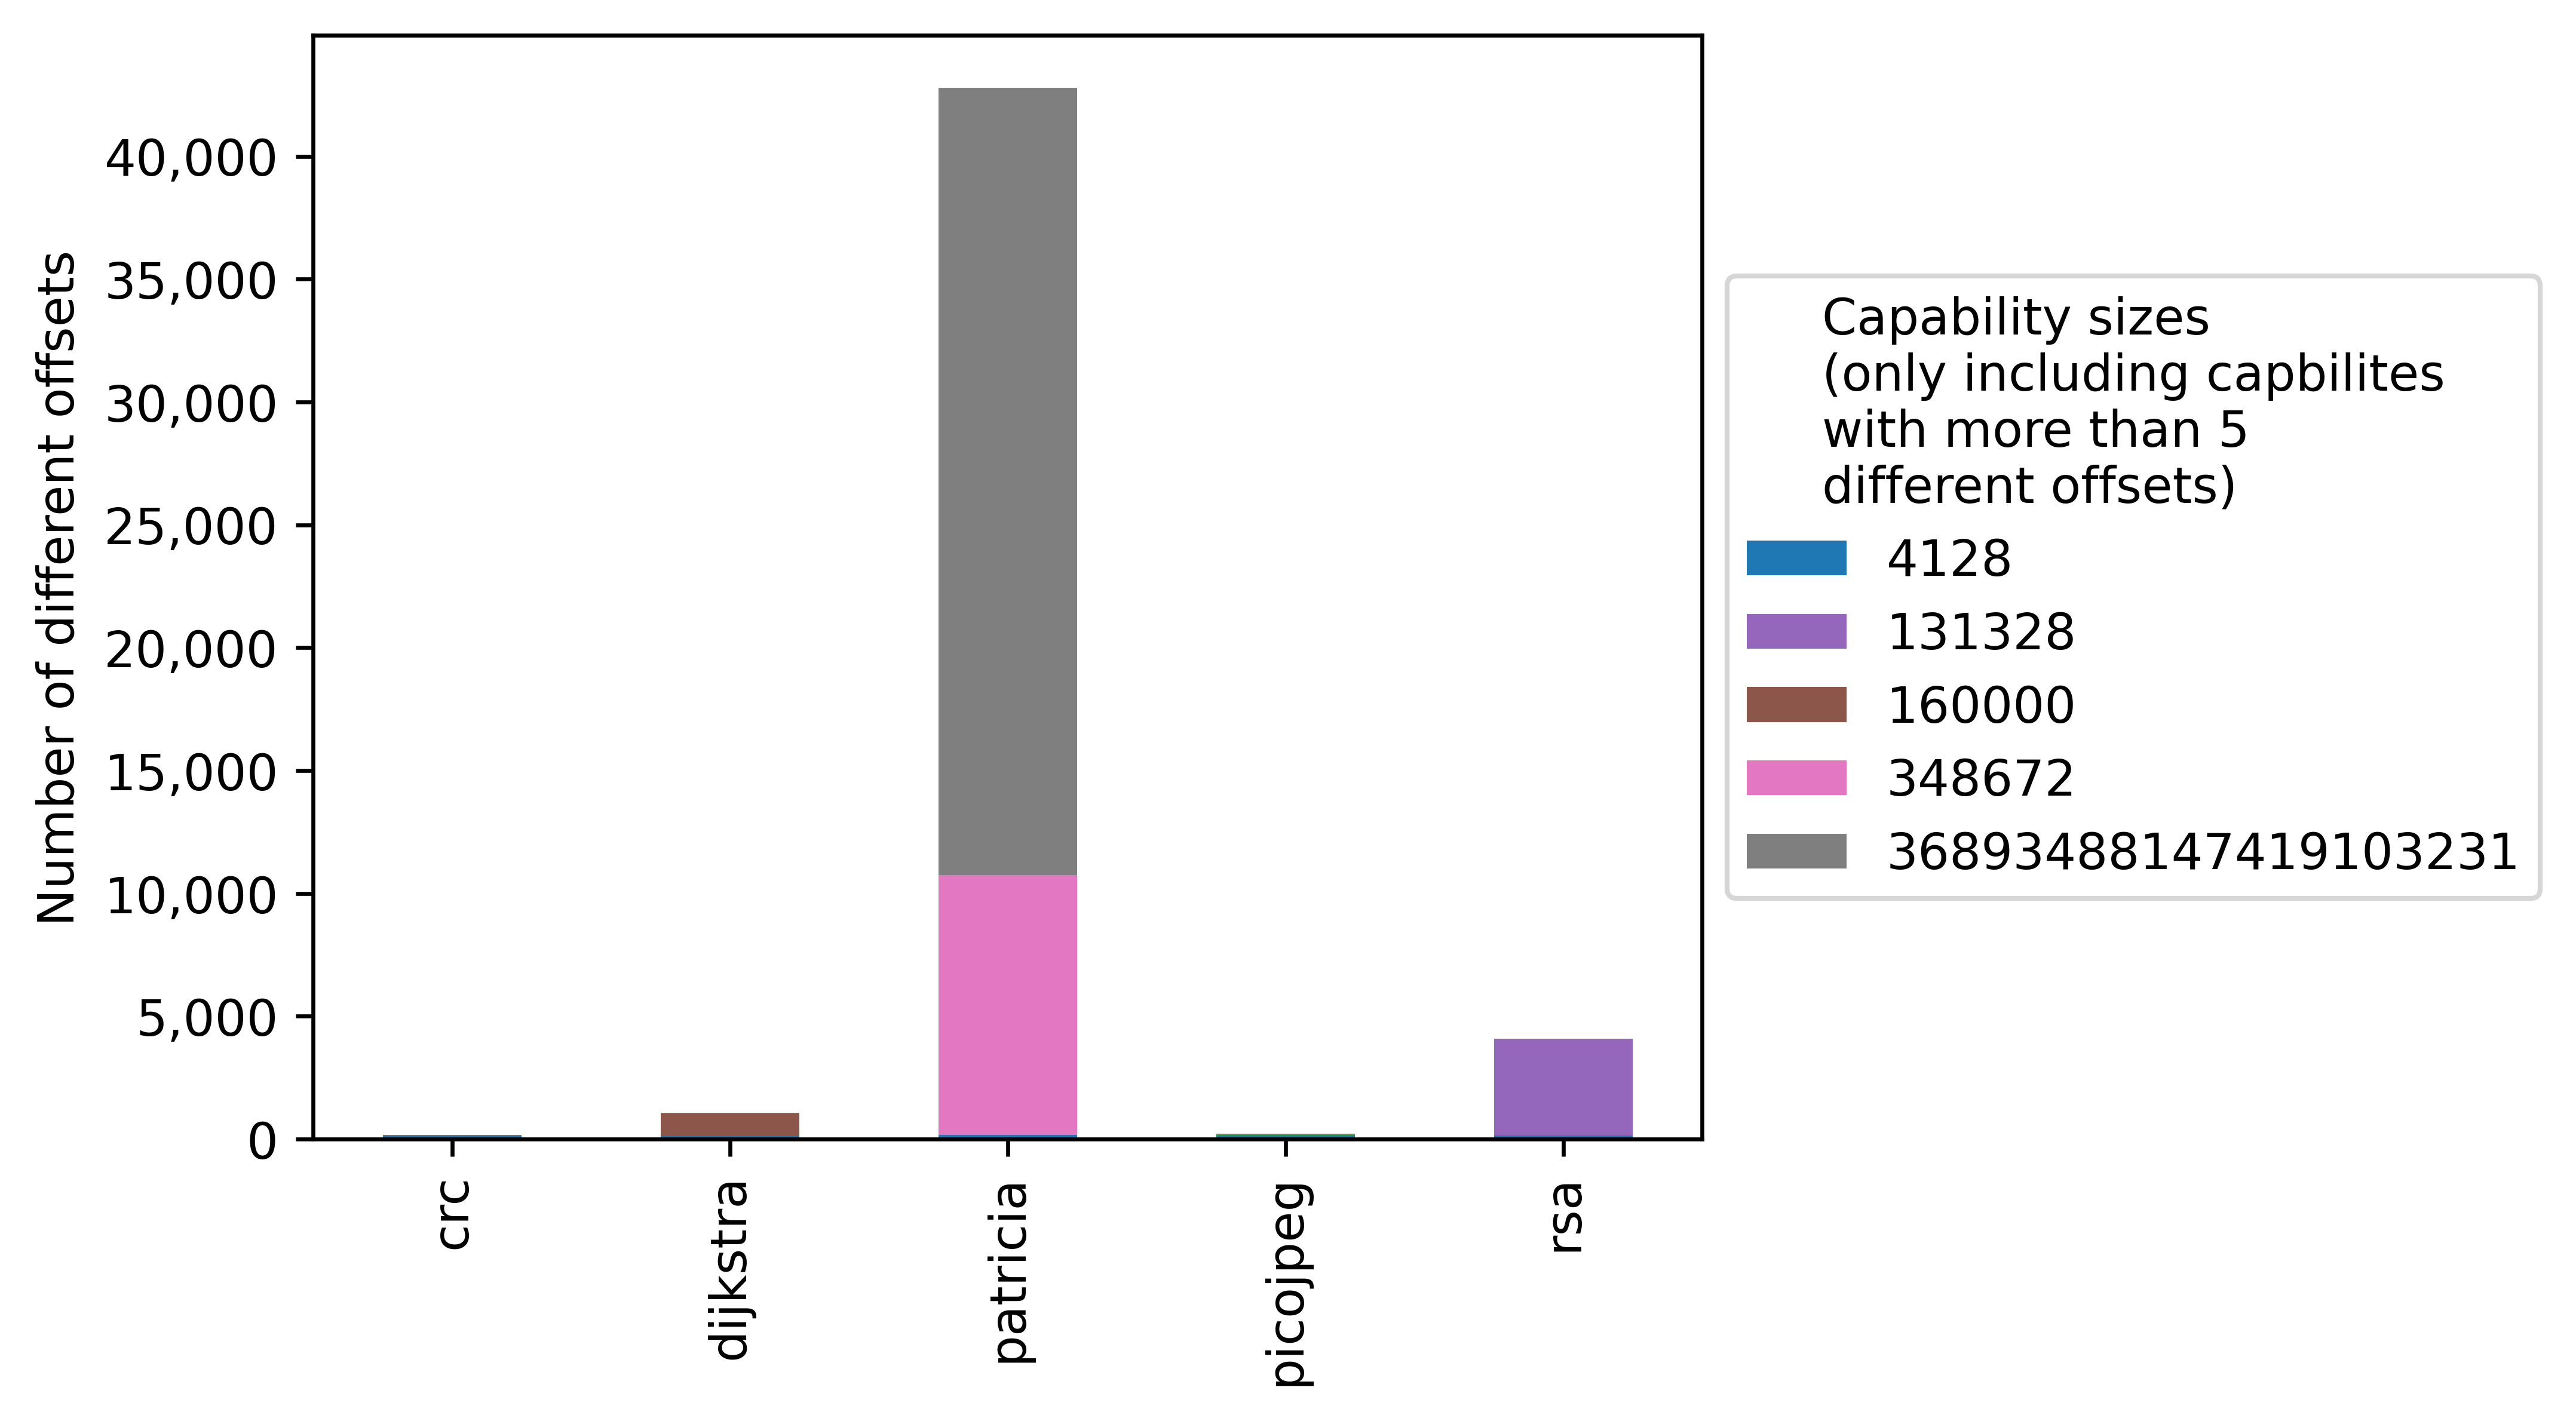

In [328]:
df = nested_dict_to_df(offsets_per_size_counter_results)
df
fig = plt.figure(figsize=(5,4), dpi=600)
ax = fig.gca()
ax = df.plot.bar(rot=0, title="", ylabel="Number of different offsets", ax=ax, stacked=True)
ax.get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
labels = [(col if col in df.columns[(df > 5).any()] else '_Hidden label') for col in df.columns]
ax.legend(labels=labels, title="Capability sizes\n(only including capbilites\nwith more than 5\ndifferent offsets)", loc='center left', bbox_to_anchor=(1, 0.5))
ax.tick_params(axis='x', labelrotation=90)
fig.savefig("MotivationGraphs/OffsetsPerBoundSizes.pdf", bbox_inches='tight')


# How frequently is the capability accessed at a offset is accessed at that offset later
What manipluations are made before accessing

In [762]:
def offset_modfication(name, benchmark_var):
    backwards = {}
    match = 0
    missmatch = 0

    for data_arrival in benchmark_var[name]["data_arrivals"]:
        if data_arrival.sel_capability:
            backwards[data_arrival.sel_capability.cap.capKey()] = data_arrival.sel_capability.cap.boundsOffset

        if data_arrival.requestCap.capKey() in backwards:
            if  backwards[data_arrival.requestCap.capKey()] == data_arrival.requestCap.boundsOffset:
                match += 1
            else: 
                missmatch += 1
            del backwards[data_arrival.requestCap.capKey()]
    return match, missmatch

In [763]:
offset_modification_results = {}
for benchmark in benchmark_names:
    match, missmatch = offset_modfication(benchmark, benchmark_results)
    offset_modification_results[benchmark] = match, missmatch

In [764]:
offset_modification_results

{'bh': (105039, 230487),
 'bisort': (396495, 108898),
 'em3d': (38320, 57474),
 'health': (128340, 295865),
 'perimeter': (181741, 176220),
 'power': (75021, 17975),
 'treeadd': (158500, 111830),
 'tsp': (106988, 146591)}

In [767]:
df = pd.DataFrame.from_dict(offset_modification_results, orient='index',
                       columns=['Match', "Miss Match"])
df = df.div(df.sum(axis=1), axis=0)
df
# plot_bar(df, "Number of distinct capability bound sizes", "Number of distinct capbility bound sizes", "BoundSizesAggMiBench")

,Match,Miss Match
bh,0.313058,0.686942
bisort,0.784528,0.215472
em3d,0.400025,0.599975
health,0.302542,0.697458
perimeter,0.507712,0.492288
power,0.806712,0.193288
treeadd,0.586320,0.413680
tsp,0.421912,0.578088


<Axes: ylabel='Proportion of offsets identical in parent'>

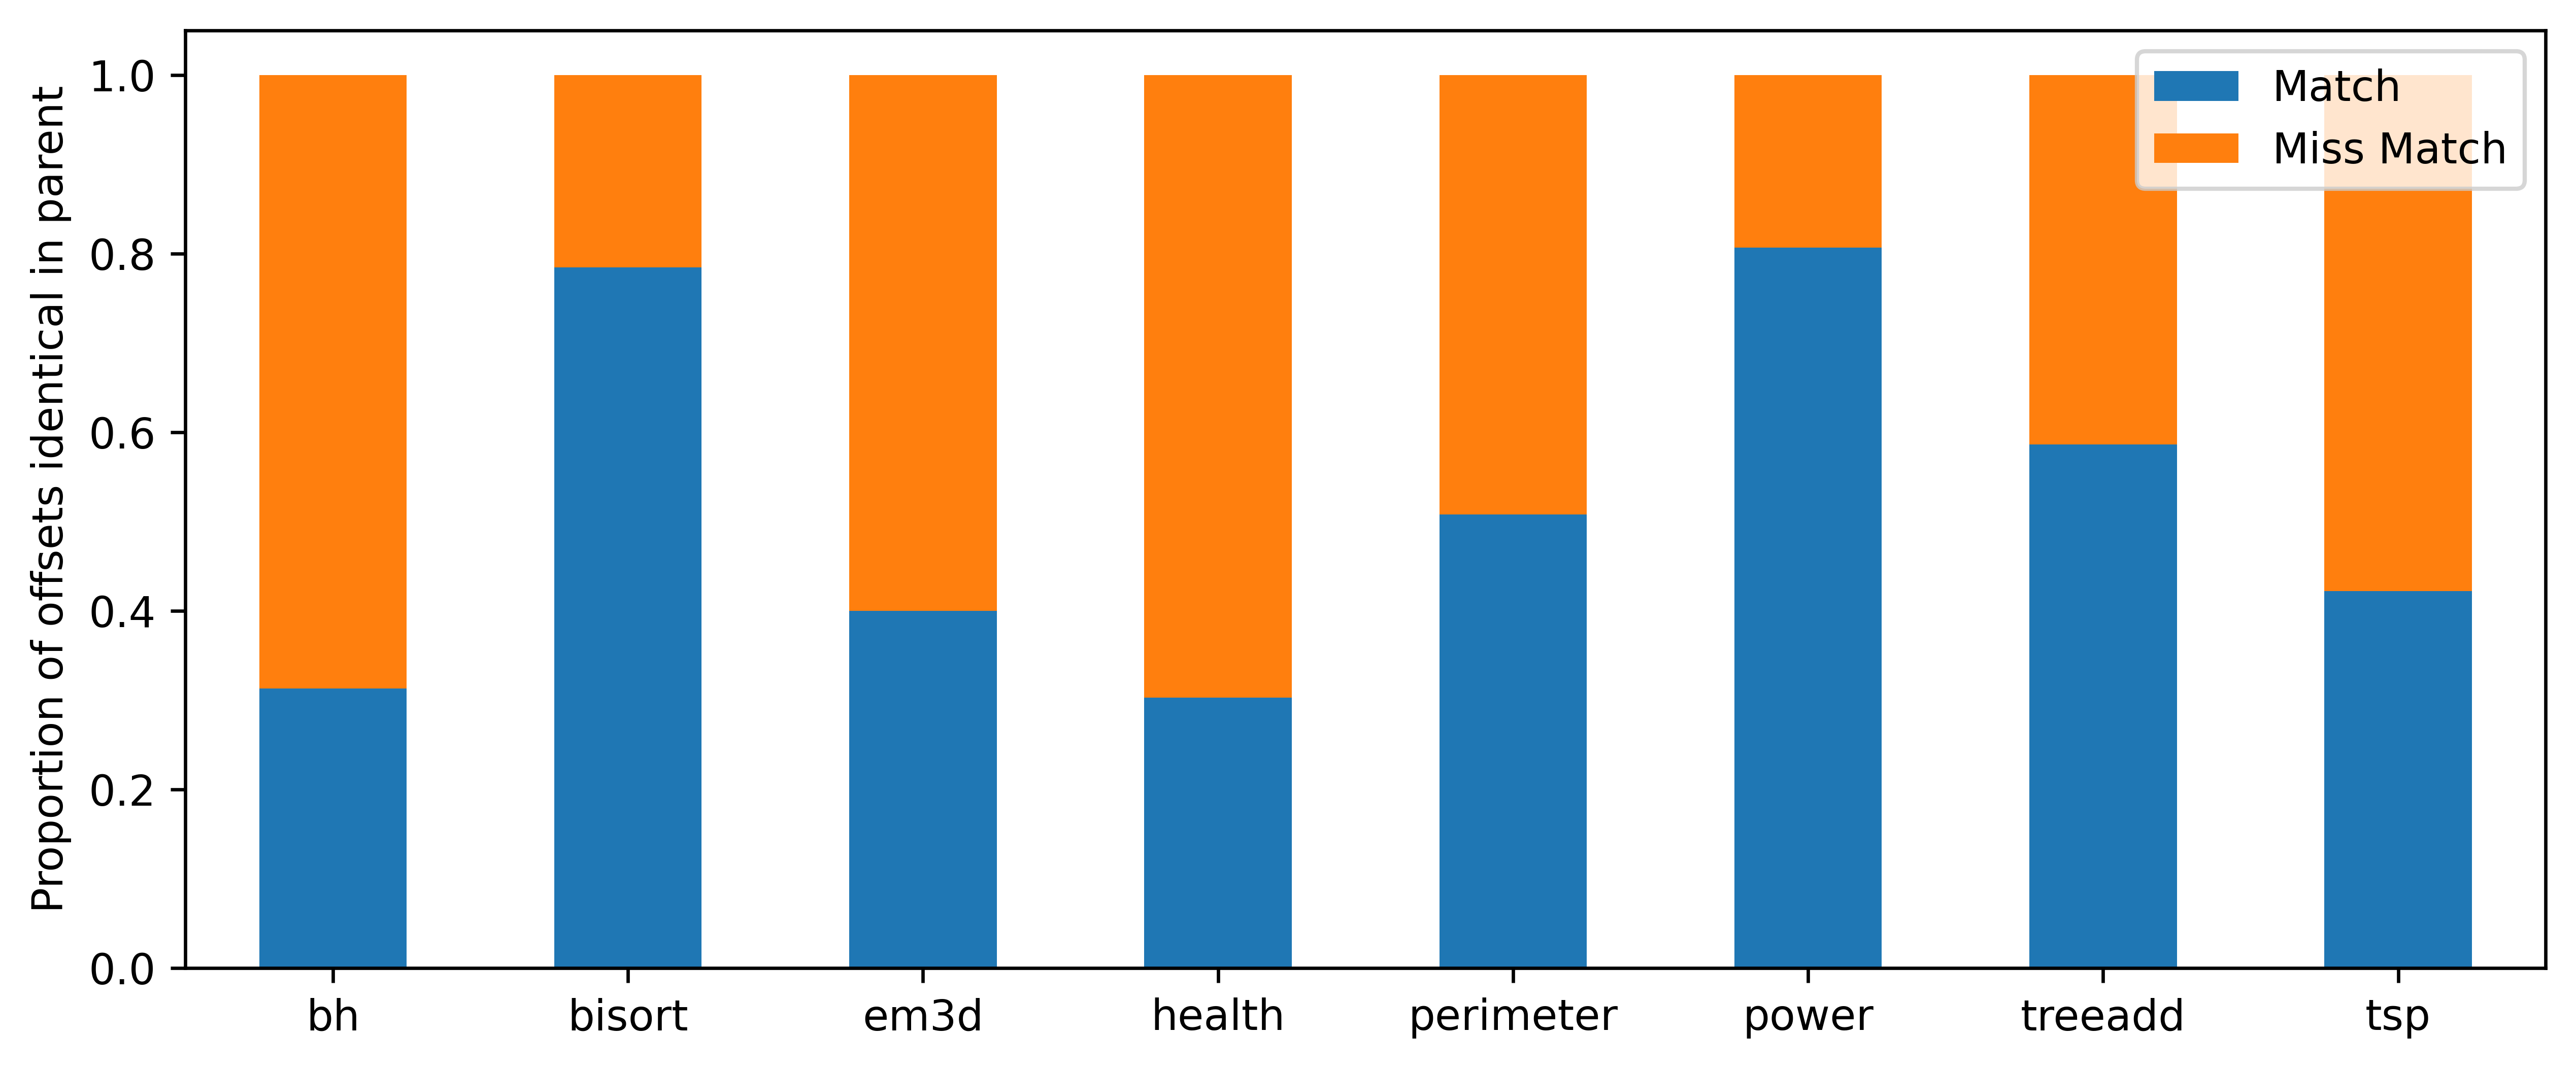

In [769]:
plot_bar(df, "Proportion of offsets identical in parent", "Proportion of offsets identical in parent", "OffsetMatchOlden", stacked=True, format_sci=False)

# MiBench

In [483]:
offset_modification_results = {}
for benchmark in benchmark_name_mibench:
    match, missmatch = offset_modfication(benchmark, bechmark_result_mibench)
    offset_modification_results[benchmark] = match, missmatch

In [484]:
df = pd.DataFrame.from_dict(offset_modification_results, orient='index',
                       columns=['Match', "Miss Match"])

df
# plot_bar(df, "Number of distinct capability bound sizes", "Number of distinct capbility bound sizes", "BoundSizesAggMiBench")

,Match,Miss Match
dijkstra,58379,771265
crc,1726,221678
patricia,200238,295928
picojpeg,431843,208640
rsa,96602,28704


In [487]:
df = df.div(df.sum(axis=1), axis=0)

<Axes: ylabel='Number of distinct capbility bound sizes'>

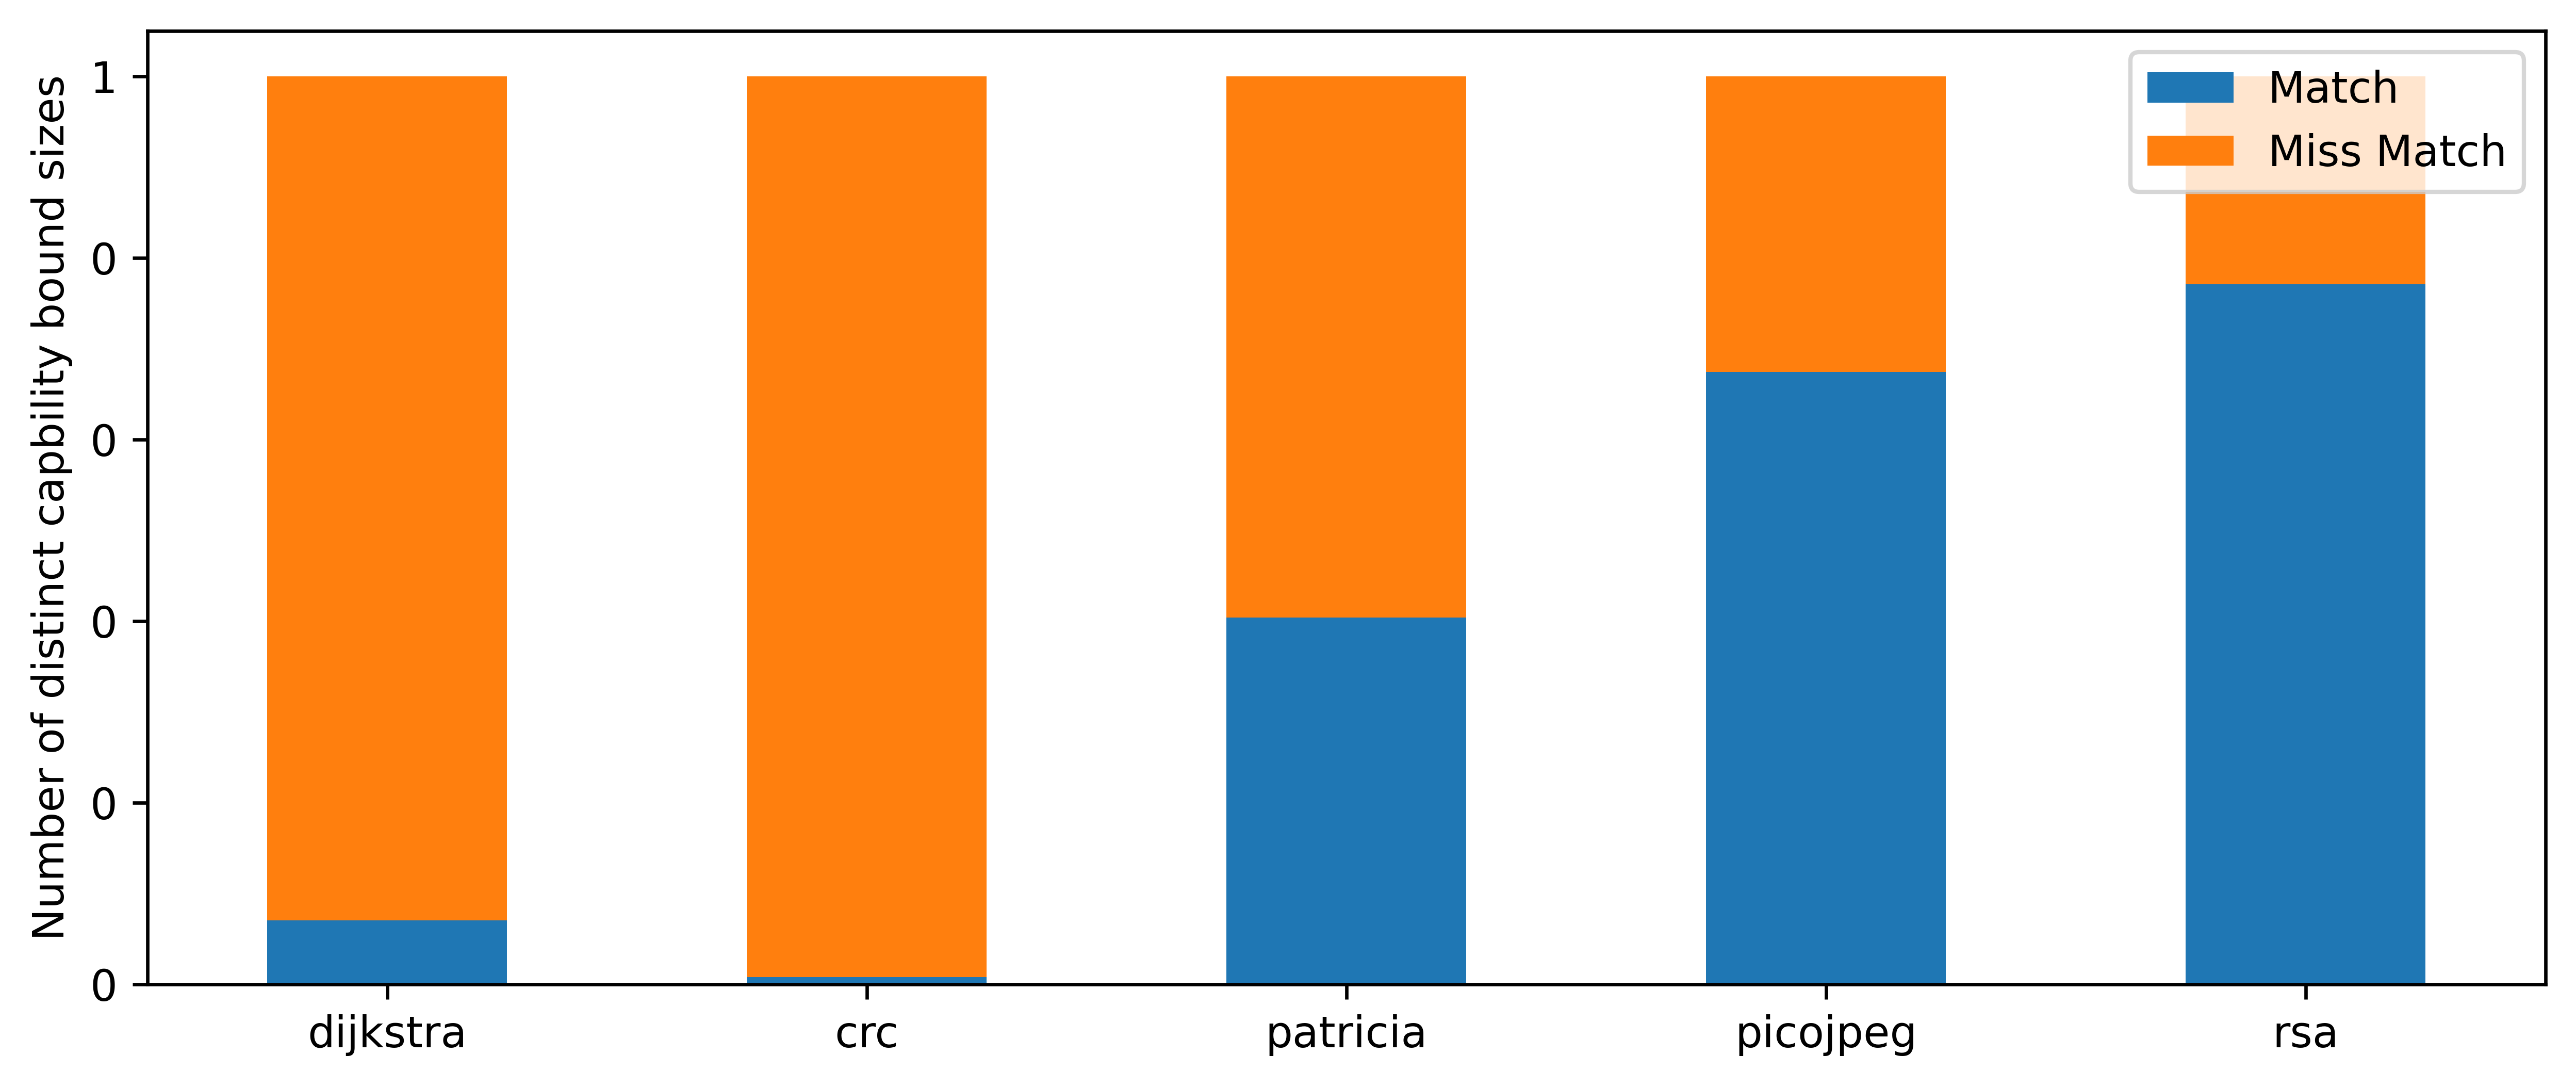

In [488]:
plot_bar(df, "Number of distinct capability bound sizes", "Number of distinct capbility bound sizes", "BoundSizesAggMiBench", stacked=True)

# What proporition of misses are between capabilites vs within a capability?

In [ ]:
benchmark_results[name]["data_arrivals"]

In [301]:
def prop_between_vs_in(name):
    cap_select = {}
    cap_seen = {}
    between_counter = 0
    in_counter = 0

    cap_seen[(0, 18446744073709551615)] = 0
    cap_select[(0, 18446744073709551615)] = 0
    for data_arrival in benchmark_results[name]["data_arrivals"]:
        if data_arrival.sel_capability:
            #print("adding")
            cap_select[data_arrival.sel_capability.cap.capKey()] = data_arrival.clock_time
        # if data_arrival.wasMiss:
        if data_arrival.requestCap.capKey() in cap_seen:
            if data_arrival.requestCap.capKey() in cap_select:
                if cap_seen[data_arrival.requestCap.capKey()] > cap_select[data_arrival.requestCap.capKey()]:
                    if data_arrival.wasMiss:
                        in_counter += 1
                else:
                    if data_arrival.wasMiss:
                        between_counter += 1
                    cap_seen[data_arrival.requestCap.capKey()] = data_arrival.clock_time
            # else:
            #     print("here")
        else:
            if data_arrival.requestCap.capKey() in cap_select:
                cap_seen[data_arrival.requestCap.capKey()] = data_arrival.clock_time
                if data_arrival.wasMiss:
                    between_counter += 1
            else:
                cap_seen[data_arrival.requestCap.capKey()] = data_arrival.clock_time
                #pass
                #print(data_arrival.requestCap.capKey())

    # print(cap_select)
    return between_counter, in_counter
        

In [302]:
prop_between_vs_in("health")

(162908, 177248)

In [303]:
443162/3601024

0.1230655502434863

In [304]:
prop_results = {}
for benchmark in benchmark_names:
    between_counter, in_counter = prop_between_vs_in(benchmark)
    prop_results[benchmark] = [between_counter, in_counter]

In [306]:
df = pd.DataFrame.from_dict(prop_results, orient='index',
                       columns=['Between', 'In'])
df

,Between,In
bh,86317,100508
bisort,97624,35524
em3d,22285,17794
health,162908,177248
perimeter,83778,114061
power,21002,19920
treeadd,35375,42078
tsp,50789,63525


In [765]:
df = pd.DataFrame.from_dict(prop_results, orient='index',
                       columns=['Between)', 'In'])
df

,Between),In
bh,86317,100508
bisort,97624,35524
em3d,22285,17794
health,162908,177248
perimeter,83778,114061
power,21002,19920
treeadd,35375,42078
tsp,50789,63525


<Axes: ylabel='Number of misses'>

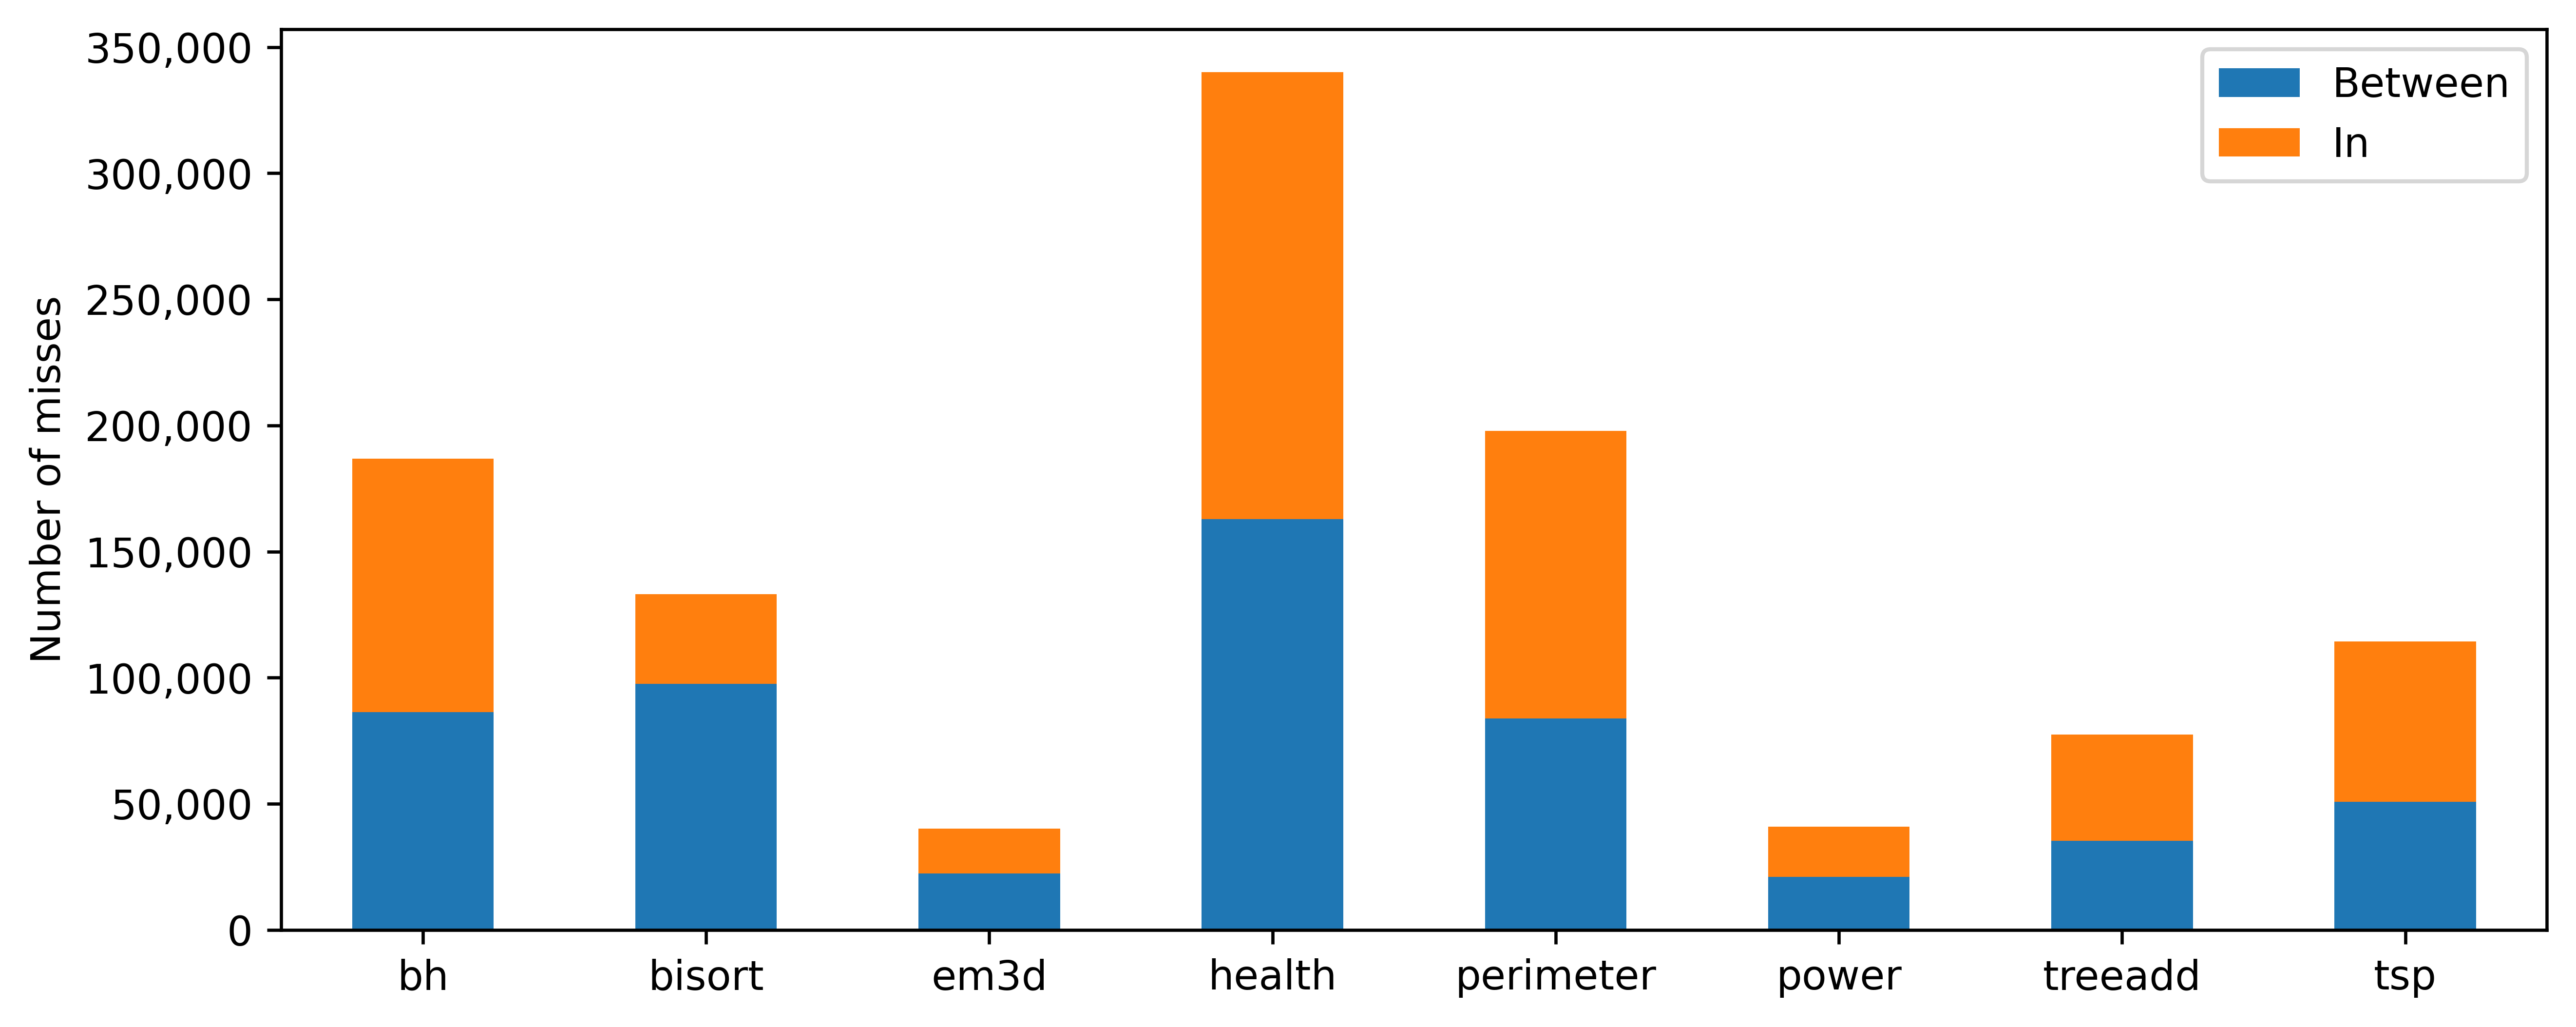

In [307]:
plot_bar(df, "Comparision of CHERI validity tag vs estimation of pointer for classification of values", "Number of misses", "ProportionOfMissesBetween", stacked=True)

# Capability offset correlation

In [502]:
def capability_offset_correlation(name, benchmark_var):
    bound_sizes_counter = defaultdict(lambda: defaultdict(int))
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        if data_arrival.requestCap.boundsLength <= 4096:
            bound_sizes_counter[data_arrival.requestCap.boundsLength][data_arrival.requestCap.boundsOffset] += 1
    
    return bound_sizes_counter
    

In [503]:
capability_offset_correlation_results = {}
for benchmark in benchmark_names:
    capability_offset_correlation_result = capability_offset_correlation(benchmark, benchmark_results)
    capability_offset_correlation_results[benchmark] = capability_offset_correlation_result

344


array([   4,    8,   12,   13,   16,   17,   21,   22,   23,   27,   31,
         32,   37,   40,   45,   48,   49,   52,   64,   66,   80,  352,
       4096])

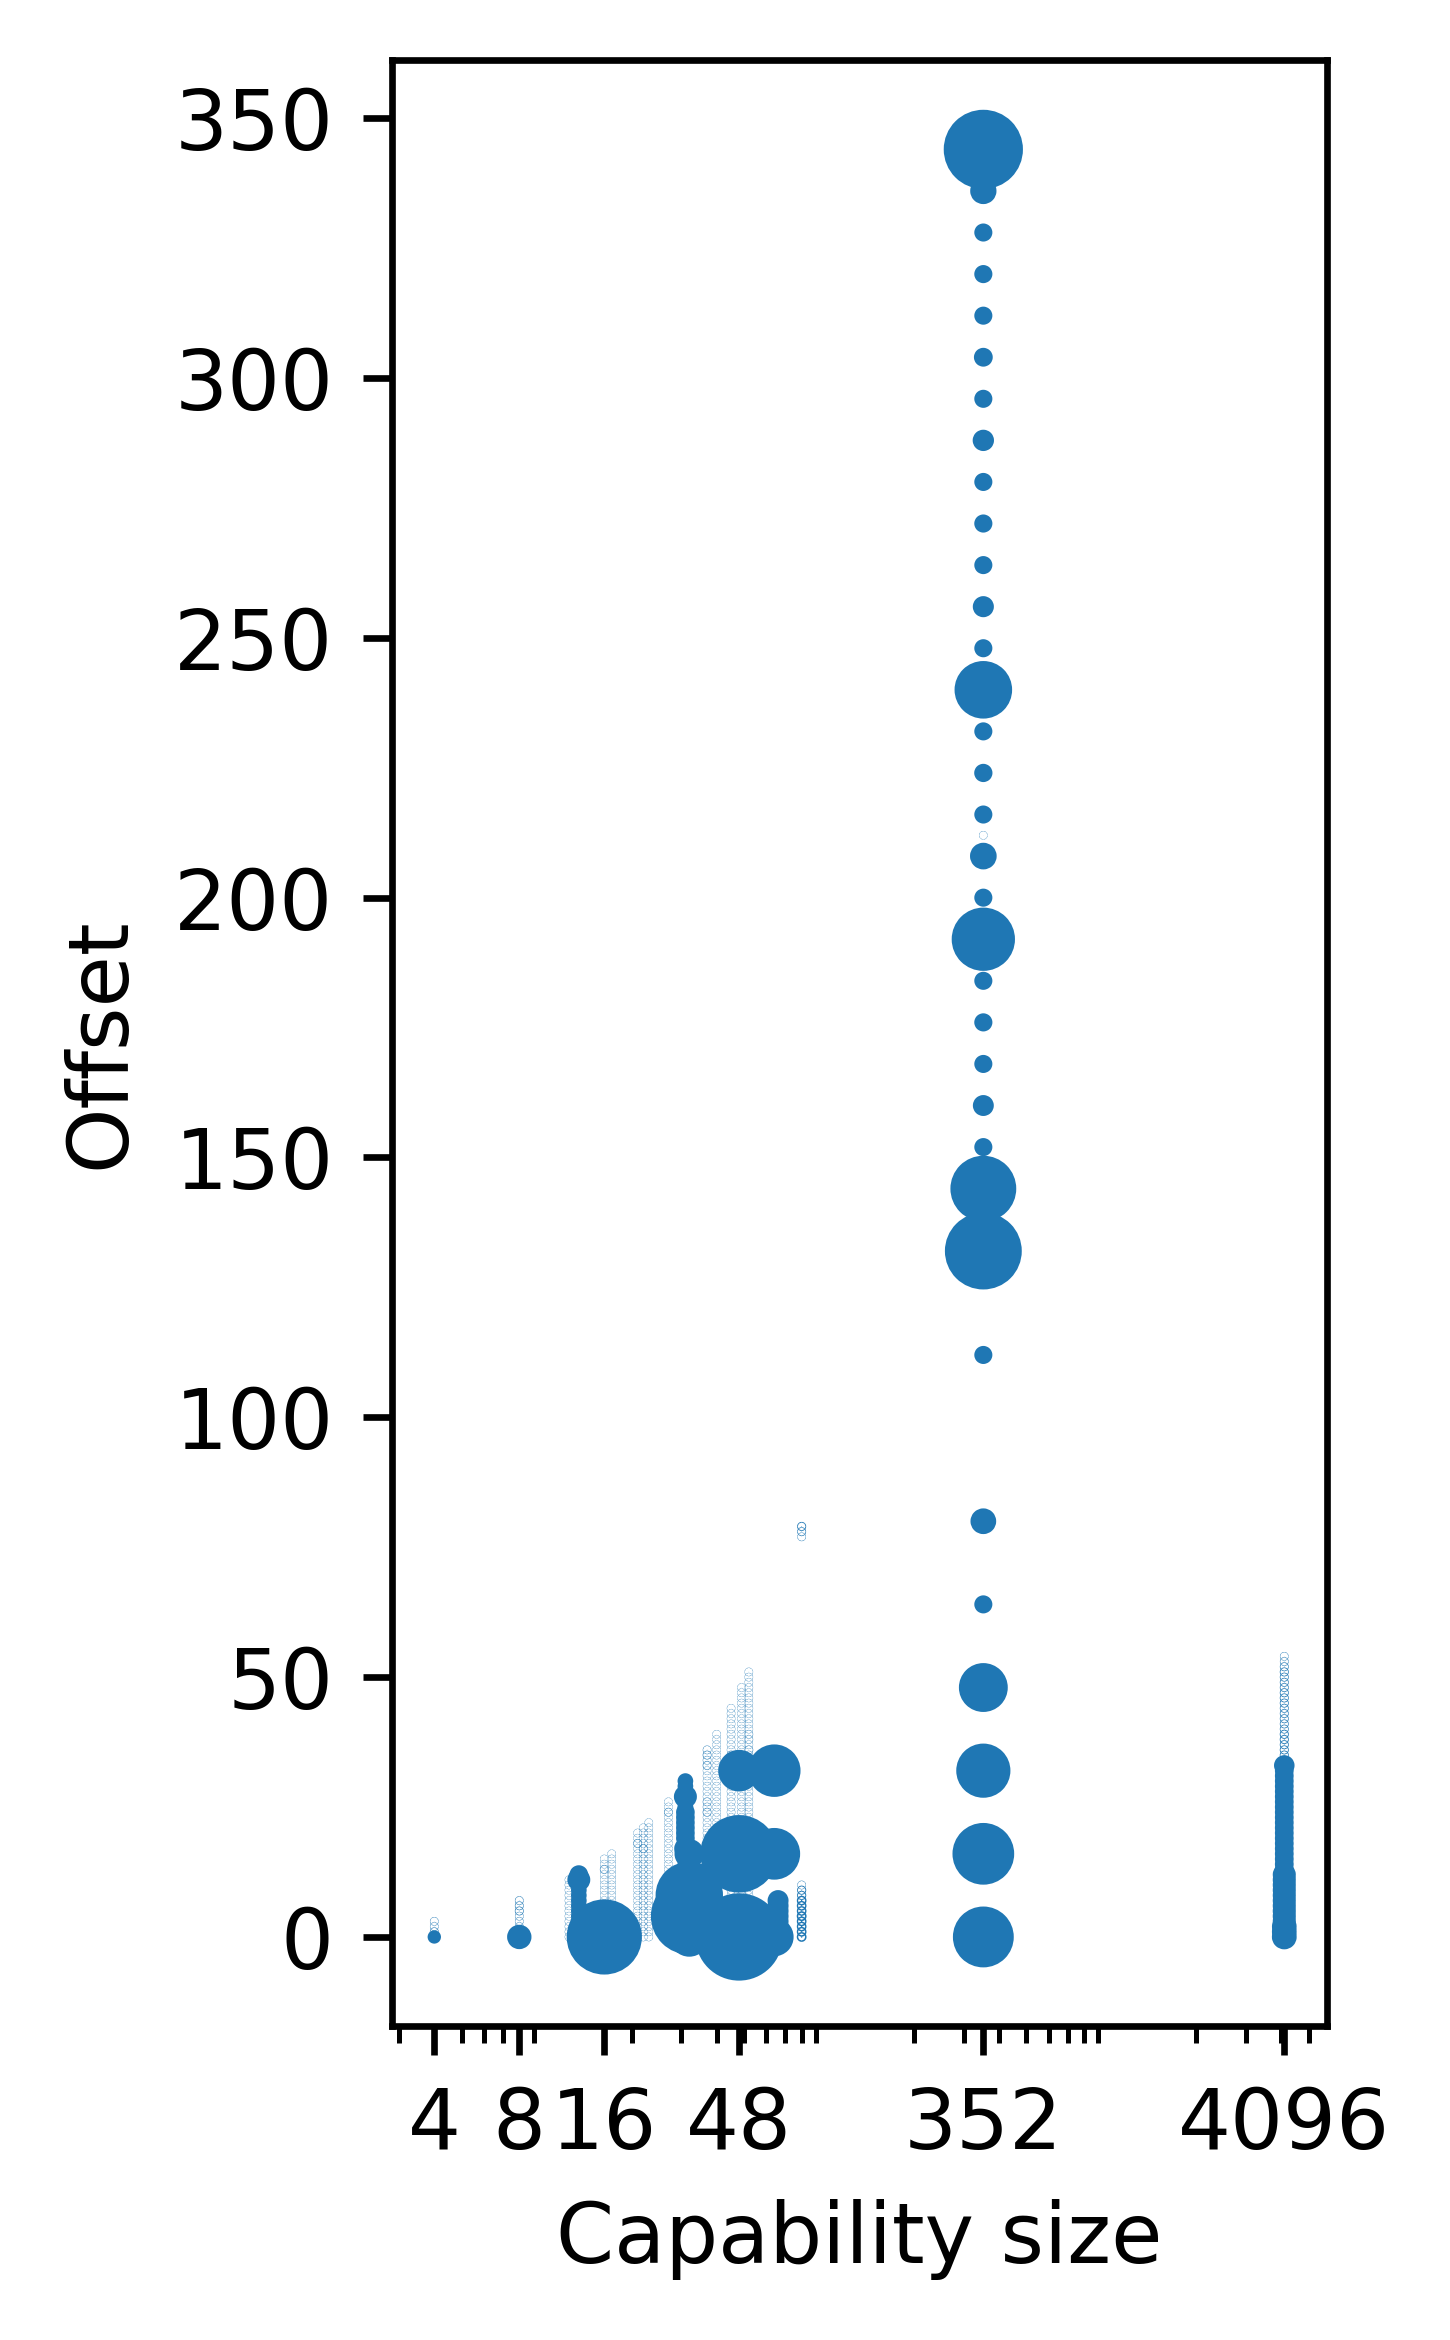

In [1276]:
def flatten_offset_correlation(d):
    points = []
    sizes = []
    max_offset = 0
    for correlator, offsets in d.items():
        for offset, count in offsets.items():
            points.append((correlator, offset))
            sizes.append(count/1000)
            if offset > max_offset:
                max_offset = offset
    print(max_offset)
    return points, sizes
corr_points, corr_sizes = flatten_offset_correlation(capability_offset_correlation_results["health"])

fig = plt.figure(figsize=(2.5,4), dpi=600)
ax = fig.gca()
ax.scatter(*zip(*corr_points), s=corr_sizes)
ax.set_xscale('log')
ax.set_xticks([4,8,16,48,352,4096])
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_ylabel("Offset")
ax.set_xlabel("Capability size")
# # ax.get_yaxis().set_major_formatter(
#     matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
fig.tight_layout()
fig.savefig("MotivationGraphs/capCorrHealth.pdf", bbox_inches='tight')

np.unique(list(zip(*corr_points))[0])

# Correlation from parent cap size

In [1032]:
def corr_parent_cap_size(name, benchmark_var):
    backwards = {}
    bound_sizes_counter = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))


    for data_arrival in benchmark_var[name]["data_arrivals"]:
        if data_arrival.sel_capability:
            backwards[data_arrival.sel_capability.cap.capKey()] = data_arrival.pcHash

        if data_arrival.requestCap.capKey() in backwards and data_arrival.requestCap.boundsLength <= 4096:
            bound_sizes_counter[backwards[data_arrival.requestCap.capKey()]][data_arrival.requestCap.boundsOffset][data_arrival.requestCap.boundsLength] += 1

    return bound_sizes_counter

In [1003]:
pc_offset_correlation_parent_results = {}
for benchmark in benchmark_names:
    pc_offset_correlation_parent_result = corr_parent_cap_size(benchmark, benchmark_results)
    pc_offset_correlation_parent_results[benchmark] = pc_offset_correlation_parent_result

In [1004]:
import distinctipy

In [1005]:
distinctipy.get_colors(22)

[(0.0, 1.0, 0.0),
 (1.0, 0.0, 1.0),
 (0.0, 0.5, 1.0),
 (1.0, 0.5, 0.0),
 (0.5, 0.75, 0.5),
 (0.33344535441935885, 0.017889965771295868, 0.6502557350623055),
 (0.8288091768795649, 3.088476862123102e-05, 0.041304496890808395),
 (0.32319324763141166, 0.4556561918349644, 0.012161682472500823),
 (0.0, 1.0, 1.0),
 (1.0, 1.0, 0.0),
 (1.0, 0.5, 1.0),
 (0.7035216740587052, 0.33357042344997545, 0.4556818647858909),
 (0.0, 1.0, 0.5),
 (0.0, 0.5, 0.5),
 (0.5294571767684216, 0.4390397864324198, 0.9988755471660699),
 (0.9920946072625199, 0.7462289679491477, 0.5221155264922225),
 (0.5278497843325313, 0.9947814474660905, 0.9224828837089839),
 (0.0, 0.0, 1.0),
 (0.5095375750713779, 0.9125720700481155, 0.042856902746781),
 (1.0, 0.0, 0.5),
 (0.4397837080087319, 0.12638843787952259, 0.12523552390951664),
 (0.6115132955808095, 0.06904770945176086, 0.9568711728361109)]

344


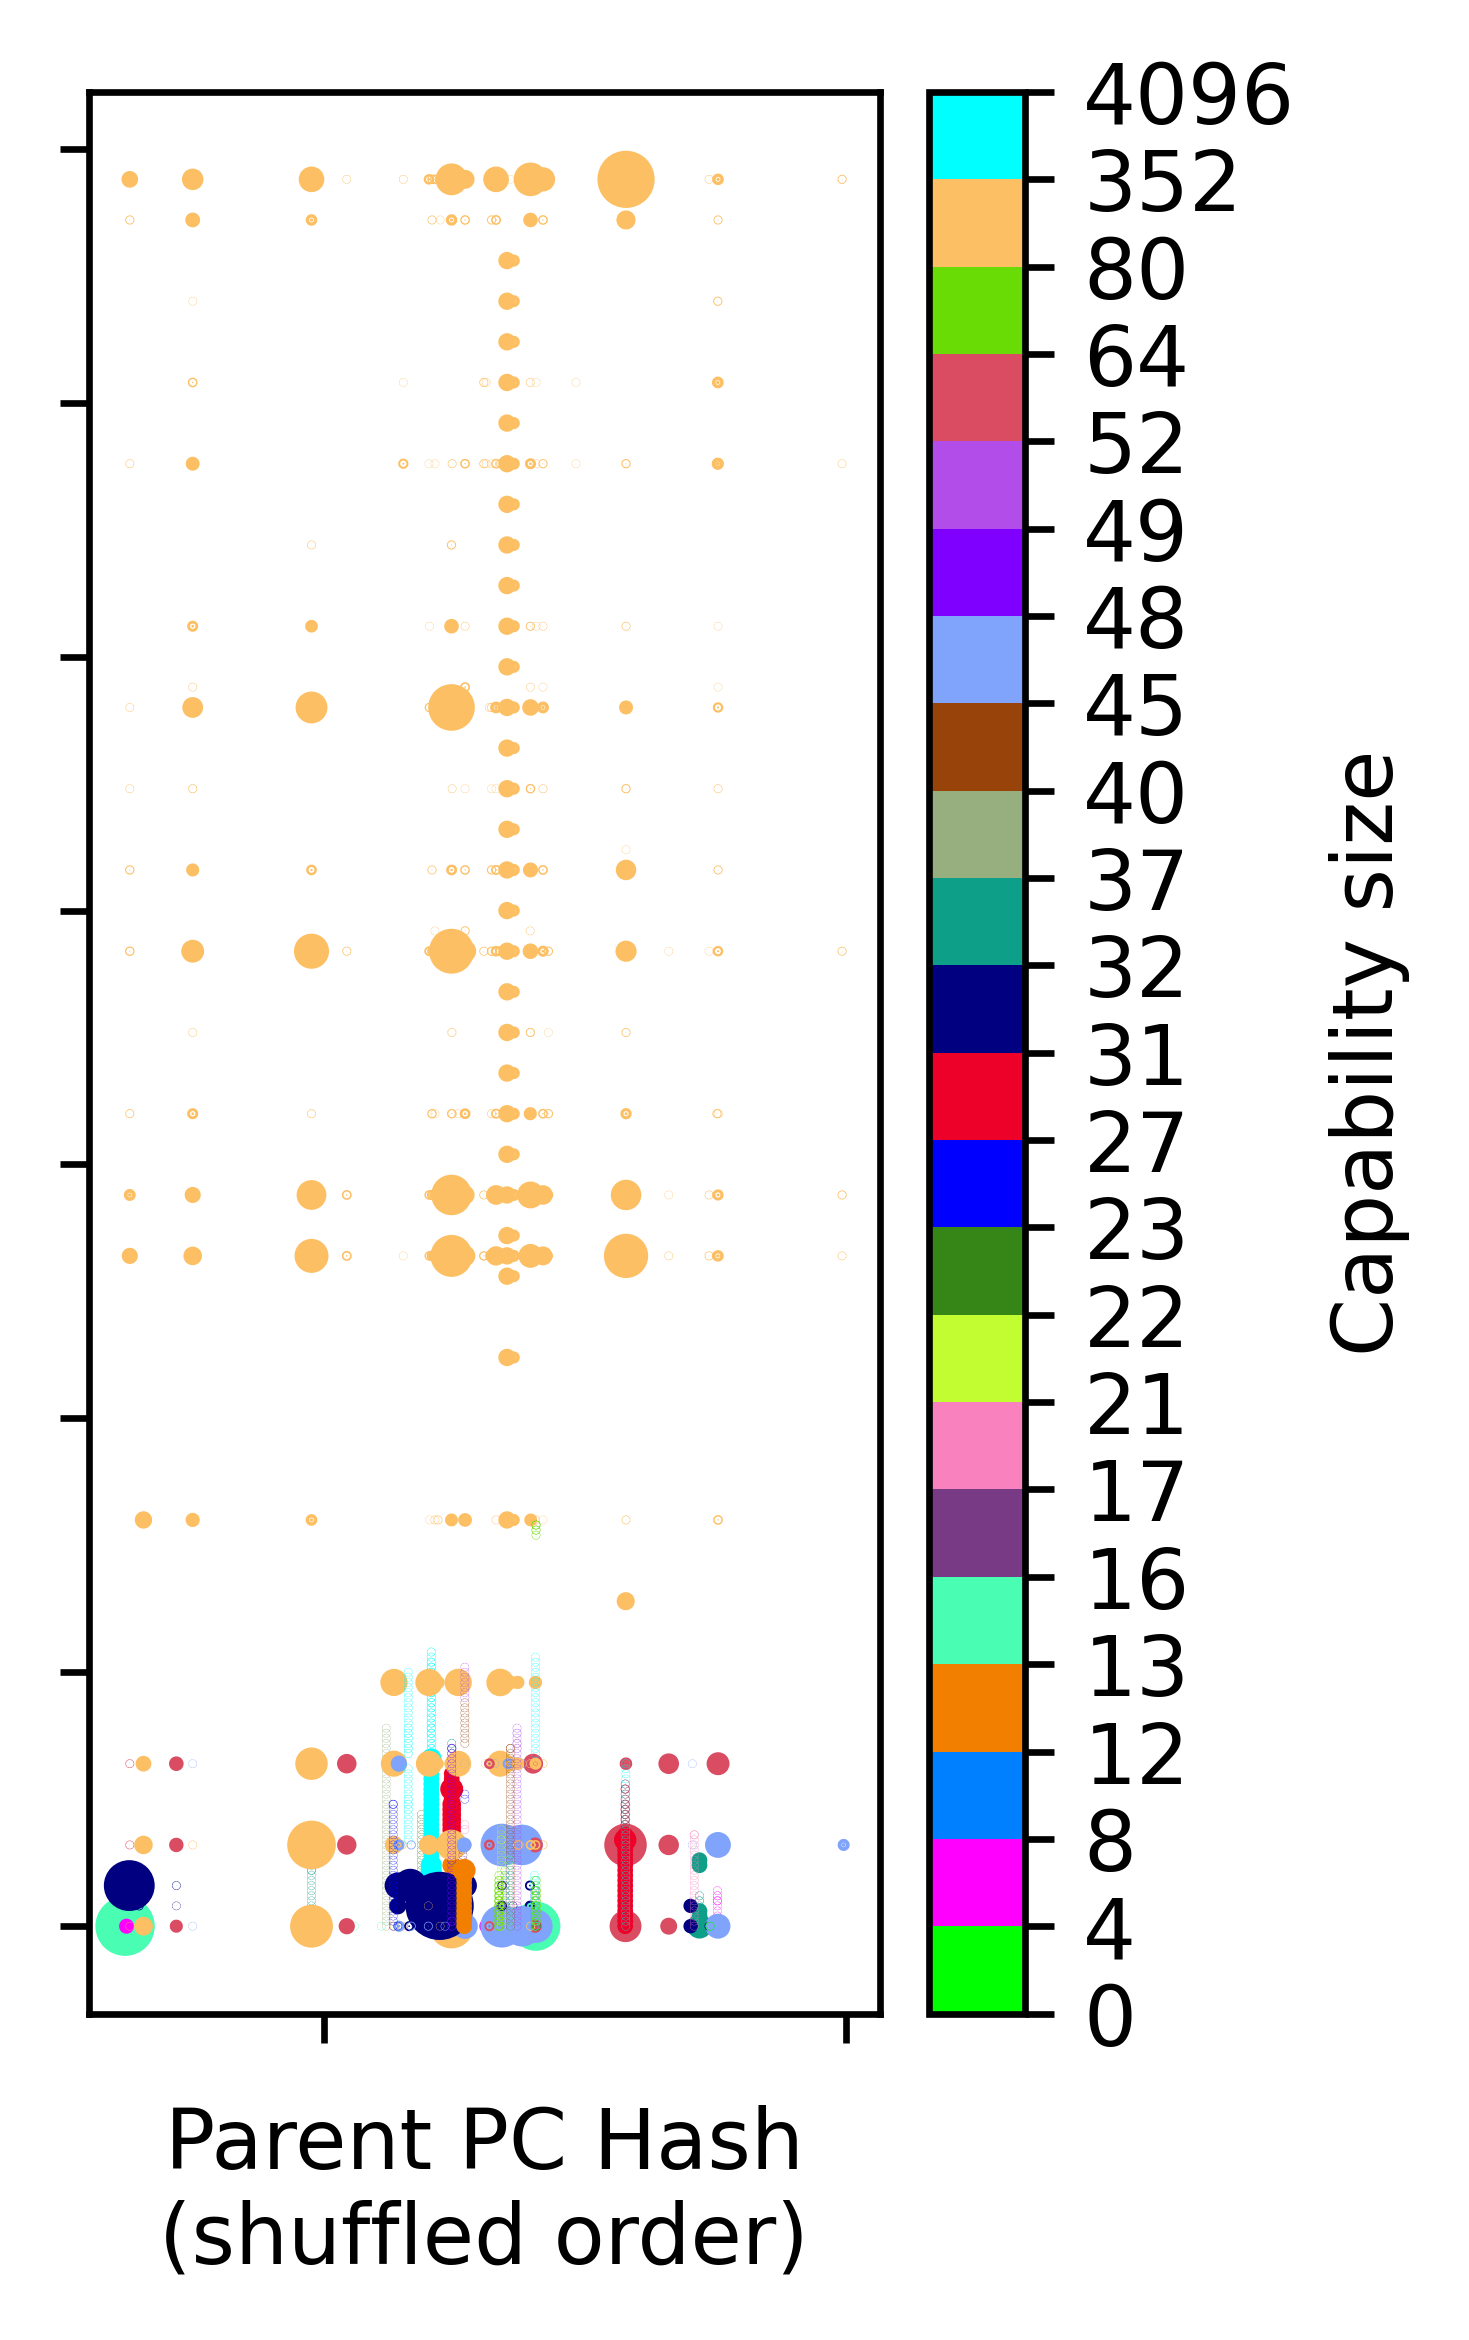

In [1278]:
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
def flatten_offset_correlation_pc(d):
    points = []
    sizes = []
    colors = []

    max_offset = 0
    for correlator, offsets in d.items():
        for offset, countSize in offsets.items():
            max_count = 0
            max_cap_size = 0 
            total_count = 0
            for size, count in countSize.items():
                total_count += count
                # print(f"count {count} max_count {max_count}")
                if count > max_count:
                    max_count = count
                    max_cap_size = size
                    # print(f"updating correlator {correlator} offset {offset} maxcount {max_count} {size}")

            points.append((correlator, offset))
            sizes.append(count/1000)
            colors.append(max_cap_size)
            if offset > max_offset:
                max_offset = offset
    print(max_offset)

    original = list(d.keys())
    np.random.seed(0)
    perm = np.random.permutation(original)
    perm_dict = {original[i]: perm[i] for i in range(len(original))}
    
    points = [(perm_dict[x], y) for x,y in points]  

    return points, sizes, colors
corr_points, corr_sizes, corr_colors = flatten_offset_correlation_pc(pc_offset_correlation_parent_results["health"])

fig = plt.figure(figsize=(2.5,4), dpi=600)
ax = fig.gca()

# define the bins and normalize
cmap = ListedColormap(distinctipy.get_colors(22))
bounds = np.unique(corr_colors)
norm = mpl.colors.BoundaryNorm([0] + list(bounds+1), cmap.N)

x, y = list(zip(*corr_points))
fake_x = range(len(x))
scatter = ax.scatter(x, y, s=corr_sizes, c=corr_colors, cmap=cmap, norm=norm)
# ax2 = fig.add_axes([0.95, 0.1, 0.03, 0.8])
# cb = mpl.colorbar.ColorbarBase(ax2, cmap=cmap, norm=norm,
#     spacing='proportional', ticks=bounds, boundaries=bounds, format='%1i')
# ax.set_xscale('log')
cbar = fig.colorbar(scatter, ticks=[0] + list(bounds+1), label = "Capability size")
cbar.set_ticks(ticks = [0] + list(bounds+1), labels = [0] + list(bounds))
#ax.set_ylabel("Offset")
ax.set_xlabel("Parent PC Hash\n(shuffled order)")
ax.set_xticklabels([])
ax.set_yticklabels([])
fig.tight_layout()
# ax2.set_yscale('log')
fig.savefig("MotivationGraphs/pcCorrHealth4096Parent.pdf", bbox_inches='tight')


# Offset difference from parent

In [1017]:
def corr_parent_cap_size_difference(name, benchmark_var):
    backwards = {}
    bound_sizes_counter = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))


    for data_arrival in benchmark_var[name]["data_arrivals"]:
        if data_arrival.sel_capability:
            backwards[data_arrival.sel_capability.cap.capKey()] = data_arrival.pcHash, data_arrival.sel_capability.cap.boundsOffset

        if data_arrival.requestCap.capKey() in backwards and data_arrival.requestCap.boundsLength <= 4096:
            difference = data_arrival.requestCap.boundsOffset - backwards[data_arrival.requestCap.capKey()][1]
            bound_sizes_counter[backwards[data_arrival.requestCap.capKey()][0]][difference][data_arrival.requestCap.boundsLength] += 1

    return bound_sizes_counter

In [1029]:
pc_offset_correlation_parent_diff_results = {}
for benchmark in benchmark_names:
    pc_offset_correlation_parent_diff_result = corr_parent_cap_size_difference(benchmark, benchmark_results)
    pc_offset_correlation_parent_diff_results[benchmark] = pc_offset_correlation_parent_diff_result

344


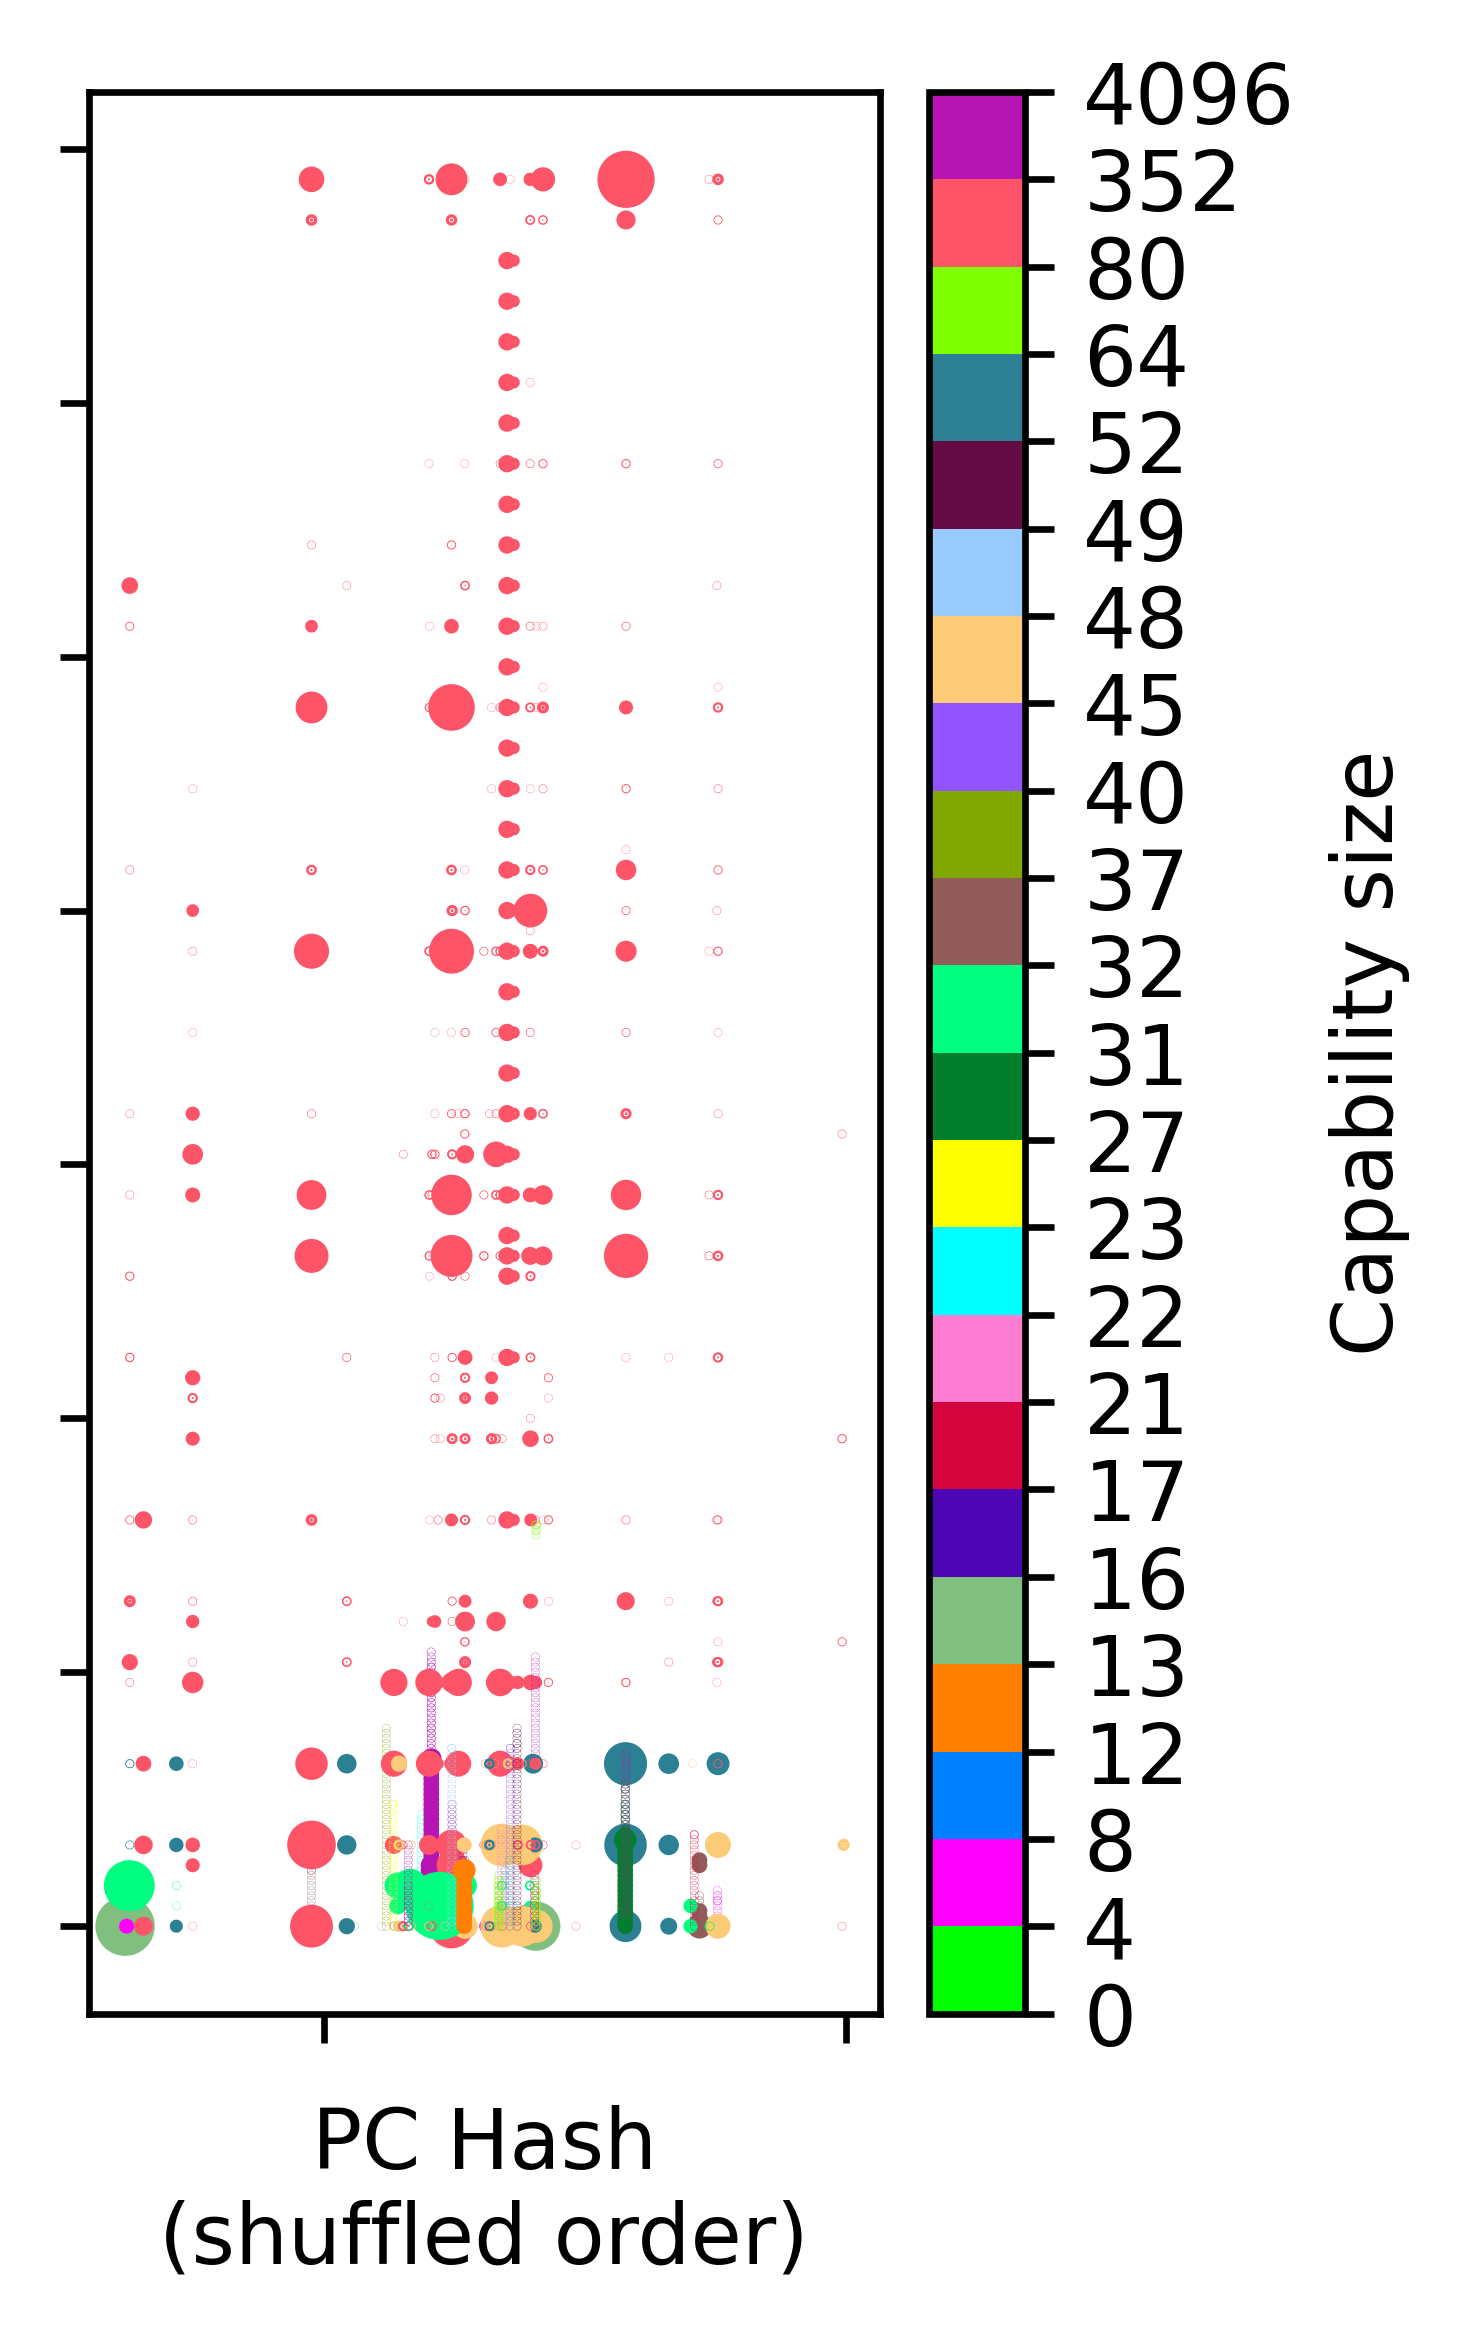

In [1272]:
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
def flatten_offset_correlation_pc(d):
    points = []
    sizes = []
    colors = []

    max_offset = 0
    for correlator, offsets in d.items():
        for offset, countSize in offsets.items():
            max_count = 0
            max_cap_size = 0 
            total_count = 0
            for size, count in countSize.items():
                total_count += count
                # print(f"count {count} max_count {max_count}")
                if count > max_count:
                    max_count = count
                    max_cap_size = size
                    # print(f"updating correlator {correlator} offset {offset} maxcount {max_count} {size}")

            points.append((correlator, offset))
            sizes.append(count/1000)
            colors.append(max_cap_size)
            if offset > max_offset:
                max_offset = offset
    print(max_offset)

    original = list(d.keys())
    np.random.seed(0)
    perm = np.random.permutation(original)
    perm_dict = {original[i]: perm[i] for i in range(len(original))}
    
    points = [(perm_dict[x], y) for x,y in points]  

    return points, sizes, colors
corr_points, corr_sizes, corr_colors = flatten_offset_correlation_pc(pc_offset_correlation_parent_diff_results["health"])

fig = plt.figure(figsize=(2.5,4), dpi=600)
ax = fig.gca()

# define the bins and normalize
cmap = ListedColormap(distinctipy.get_colors(22))
bounds = np.unique(corr_colors)
norm = mpl.colors.BoundaryNorm([0] + list(bounds+1), cmap.N)

x, y = list(zip(*corr_points))
fake_x = range(len(x))
scatter = ax.scatter(x, y, s=corr_sizes, c=corr_colors, cmap=cmap, norm=norm)
# ax2 = fig.add_axes([0.95, 0.1, 0.03, 0.8])
# cb = mpl.colorbar.ColorbarBase(ax2, cmap=cmap, norm=norm,
#     spacing='proportional', ticks=bounds, boundaries=bounds, format='%1i')
# ax.set_xscale('log')
cbar = fig.colorbar(scatter, ticks=[0] + list(bounds+1), label = "Capability size")
cbar.set_ticks(ticks = [0] + list(bounds+1), labels = [0] + list(bounds))
#ax.set_ylabel("Offset")
ax.set_xlabel("PC Hash\n(shuffled order)")
ax.set_xticklabels([])
ax.set_yticklabels([])
fig.tight_layout()
# ax2.set_yscale('log')
fig.savefig("MotivationGraphs/pcCorrHealth4096ParentDifference.png", bbox_inches='tight')

# PC offset correlation

In [729]:
def pc_offset_correlation(name, benchmark_var):
    bound_sizes_counter = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        if data_arrival.requestCap.boundsLength <= 4096:
            bound_sizes_counter[data_arrival.pcHash][data_arrival.requestCap.boundsOffset][data_arrival.requestCap.boundsLength] += 1
    
    return bound_sizes_counter
    

In [730]:
pc_offset_correlation_results = {}
for benchmark in benchmark_names:
    pc_offset_correlation_result = pc_offset_correlation(benchmark, benchmark_results)
    pc_offset_correlation_results[benchmark] = pc_offset_correlation_result

In [860]:
pc_offset_correlation_results["health"]

defaultdict(<function __main__.pc_offset_correlation.<locals>.<lambda>()>,
            {3221226264: defaultdict(<function __main__.pc_offset_correlation.<locals>.<lambda>.<locals>.<lambda>()>,
                         {0: defaultdict(int, {16: 1})}),
             3221226274: defaultdict(<function __main__.pc_offset_correlation.<locals>.<lambda>.<locals>.<lambda>()>,
                         {0: defaultdict(int, {16: 1})}),
             3221226288: defaultdict(<function __main__.pc_offset_correlation.<locals>.<lambda>.<locals>.<lambda>()>,
                         {0: defaultdict(int, {16: 1})}),
             3221227370: defaultdict(<function __main__.pc_offset_correlation.<locals>.<lambda>.<locals>.<lambda>()>,
                         {0: defaultdict(int, {16: 1562})}),
             3221227500: defaultdict(<function __main__.pc_offset_correlation.<locals>.<lambda>.<locals>.<lambda>()>,
                         {0: defaultdict(int,
                                      {23: 1,
        

344


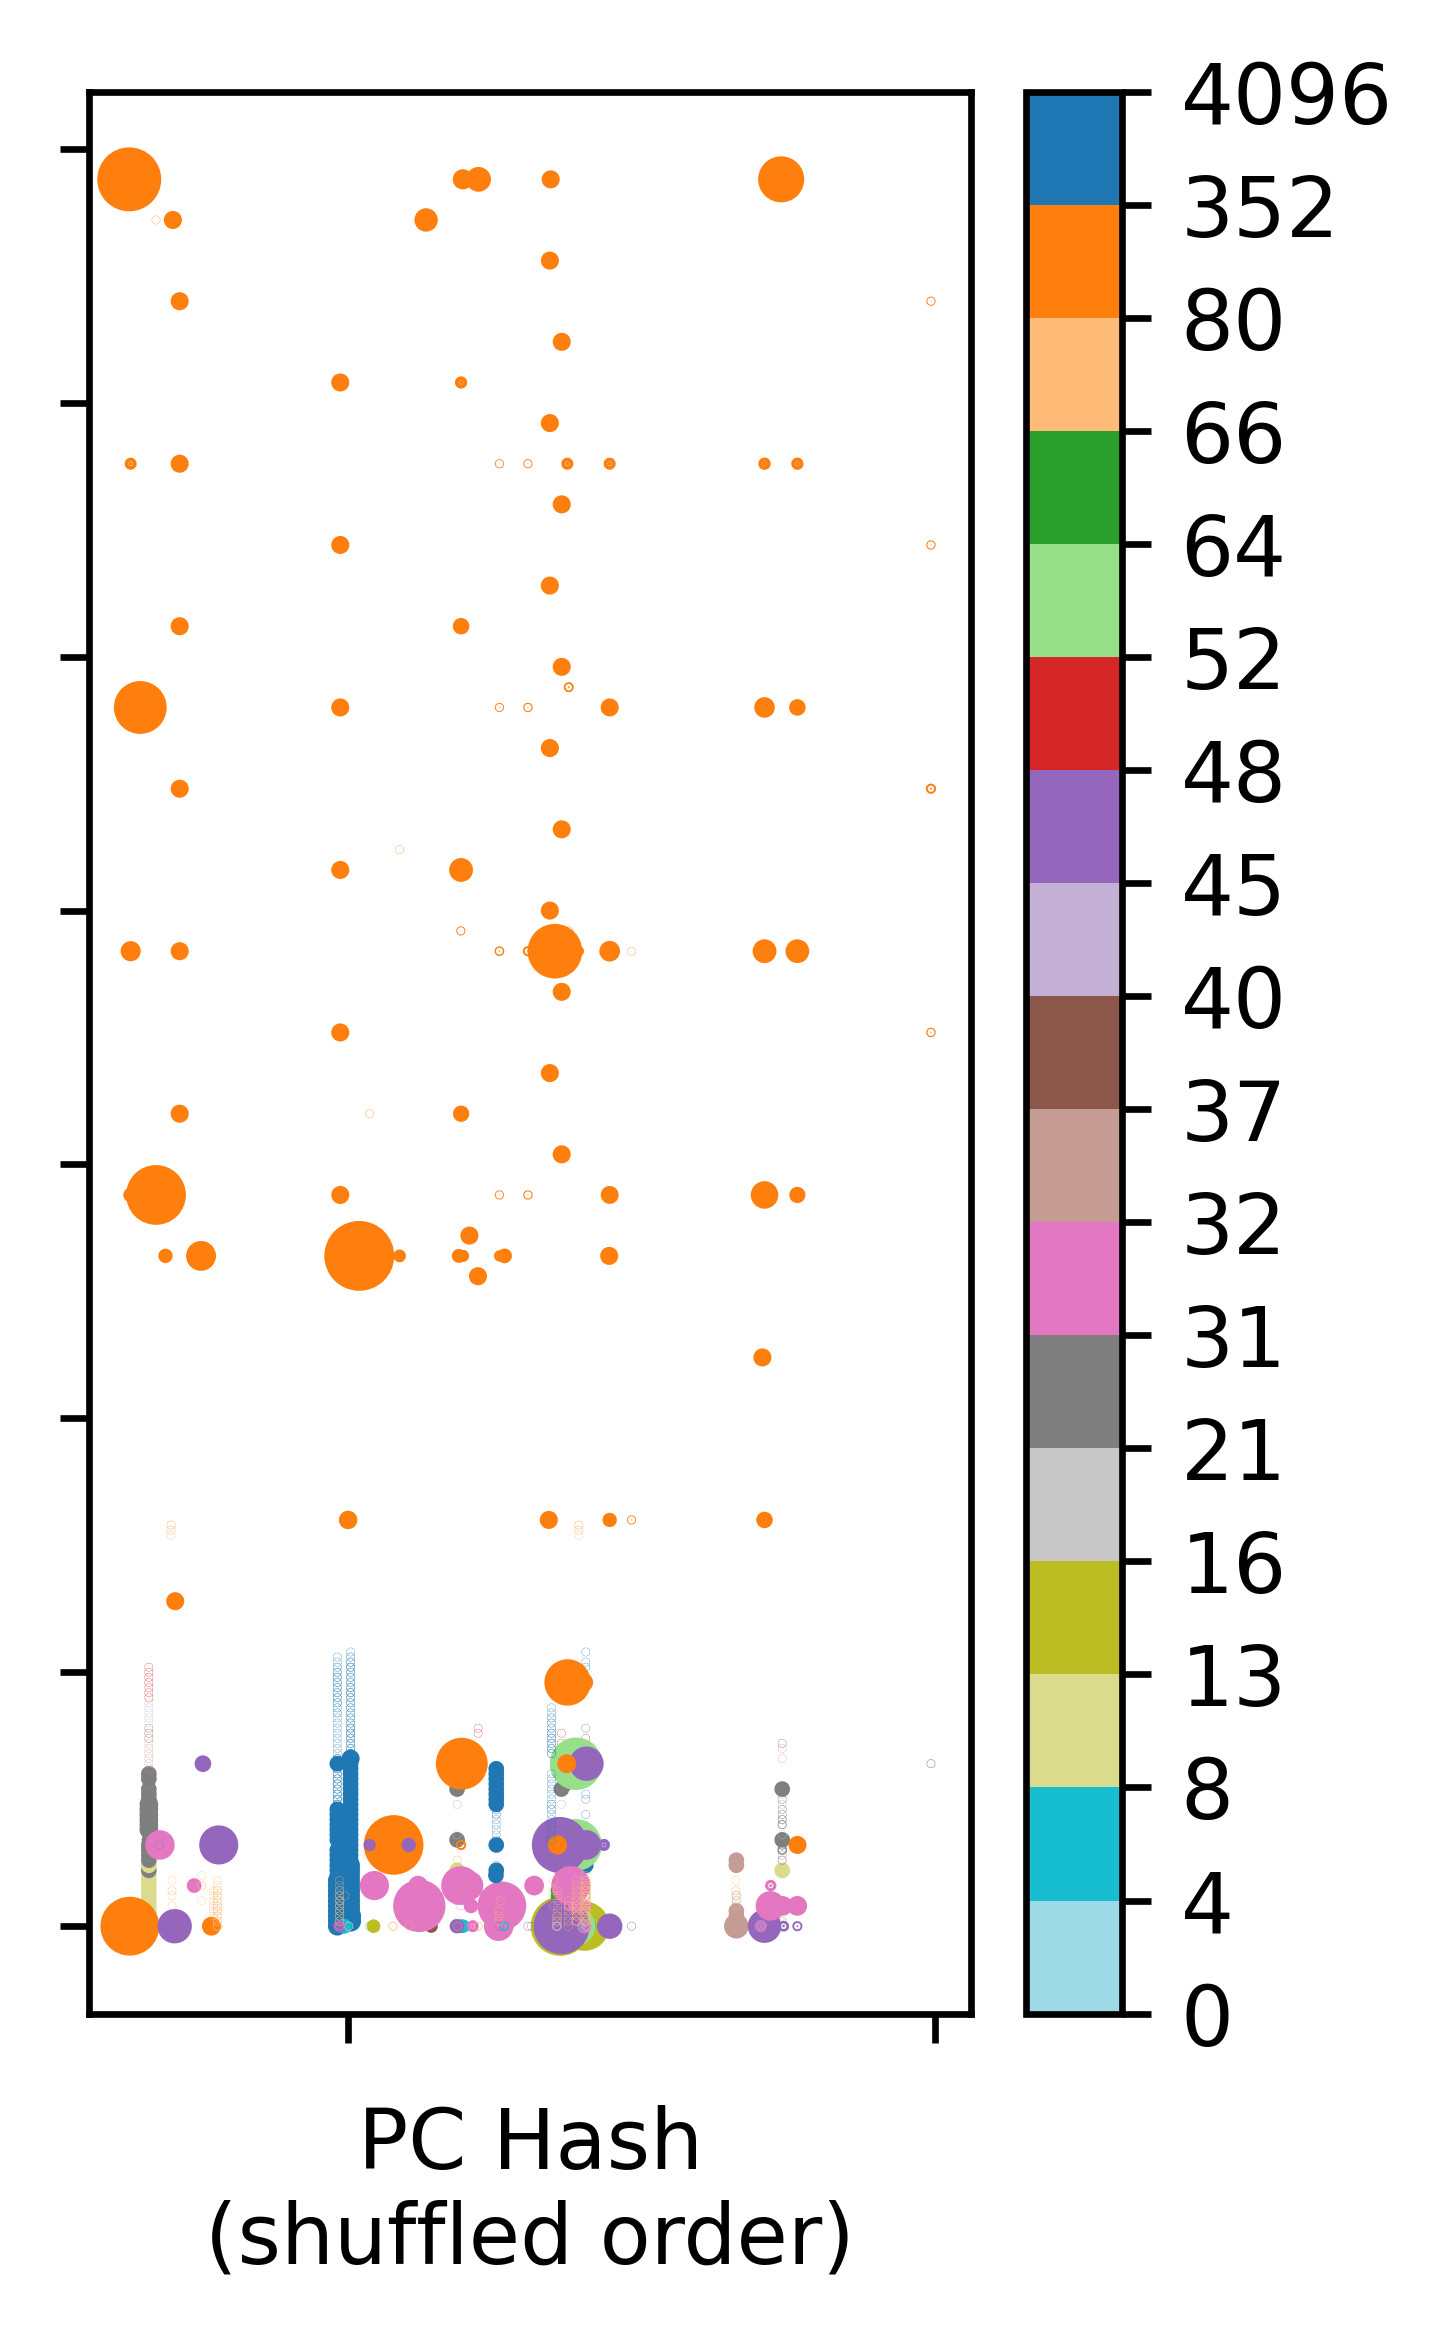

In [1277]:
import matplotlib as mpl
def flatten_offset_correlation_pc(d):
    points = []
    sizes = []
    colors = []

    max_offset = 0
    for correlator, offsets in d.items():
        for offset, countSize in offsets.items():
            max_count = 0
            max_cap_size = 0 
            total_count = 0
            for size, count in countSize.items():
                total_count += count
                # print(f"count {count} max_count {max_count}")
                if count > max_count:
                    max_count = count
                    max_cap_size = size
                    # print(f"updating correlator {correlator} offset {offset} maxcount {max_count} {size}")

            points.append((correlator, offset))
            sizes.append(count/1000)
            colors.append(max_cap_size)
            if offset > max_offset:
                max_offset = offset
    print(max_offset)

    original = list(d.keys())
    perm = np.random.permutation(original)
    perm_dict = {original[i]: perm[i] for i in range(len(original))}
    
    points = [(perm_dict[x], y) for x,y in points]  

    return points, sizes, colors
corr_points, corr_sizes, corr_colors = flatten_offset_correlation_pc(pc_offset_correlation_results["health"])

fig = plt.figure(figsize=(2.5,4), dpi=600)
ax = fig.gca()

# define the bins and normalize
cmap = plt.cm.tab20_r
bounds = np.unique(corr_colors)
norm = mpl.colors.BoundaryNorm([0] + list(bounds+1), cmap.N)

x, y = list(zip(*corr_points))

scatter = ax.scatter(x, y, s=corr_sizes, c=corr_colors, cmap=cmap, norm=norm)
# ax2 = fig.add_axes([0.95, 0.1, 0.03, 0.8])
# cb = mpl.colorbar.ColorbarBase(ax2, cmap=cmap, norm=norm,
#     spacing='proportional', ticks=bounds, boundaries=bounds, format='%1i')
# ax.set_xscale('log')
cbar = fig.colorbar(scatter, ticks=[0] + list(bounds+1))
cbar.set_ticks(ticks = [0] + list(bounds+1), labels = [0] + list(bounds))
#ax.set_ylabel("Offset")
ax.set_xlabel("PC Hash\n(shuffled order)")
ax.set_xticklabels([])
ax.set_yticklabels([])
fig.tight_layout()
# ax2.set_yscale('log')
fig.savefig("MotivationGraphs/pcCorrHealth4096.pdf", bbox_inches='tight')


In [699]:
np.argmax(corr_sizes)

382

In [706]:
np.argpartition(corr_sizes, -4)[-4:]

array([343, 352, 354, 382])

In [713]:
x[343]

3221233450

In [714]:
corr_colors[343]

352

# PC correlation MiBench

In [939]:
def corr_parent_cap_size_mibench(name, benchmark_var):
    backwards = {}
    bound_sizes_counter = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))


    for data_arrival in benchmark_var[name]["data_arrivals"]:
        if data_arrival.sel_capability:
            backwards[data_arrival.sel_capability.cap.capKey()] = data_arrival.pcHash

        if data_arrival.requestCap.capKey() in backwards and data_arrival.requestCap.boundsLength <= 4096:
            bound_sizes_counter[backwards[data_arrival.requestCap.capKey()]][data_arrival.requestCap.boundsOffset][data_arrival.requestCap.boundsLength] += 1
        
    return bound_sizes_counter

In [940]:
pc_offset_correlation_mibench_results = {}
for benchmark in benchmark_name_mibench:
    pc_offset_correlation_mibench_result = corr_parent_cap_size_mibench(benchmark, bechmark_result_mibench)
    pc_offset_correlation_mibench_results[benchmark] = pc_offset_correlation_mibench_result

In [947]:
# https://stackoverflow.com/questions/4601373/better-way-to-shuffle-two-numpy-arrays-in-unison
def unison_shuffled_copies(a, b, c):
    assert len(a) == len(b) == len(c)
    p = np.random.permutation(len(a))
    return np.array(a)[p], np.array(b)[p], np.array(c)[p]

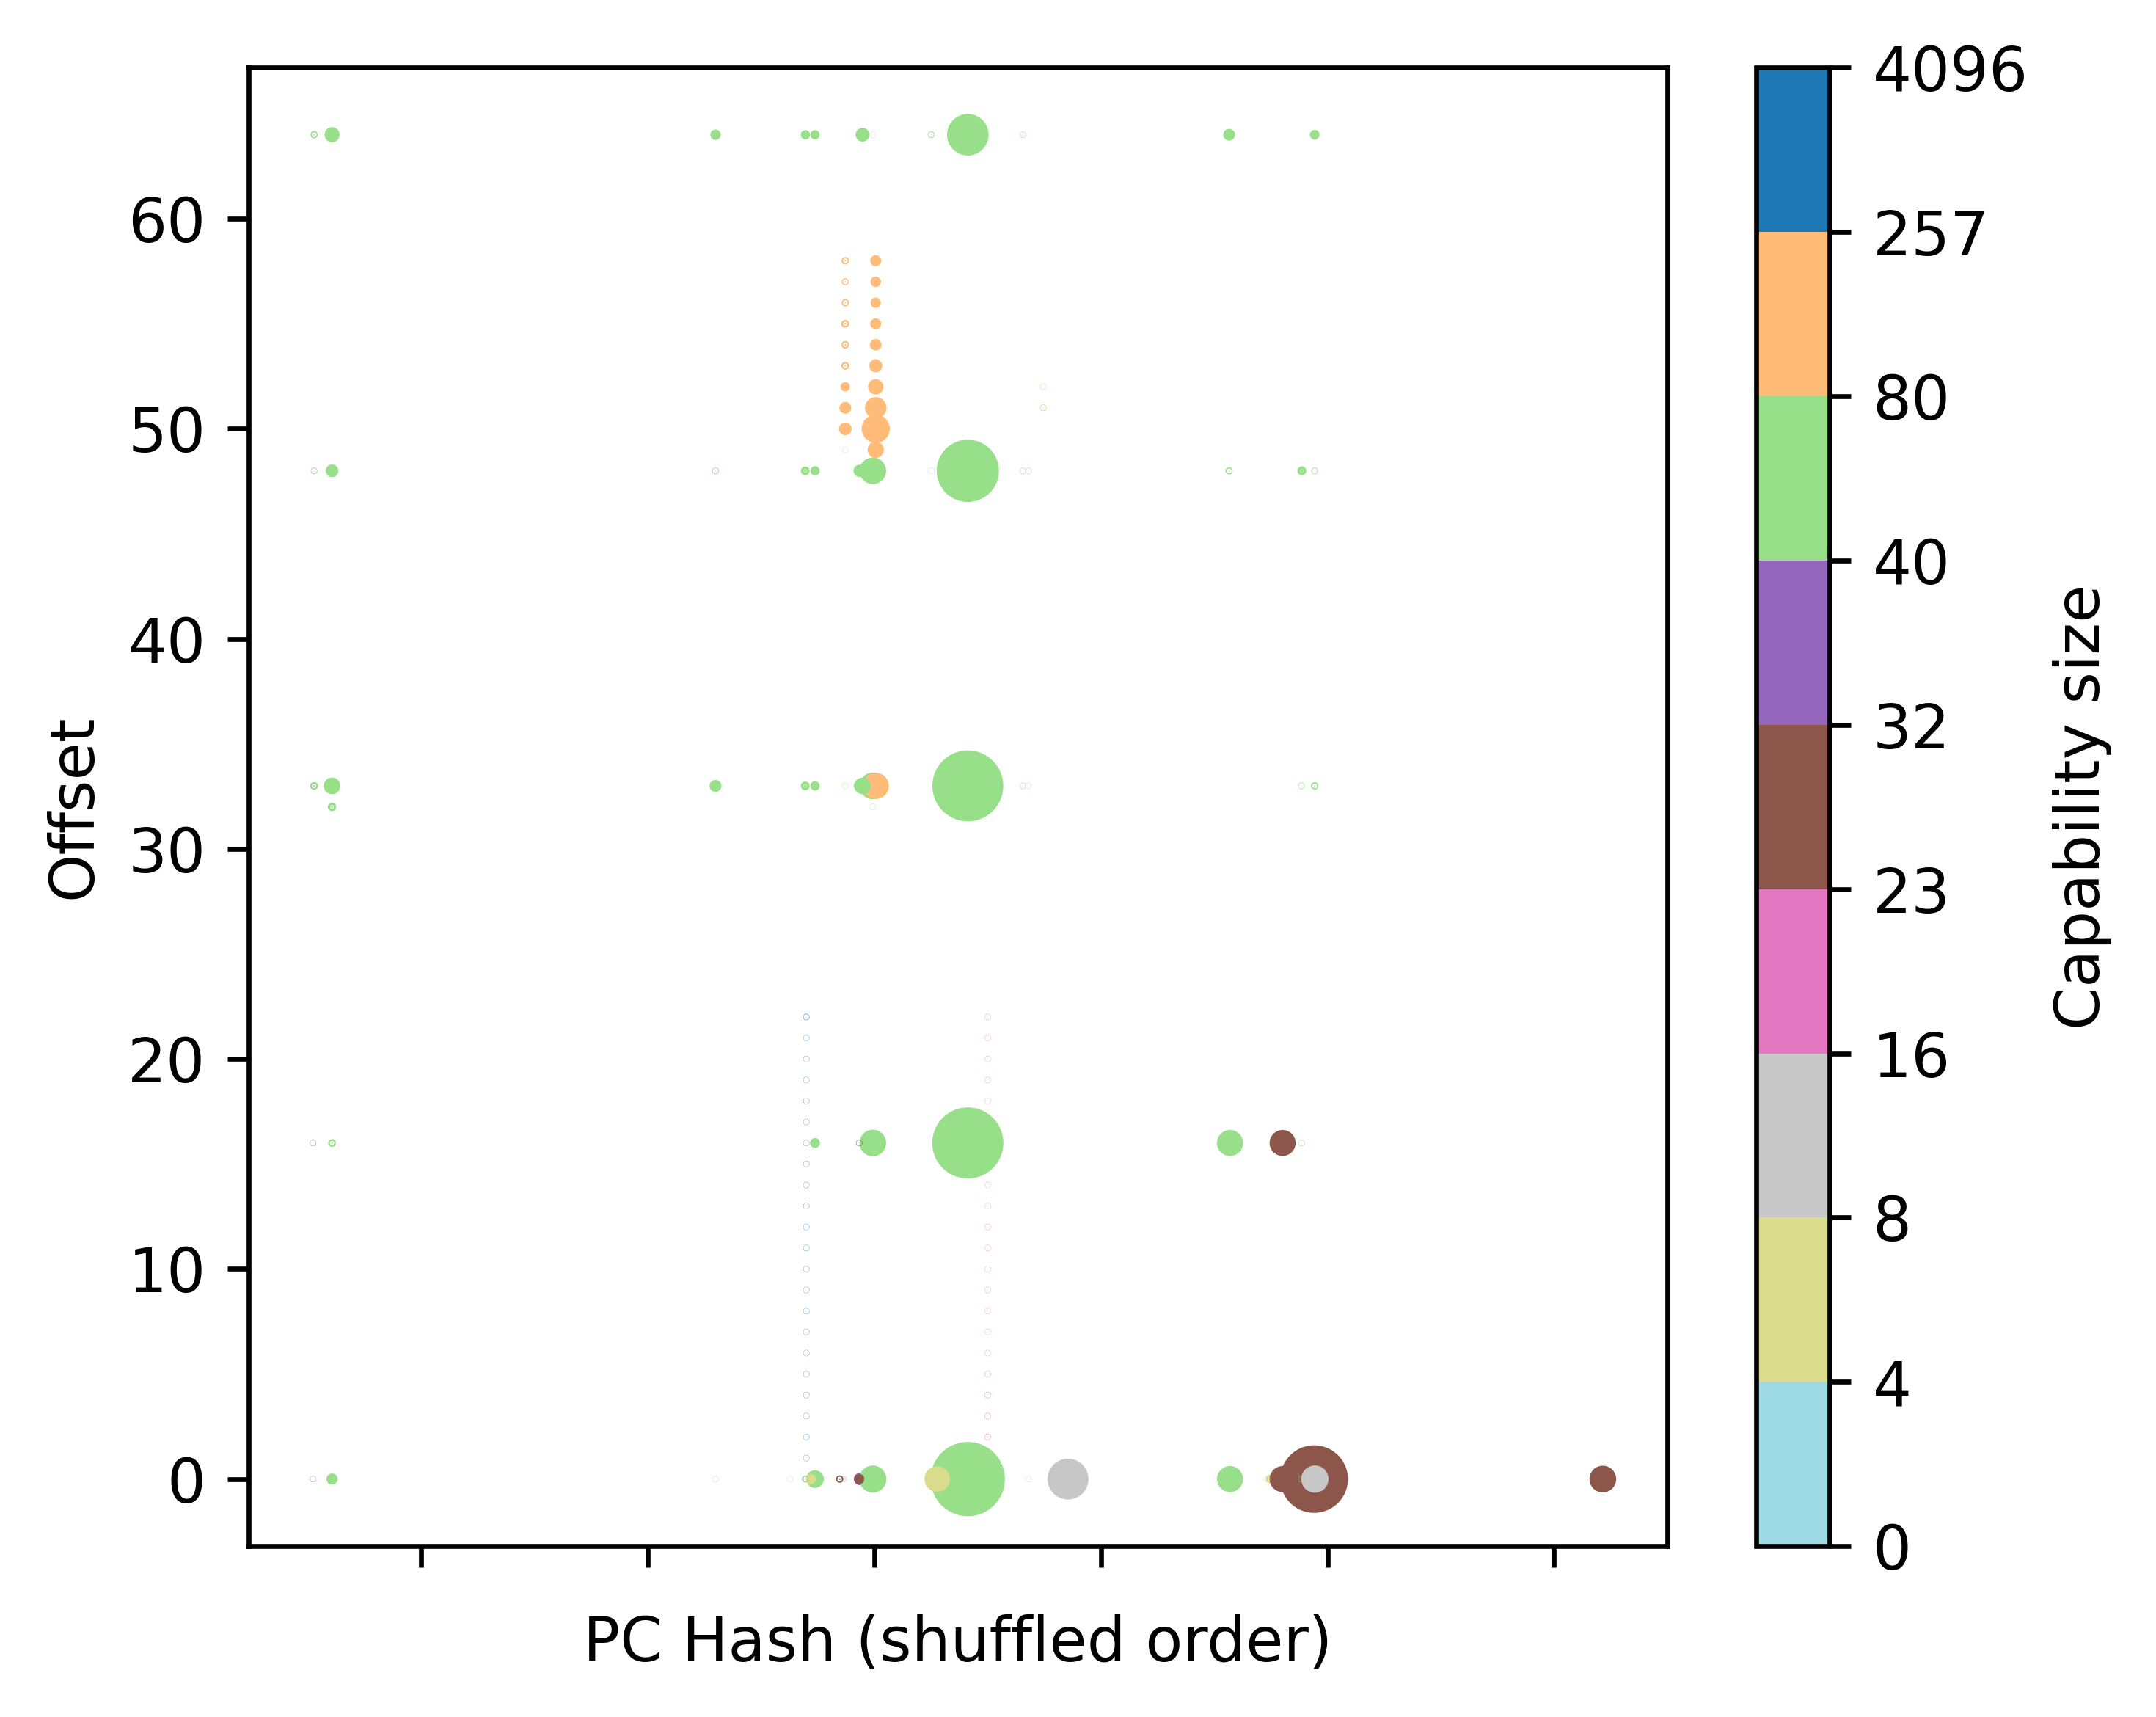

In [980]:
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
def flatten_offset_correlation_pc(d):
    points = []
    sizes = []
    colors = []

    max_offset = 0
    for correlator, offsets in d.items():
        for offset, countSize in offsets.items():
            max_count = 0
            max_cap_size = 0 
            total_count = 0
            for size, count in countSize.items():
                total_count += count
                # print(f"count {count} max_count {max_count}")
                if count > max_count:
                    max_count = count
                    max_cap_size = size
                    # print(f"updating correlator {correlator} offset {offset} maxcount {max_count} {size}")

            points.append((correlator, offset))
            sizes.append(count/1000)
            colors.append(max_cap_size)
            if offset > max_offset:
                max_offset = offset

    original = list(d.keys())
    perm = np.random.permutation(original)
    perm_dict = {original[i]: perm[i] for i in range(len(original))}
    
    points = [(perm_dict[x], y) for x,y in points]                               
    
    return points, sizes, colors
corr_points, corr_sizes, corr_colors = flatten_offset_correlation_pc(pc_offset_correlation_mibench_results["patricia"])

fig = plt.figure(figsize=(5,4), dpi=600)
ax = fig.gca()

# define the bins and normalize
cmap = plt.cm.tab20_r
bounds = np.unique(corr_colors)
norm = mpl.colors.BoundaryNorm([0] + list(bounds+1), cmap.N)

x, y = list(zip(*corr_points))
fake_x = range(len(x))
scatter = ax.scatter(x, y, s=corr_sizes, c=corr_colors, cmap=cmap, norm=norm)
# ax2 = fig.add_axes([0.95, 0.1, 0.03, 0.8])
# cb = mpl.colorbar.ColorbarBase(ax2, cmap=cmap, norm=norm,
#     spacing='proportional', ticks=bounds, boundaries=bounds, format='%1i')
# ax.set_xscale('log')
cbar = fig.colorbar(scatter, ticks=[0] + list(bounds+1), label = "Capability size")
cbar.set_ticks(ticks = [0] + list(bounds+1), labels = [0] + list(bounds))
ax.set_ylabel("Offset")
ax.set_ylabel("Offset")
ax.set_xlabel("PC Hash (shuffled order)")
ax.set_xticklabels([])
fig.tight_layout()
fig.tight_layout()
# ax2.set_yscale('log')
fig.savefig("MotivationGraphs/pcCorrBackwardsPatricia.pdf", bbox_inches='tight')


# Number of cap sizes seen at a particular PC

In [855]:
def pc_number_of_caps_sizes(name, benchmark_var):
    bound_sizes_counter = defaultdict(set)
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        #if data_arrival.requestCap.boundsLength <= 4096:
        bound_sizes_counter[data_arrival.pcHash].add(data_arrival.requestCap.boundsLength)
    
    return bound_sizes_counter
    

In [857]:
pc_num_caps_results = {}
for benchmark in benchmark_names:
    pc_num_caps_result = pc_number_of_caps_sizes(benchmark, benchmark_results)
    pc_num_caps_results[benchmark] = pc_num_caps_result

In [884]:
df = nested_dict_to_df({k: dict_of_set_to_count(v) for k,v in pc_num_caps_results.items()})
df

,3221225666,3221225862,3221225864,3221225880,3221225972,3221226062,3221226072,3221226082,3221226088,3221226092,...,3221247348,3221247350,3221247352,3221247354,3221250314,3221250316,3221250322,3221250330,3221250350,3221250352
bh,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
bisort,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
em3d,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
health,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
perimeter,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
power,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treeadd,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tsp,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [885]:
df = df.median(axis=1)
df

bh           1.0
bisort       1.0
em3d         1.0
health       1.0
perimeter    1.0
power        1.0
treeadd      1.0
tsp          1.0
dtype: float64

<Axes: >

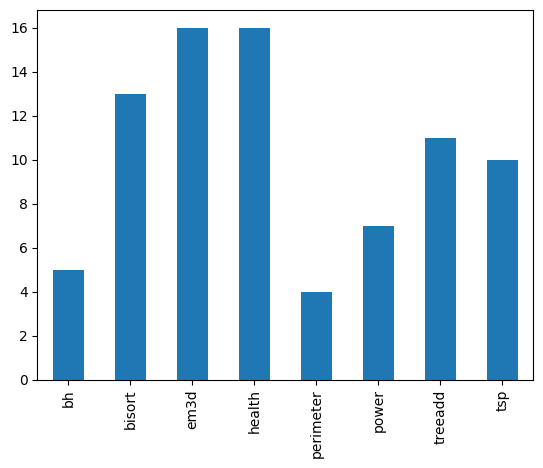

In [862]:
df.plot.bar(legend=False)

In [702]:
pc_num_caps_results["health"][3221233734]

{352}

In [880]:
[(k,v) for k,v in pc_num_caps_results["health"].items() if 352 in v]

[(3221231850, {352}),
 (3221231854, {352}),
 (3221231884, {352}),
 (3221231914, {352}),
 (3221231918, {352}),
 (3221231922, {352}),
 (3221231930, {352}),
 (3221231934, {352}),
 (3221237652, {352}),
 (3221237654, {352}),
 (3221237656, {352}),
 (3221237658, {352}),
 (3221231952, {352}),
 (3221231956, {352}),
 (3221231960, {352}),
 (3221231964, {352}),
 (3221233418, {352}),
 (3221233436, {352}),
 (3221233450, {352}),
 (3221233464, {352}),
 (3221233616, {352}),
 (3221233694, {352}),
 (3221233650, {352}),
 (3221233710, {352}),
 (3221233796, {352}),
 (3221233848, {352}),
 (3221233892, {352}),
 (3221234002, {48, 352}),
 (3221233902, {352}),
 (3221233922, {32, 48, 352}),
 (3221234028, {48, 352}),
 (3221233734, {352}),
 (3221232580, {352}),
 (3221232592, {352}),
 (3221234040, {352}),
 (3221234046, {48, 352}),
 (3221232618, {352}),
 (3221234056, {48, 352}),
 (3221234060, {48, 352}),
 (3221234048, {48, 352}),
 (3221234054, {48, 352}),
 (3221234058, {352}),
 (3221232656, {32, 48, 352}),
 (32212325

# What proportion of capabilities are used?

In [369]:
def caps_used(name, benchmark_var):
    caps_used = set()
    caps_seen = set()
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        caps_used.add(data_arrival.requestCap.boundsVirtBase)
        for cap in data_arrival.capabilites:
            caps_seen.add(cap.cap.boundsVirtBase)    
                          
    return caps_used, caps_seen    

In [370]:
caps_used_health, caps_seen_health = caps_used("health", benchmark_results)

In [371]:
len(caps_seen_health) - len(caps_used_health)

735

In [372]:
len(caps_seen_health)

23064

In [374]:
len(caps_used_health - caps_seen_health)

3914

# Aggregation of capability sizes

In [840]:
size_bins = np.array([0,64,128, 8192, 33554432, 18446744073709551616], 'float64')
def size_agg(name, benchmark_var):
    agg_size_counter = defaultdict(int)
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        for i in range(len(size_bins)):
            if size_bins[i] >= data_arrival.requestCap.boundsLength:
                agg_size_counter[i-1] += 1
                # print(f"{data_arrival.requestCap.boundsLength} {i-1} {size_bins[i-1]}")
        #print(data_arrival.requestCap.boundsLength)
        # bins_num = np.digitize(np.array(data_arrival.requestCap.boundsLength, dtype='float64'), size_bins, right=True)
        # agg_size_counter[bins_num] += 1
            
    return agg_size_counter
    

In [841]:
size_agg_results = {}
for benchmark in benchmark_names:
    size_agg_result = size_agg(benchmark, benchmark_results)
    size_agg_results[benchmark] = size_agg_result

In [842]:
size_agg_results

{'bh': defaultdict(int,
             {4: 5505247, 3: 5380714, 0: 7941, 1: 3340769, 2: 3954539}),
 'bisort': defaultdict(int,
             {4: 3392327, 3: 3156289, 0: 1613693, 1: 1668908, 2: 1888335}),
 'em3d': defaultdict(int,
             {4: 618766, 3: 563988, 0: 59277, 1: 118532, 2: 290376}),
 'health': defaultdict(int,
             {4: 4164013, 3: 3816305, 0: 504643, 1: 526447, 2: 1161100}),
 'perimeter': defaultdict(int,
             {4: 3168002, 3: 2961403, 0: 28730, 1: 763993, 2: 897163}),
 'power': defaultdict(int,
             {4: 1017233, 3: 547560, 0: 225534, 1: 235289, 2: 297874}),
 'treeadd': defaultdict(int,
             {4: 2697583, 3: 1875209, 0: 377264, 1: 432486, 2: 728710}),
 'tsp': defaultdict(int,
             {4: 2070439, 3: 1177627, 0: 241132, 1: 622056, 2: 848573})}

In [843]:
df = nested_dict_to_df(size_agg_results)
df = df.div(df.sum(axis=1), axis=0)
df

,0,1,2,3,4
bh,0.000437,0.183668,0.217411,0.295819,0.302666
bisort,0.137692,0.142404,0.161127,0.269318,0.289459
em3d,0.035905,0.071797,0.175885,0.341616,0.374796
health,0.049609,0.051752,0.114141,0.375159,0.409340
perimeter,0.003674,0.097706,0.114737,0.378730,0.405152
power,0.097067,0.101265,0.128201,0.235663,0.437804
treeadd,0.061733,0.070769,0.119241,0.306845,0.441412
tsp,0.048617,0.125419,0.171089,0.237433,0.417442


<Axes: >

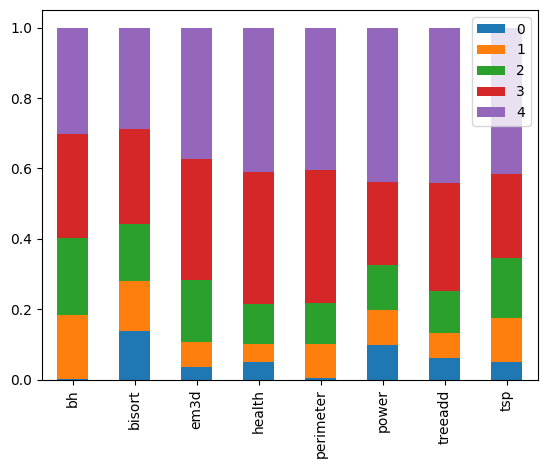

In [844]:
df.plot.bar(stacked=True)

In [829]:
def size_agg_misses(name, benchmark_var):
    agg_size_counter = defaultdict(int)
    
    for data_arrival in benchmark_var[name]["data_arrivals"]:
        if data_arrival.wasMiss:
            for i in range(len(size_bins)):
                if size_bins[i] >= data_arrival.requestCap.boundsLength:
                    agg_size_counter[i-1] += 1
                    # print(f"{data_arrival.requestCap.boundsLength} {i-1} {size_bins[i-1]}")
            #print(data_arrival.requestCap.boundsLength)
            # bins_num = np.digitize(np.array(data_arrival.requestCap.boundsLength, dtype='float64'), size_bins, right=True)
            # agg_size_counter[bins_num] += 1
            
    return agg_size_counter
    

In [830]:
size_agg_wasmiss_results = {}
for benchmark in benchmark_names:
    size_agg_wasmiss_result = size_agg_misses(benchmark, benchmark_results)
    size_agg_wasmiss_results[benchmark] = size_agg_wasmiss_result

In [836]:
df = nested_dict_to_df(size_agg_wasmiss_results)
df = df.div(df.sum(axis=1), axis=0)
df

,0,1,2,3,4
bh,0.001747,0.078322,0.265377,0.319965,0.334590
bisort,0.177857,0.181739,0.183311,0.221945,0.235148
em3d,0.037233,0.161568,0.222081,0.264446,0.314672
health,0.093098,0.093878,0.224017,0.277410,0.311597
perimeter,0.004312,0.211999,0.216238,0.263989,0.303462
power,0.112346,0.127213,0.203436,0.260174,0.296831
treeadd,0.102654,0.112434,0.167695,0.266554,0.350663
tsp,0.001005,0.241792,0.244355,0.253444,0.259404


<Axes: >

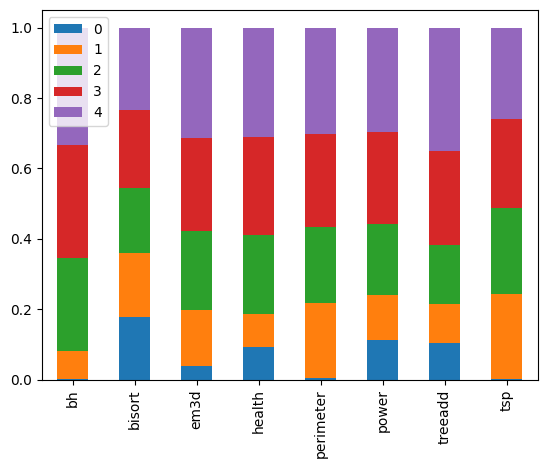

In [837]:
df.plot.bar(stacked=True)

# Timeliness with just offsets

In [1279]:
def timeliness_counts(name, benchmark_var):
    virt_base_to_access = defaultdict(list)
    virt_base_to_access_index = defaultdict(list)
    for event in benchmark_var[name]['total_order_events']:
        if isinstance(event, ReportAccessLog):
            virt_base_to_access[event.cap.boundsVirtBase].append(event.clock_time)
            virt_base_to_access_index[event.cap.boundsVirtBase].append(event.index)

    for k,v in virt_base_to_access.items():
        virt_base_to_access[k] = np.array(v)
        assert(np.all(np.array(v)[:-1] <= np.array(v)[1:]))


    def find_timely_pc(virt_base_to_access, virt_base, end_time, time_before):
        limited_access = virt_base_to_access[virt_base]
        index_list = virt_base_to_access_index[virt_base]
        index = np.searchsorted(limited_access, end_time - time_before, side="right")
        if index == 0 or index == -1:
            # print(index)
            return None, None
        else:
            # print(f"{limited_access[index-1]} {end_time - time_before}")
            return limited_access[index - 1], index_list[index - 1]
        # for access in reversed(limited_access):
        #     if access <= end_time - time_before:
        #         return access
    
    to_report_access = {}
    to_report_access_hit = {}
    backwards = {}
    timeliness_counts = []
    index_counts = []
    no_timely = 0

    for event in benchmark_var[name]['total_order_events']:
        if isinstance(event, ReportAccessLog):
            if event.isMiss: # only misses as have hit later on miss
                to_report_access[event.addr] = event
            else:
                to_report_access_hit[event.addr] = event
        elif isinstance(event, ReportDataArrival):
            if event.sel_capability:
                if event.requestAddr in to_report_access:
                    if event.wasMiss:
                        backwards[event.sel_capability.cap.capKey()] = to_report_access[event.requestAddr].clock_time, event.requestCap.boundsVirtBase, event.index
                    else:
                        backwards[event.sel_capability.cap.capKey()] = event.clock_time, event.requestCap.boundsVirtBase, event.index
            if event.requestCap.capKey() in backwards and event.wasMiss:
                #bound_sizes_counter[backwards[data_arrival.requestCap.capKey()]][data_arrival.requestCap.boundsOffset][data_arrival.requestCap.boundsLength] += 1
                #timeliness_counts.append(event.clock_time - backwards[event.requestCap.capKey()][0])

                timely_arrival, timely_index = find_timely_pc(virt_base_to_access, backwards[event.requestCap.capKey()][1], backwards[event.requestCap.capKey()][0], event.clock_time - backwards[event.requestCap.capKey()][0])
                if timely_arrival:
                    timeliness_counts.append(backwards[event.requestCap.capKey()][0] - timely_arrival)
                    index_counts.append(backwards[event.requestCap.capKey()][2] - timely_index)  
                else:
                    no_timely += 1
    print(no_timely)
    return timeliness_counts, index_counts

In [1285]:
timeliness_count_results = {}
timeliness_index_count_results = {}
for benchmark in benchmark_names:
    timeliness_count_result, index_counts_result = timeliness_counts(benchmark, benchmark_results)
    timeliness_count_results[benchmark] = timeliness_count_result
    timeliness_index_count_results[benchmark] = index_counts_result

33531
6255
3505
56932
19935
1770
24659
3954


In [1286]:
df = pd.DataFrame.from_dict(timeliness_count_results["health"])
df

,0
0,1808.0
1,1042.0
2,472.0
3,14.0
4,504.0
...,...
238844,293.0
238845,241.0
238846,150.0
238847,11.0


In [1287]:
def plot_hist(df, xlabel, ylabel, filename, log=False, stacked=False, format_sci=True, figsize=(10,4)):
    fig = plt.figure(figsize=figsize, dpi=600)
    ax = fig.gca()
    ax = df.plot.hist(bins = 100, figsize=figsize, xlabel=xlabel, ylabel=ylabel, ax=ax, legend=False)
    # if format_sci:
    #     ax.get_yaxis().set_major_formatter(
    #         matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    fig.savefig("MotivationGraphs/"+filename+".pdf", bbox_inches='tight')
    return ax

<Axes: xlabel='Timeliness (cycles)', ylabel='Number of misses'>

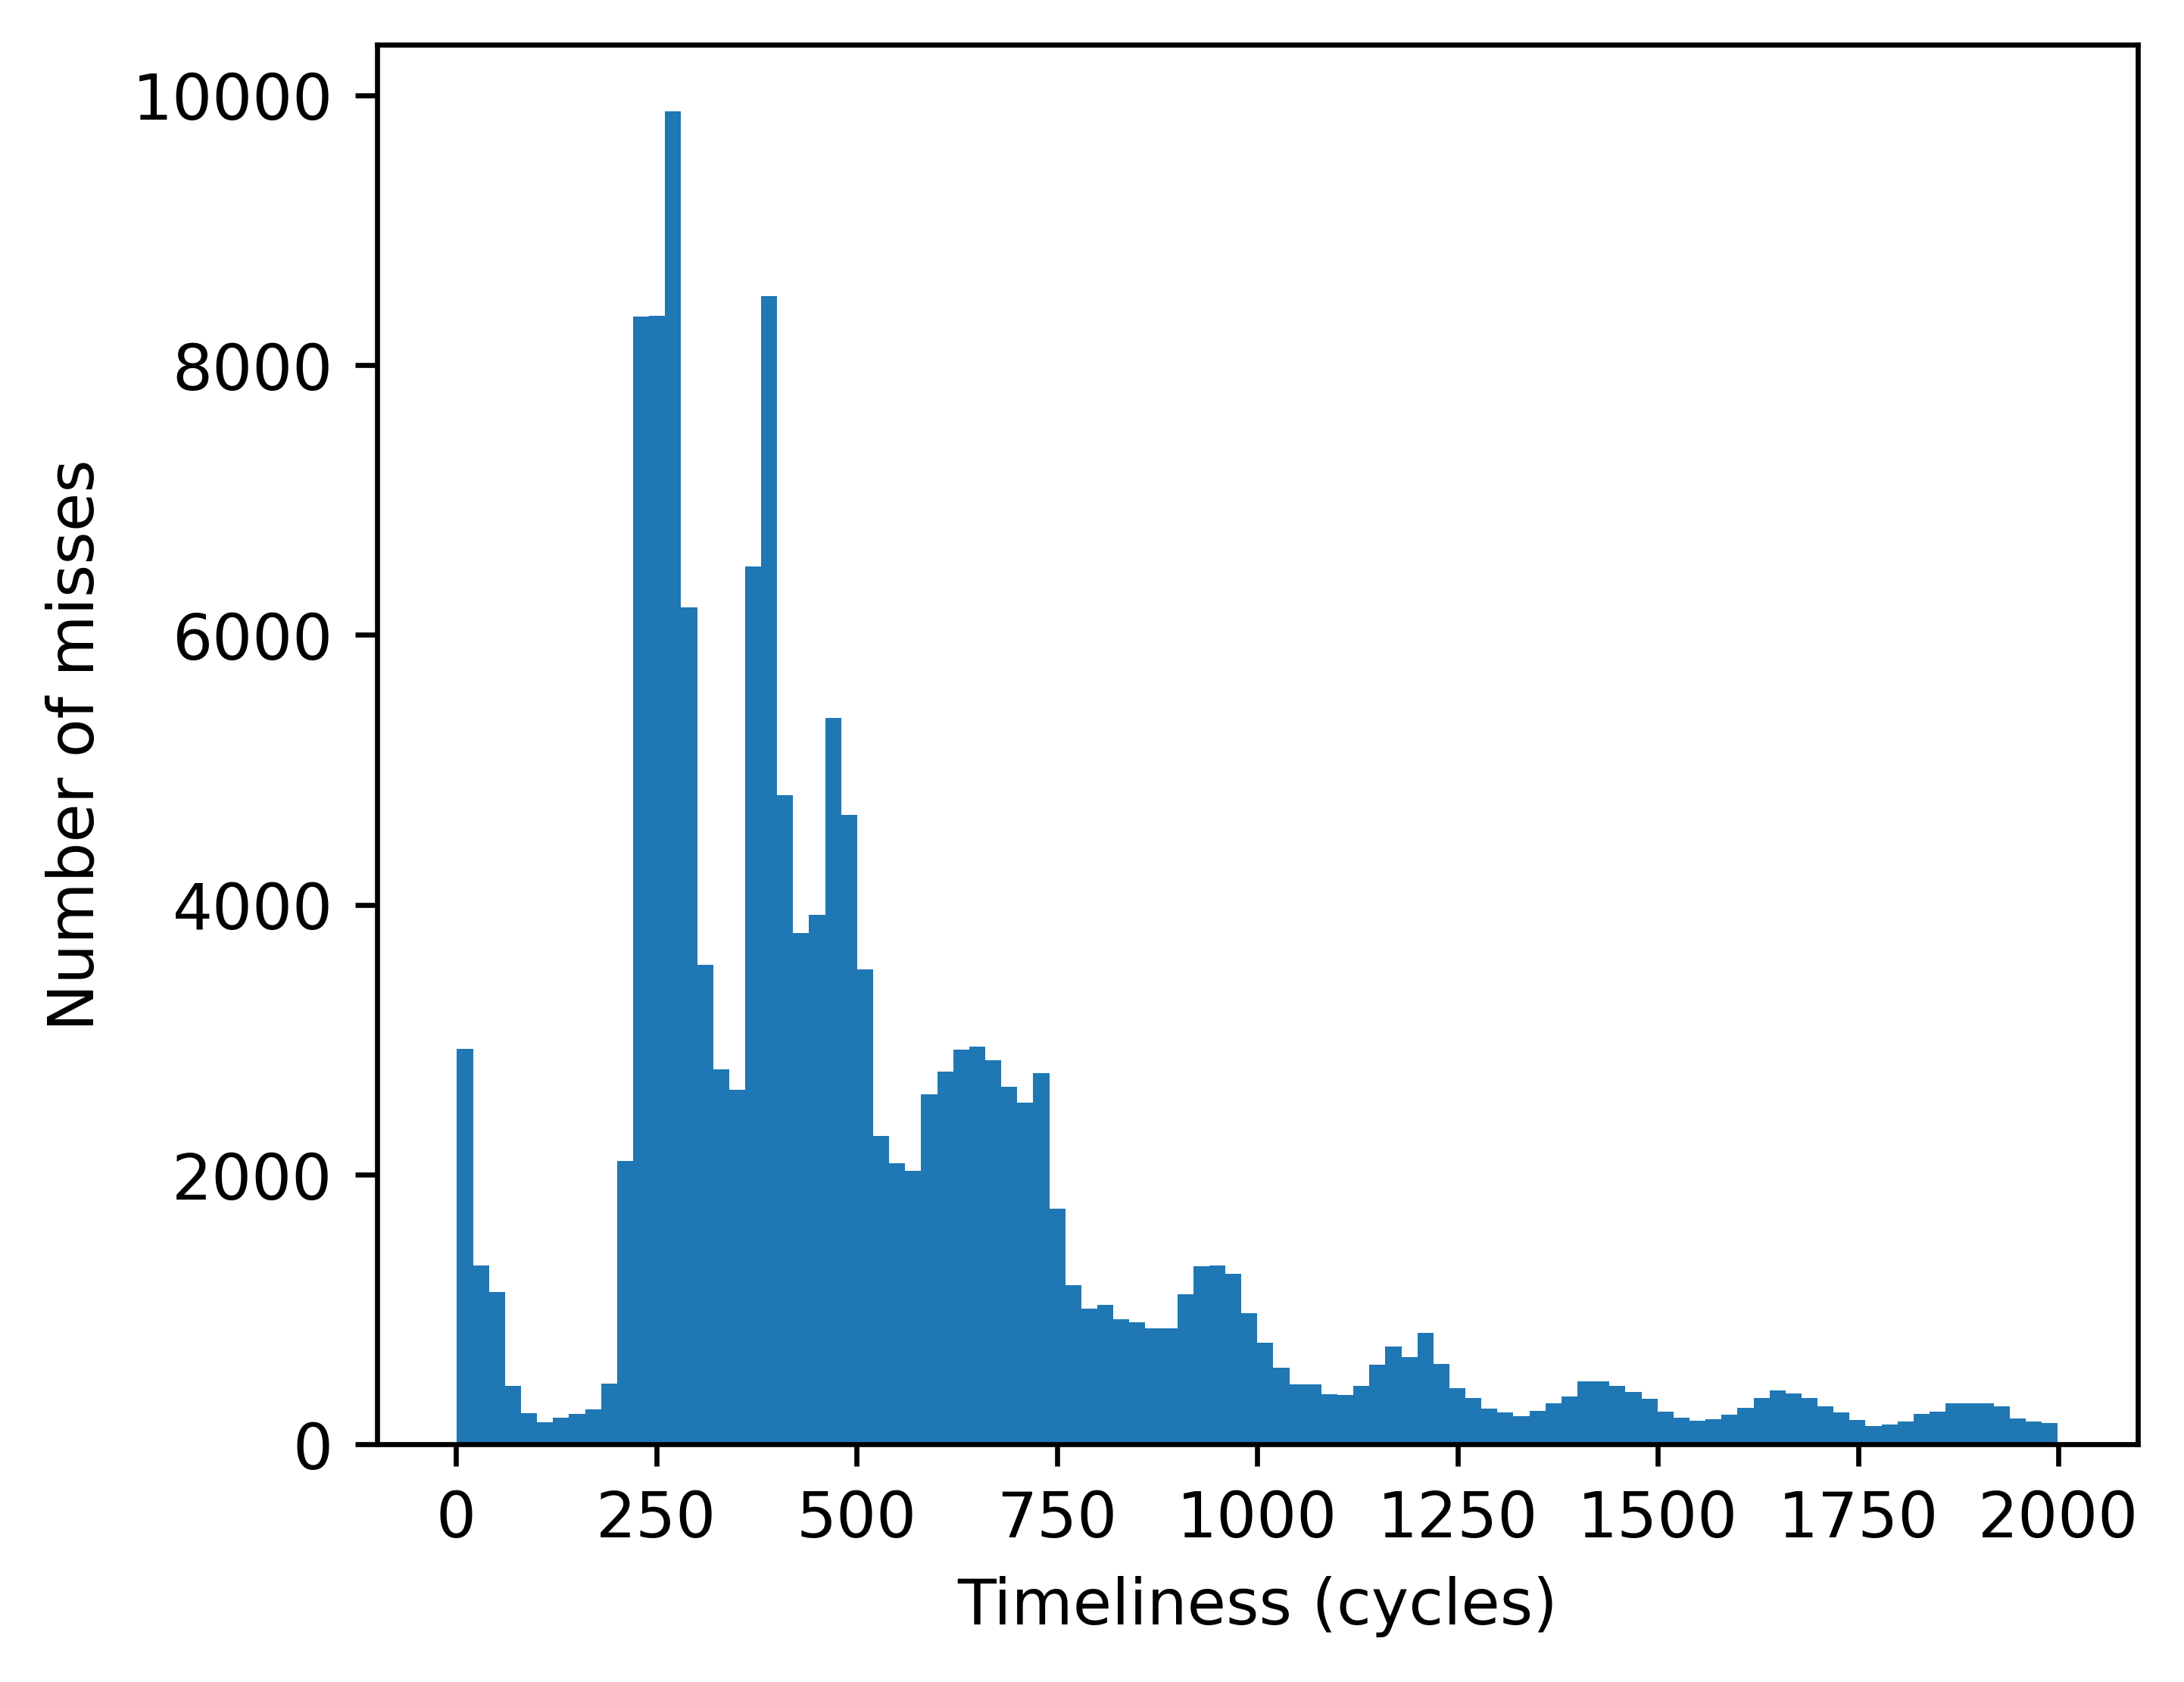

In [1288]:
plot_hist(df[df<2000], "Timeliness (cycles)", "Number of misses", "timelinessHealth", figsize=(5,4))

<Axes: ylabel='Frequency'>

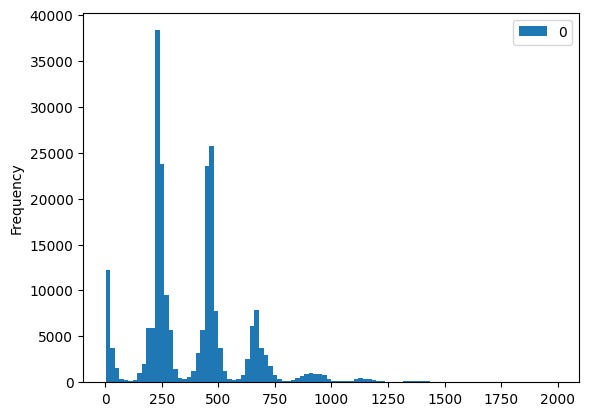

In [1136]:
df[df < 2000].plot.hist(bins = 100)

# MiBench

In [1280]:
timeliness_count_mibench_results = {}
timeliness_index_count_mibench_results = {}
for benchmark in benchmark_name_mibench:
    timeliness_count_mibench_result, timeliness_index_count_mibench_result = timeliness_counts(benchmark, bechmark_result_mibench)
    timeliness_count_mibench_results[benchmark] = timeliness_count_mibench_result
    timeliness_index_count_mibench_results[benchmark] = timeliness_index_count_mibench_result

0
0
2849
0
2697


In [1289]:
df = pd.DataFrame.from_dict(timeliness_count_mibench_results["patricia"])
df

,0
0,984.0
1,1706.0
2,783.0
3,474.0
4,491.0
...,...
155958,17.0
155959,28.0
155960,1082.0
155961,1082.0


<Axes: xlabel='Timeliness (cycles)', ylabel='Number of misses'>

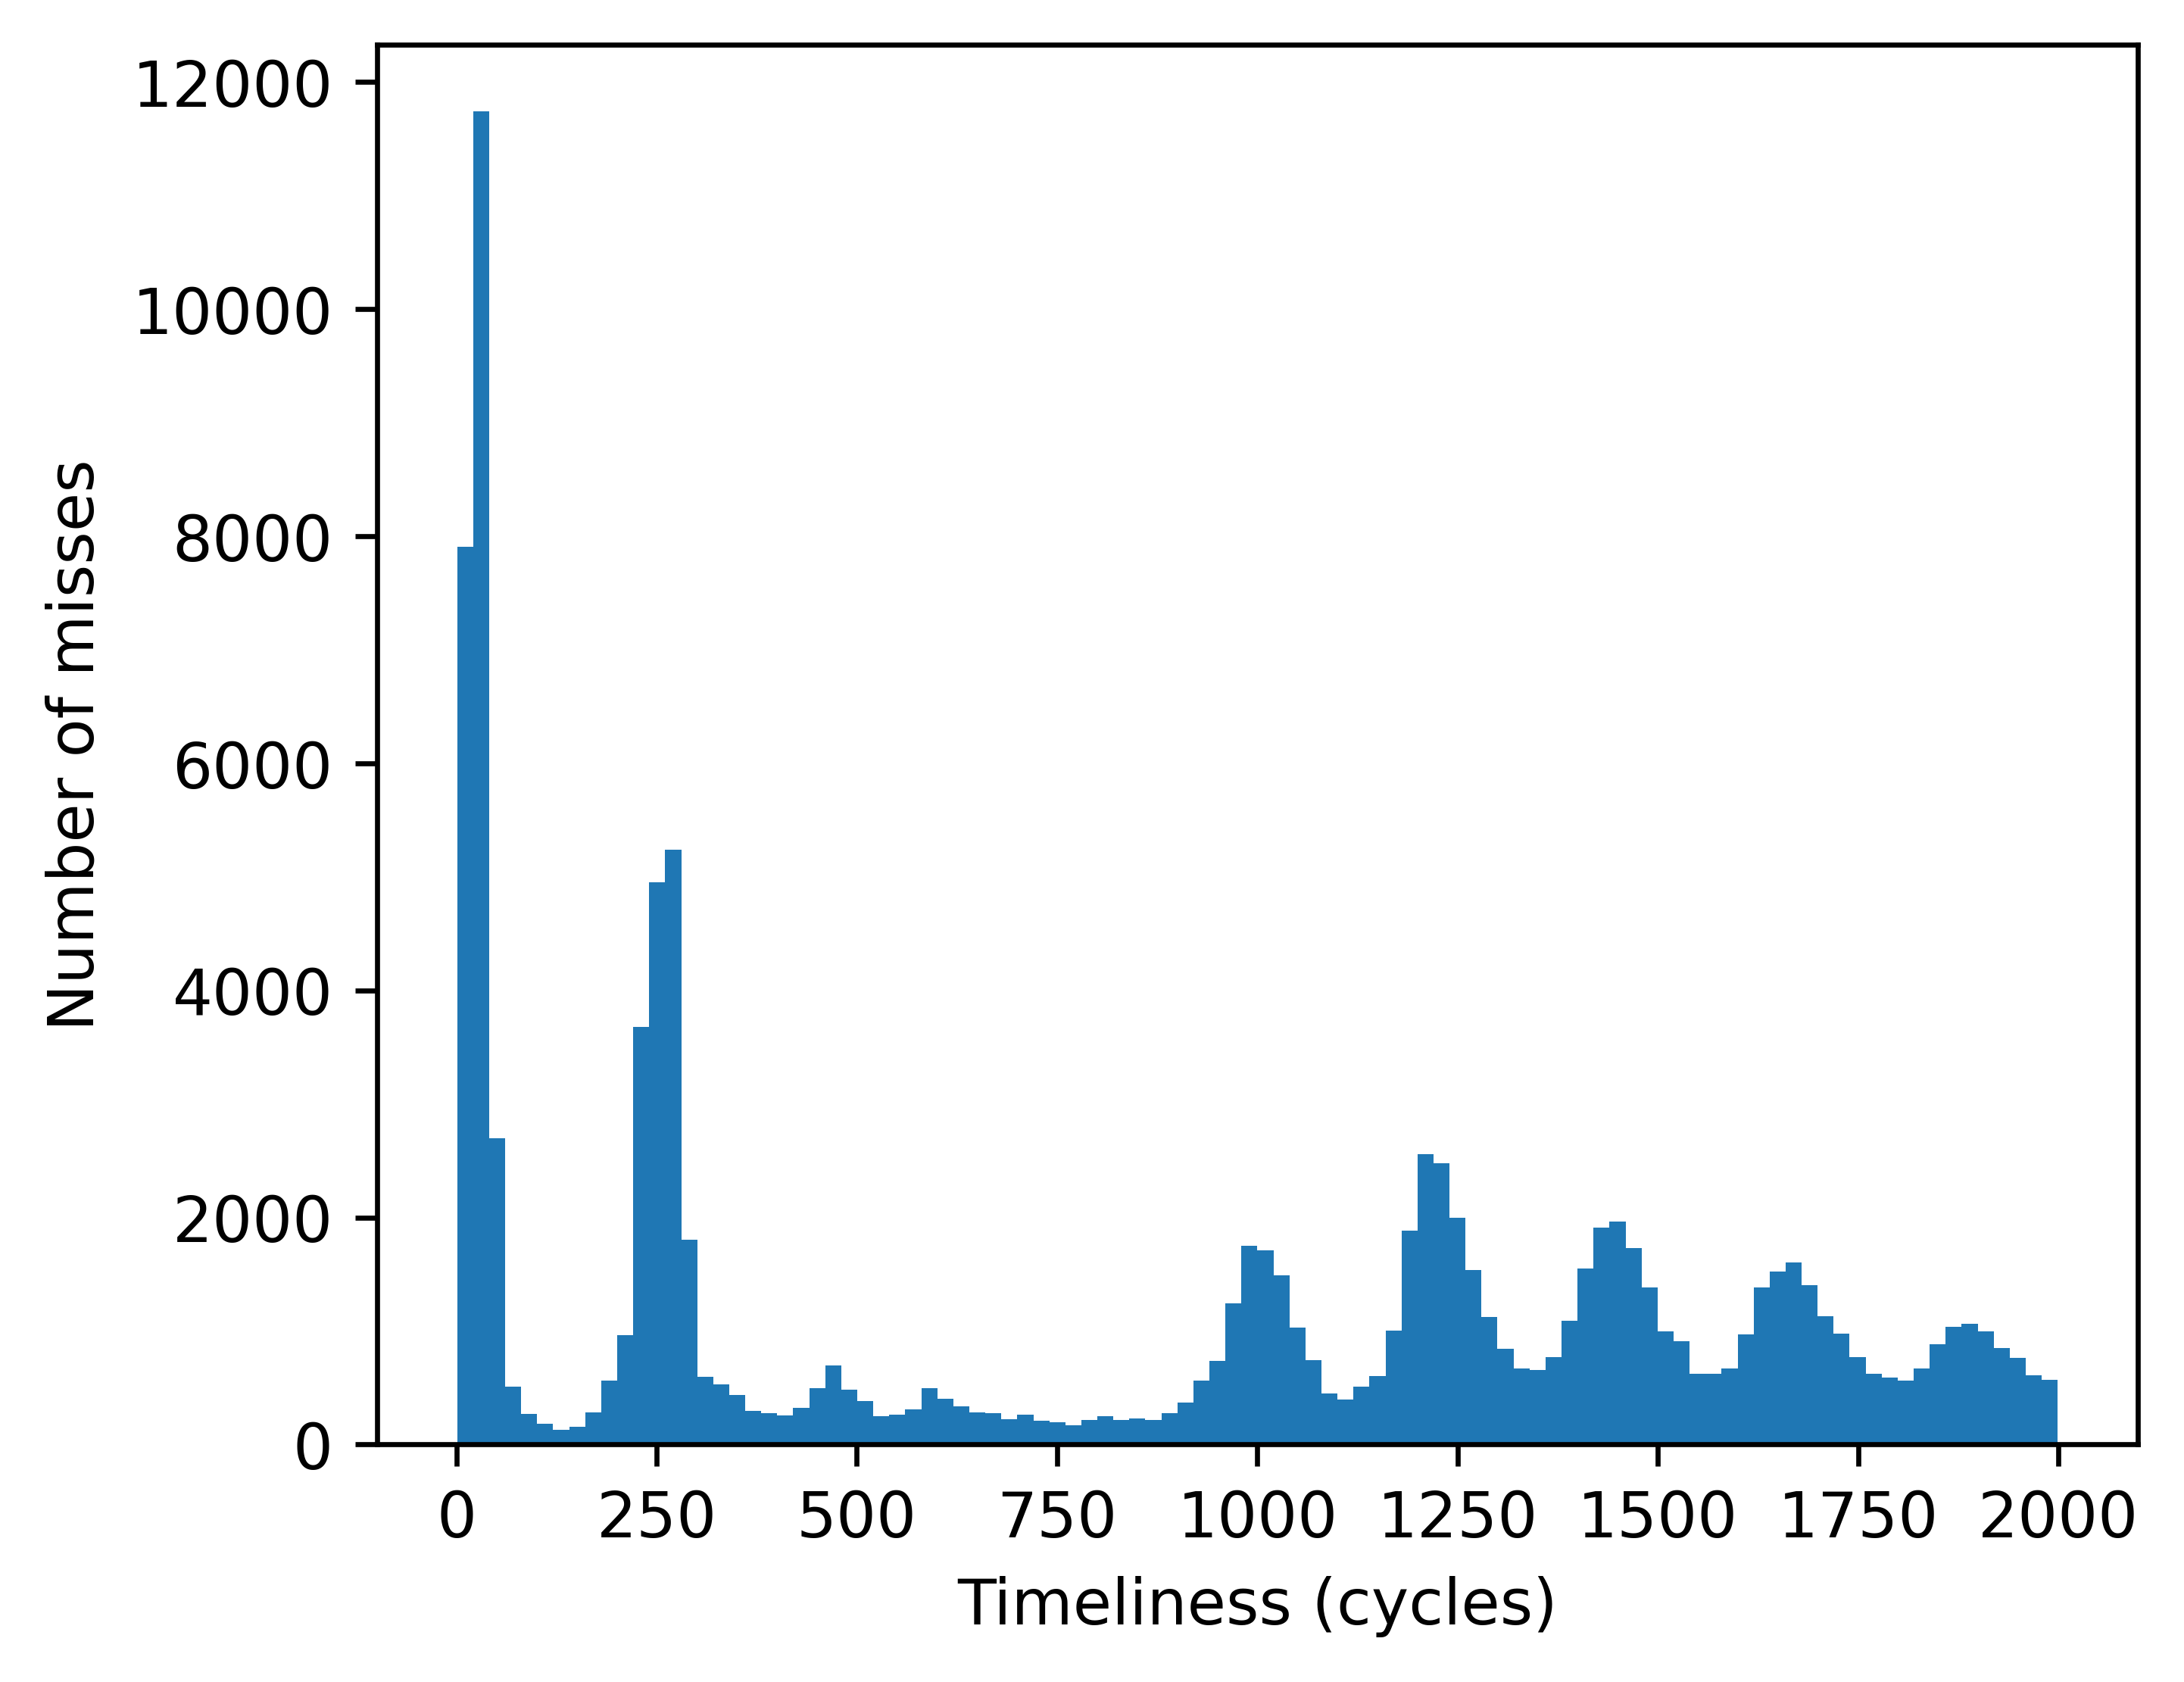

In [1284]:
plot_hist(df[df<2000], "Timeliness (cycles)", "Number of misses", "timelinessPatricia", figsize=(5,4))

<Axes: xlabel='Timeliness (in cycles)', ylabel='Frequency'>

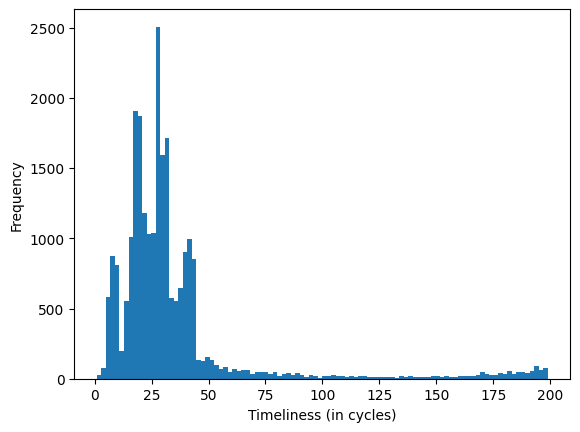

In [1291]:
df[df < 200].plot.hist(bins = 100, xlabel="Timeliness (in cycles)", legend=False)

<Axes: xlabel='Timeliness (in cycles)', ylabel='Frequency'>

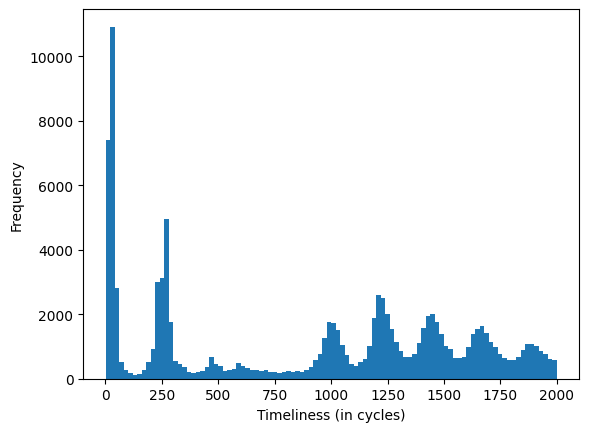

In [1238]:
df[df < 2000].plot.hist(bins = 100, xlabel="Timeliness (in cycles)", legend=False)

In [1292]:
df = pd.DataFrame.from_dict(timeliness_index_count_mibench_results["patricia"])
df

,0
0,-340
1,-313
2,-340
3,-364
4,-363
...,...
155958,-245913
155959,-245911
155960,-245671
155961,-245671


<Axes: xlabel='Timeliness (in cycles)', ylabel='Frequency'>

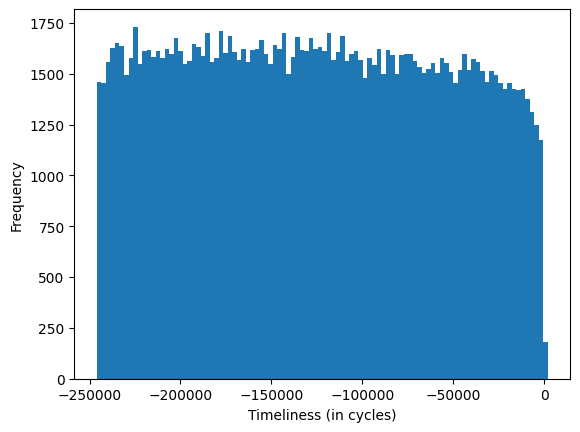

In [1293]:
df[df < 2000].plot.hist(bins = 100, xlabel="Timeliness (in cycles)", legend=False)